# 📋 РУКОВОДСТВО ПО ИСПОЛЬЗОВАНИЮ ШАБЛОНА (EDA)

## Просмотр результатов

**Ноутбук уже выполнен.** Все графики и выводы видны сразу при открытии на GitHub.

### Источник данных:

**Датасет:** Stroke Prediction Dataset  
**Источник:** [Kaggle - Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)

Навигация: [REDMI.md](https://github.com/vokoder1990/ml_practic/blob/main/stroke-prediction/REDMI.md)

Итоги анализа датасета: [ANALYSIS_REPORT.md](https://github.com/vokoder1990/ml_practic/blob/main/stroke-prediction/ANALYSIS_REPORT.md)

---

### **ВАЖНО: ПОСЛЕДОВАТЕЛЬНЫЙ ЗАПУСК**

Preprocessing (cycle_N/) → EDA (cycle_N/eda/) → Modeling (cycle_N/) → Cycle_comparison

**EDA НЕ запускается отдельно** - требуется предварительно выполненный Preprocessing ноутбук с сохранёнными сплитами и `metadata.json`.

---

## ОСНОВНЫЕ НАСТРОЙКИ (блок 1.2)

### Обязательные

| Переменная | Описание | Пример |
|------------|----------|--------|
| `PROJECT_NAME` | Имя проекта (должно совпадать с preprocessing) | `'stroke'` |
| `CYCLE_NUMBER` | Номер цикла (должен совпадать с preprocessing) | `4` |

### Визуализация

| Переменная | Описание | Значение по умолчанию |
|------------|----------|----------------------|
| `BINS` | Количество bins для гистограмм | `50` |
| `HUE_BY_TARGET` | Разделение графиков по целевой | `True` |

### Поиск скрытых пустот

| Переменная | Описание | Значение по умолчанию |
|------------|----------|----------------------|
| `EMPTY_MARKERS_STR` | Маркеры пустот в строках | `['', 'null', 'none', 'na', 'n/a', '?', 'unknown', 'nan']` |
| `EMPTY_MARKERS_NUM` | Маркеры пустот в числах | `[-1, -999, 999, 999999]` |

### Обработка пропусков

| Переменная | Описание | Пример |
|------------|----------|--------|
| `missing_strategy` | Стратегия для каждой колонки | `{'smoking_status': ('constant', 'unknown')}` |
| `GROUPED_IMPUTATION_CONFIG` | Групповое заполнение (напр., bmi по age) | см. блок 1.2 |

### Обработка выбросов

| Переменная | Описание | Значение по умолчанию |
|------------|----------|----------------------|
| `OUTLIER_IQR_COEFF` | Коэффициент для IQR | `1.5` |
| `outliers_strategy` | Стратегия для каждой колонки | `{'age': ('keep', None)}` |

### Кодирование категорий

| Переменная | Описание | Пример |
|------------|----------|--------|
| `encoding_config` | Метод кодирования для каждой колонки | `{'work_type': ('one_hot', None)}` |

### Масштабирование

| Переменная | Описание | Пример |
|------------|----------|--------|
| `scaling_config` | Метод масштабирования для числовых | `{'age': ('standard', None)}` |

### Удаление признаков (поэтапное)

| Переменная | Этап | Описание |
|------------|------|----------|
| `columns_to_drop_fe` | После FE | Удалить созданные признаки |
| `features_to_drop` | После корреляции | Удалить по корреляции |
| `columns_to_drop_final` | После Ablation/RF | Финальное удаление |

### Random Forest (анализ важности)

| Переменная | Описание | Значение по умолчанию |
|------------|----------|----------------------|
| `RF_CLASS_WEIGHT` | Балансировка классов | `'balanced'` |
| `RF_N_ESTIMATORS` | Количество деревьев | `100` |

### Ablation Study

| Переменная | Описание | Значение по умолчанию |
|------------|----------|----------------------|
| `ABLATION_CV_FOLDS` | Фолды кросс-валидации | `5` |
| `ABLATION_SCORING` | Метрика (`average_precision` / `roc_auc`) | `'average_precision'` |
| `ABLATION_ONEHOT_MODE` | `'separate'` или `'whole'` | `'whole'` |
| `ABLATION_ANALYZE_GROUPS` | Анализ кастомных групп | `False` |
| `ABLATION_FEATURE_GROUPS` | Кастомные группы признаков | `{}` |

---

## СТРАТЕГИИ ОБРАБОТКИ

### 1. Пропуски (`missing_strategy`)

| Стратегия | Описание | Пример |
|-----------|----------|--------|
| `drop_column` | Удалить колонку | `('drop_column', None)` |
| `mode` | Заполнить модой | `('mode', None)` |
| `median` | Заполнить медианой | `('median', None)` |
| `mean` | Заполнить средним | `('mean', None)` |
| `constant` | Заполнить константой | `('constant', 'unknown')` |
| `flag` | Создать флаг + заполнить | `('flag', 'median')` |

### 2. Выбросы (`outliers_strategy`)

| Стратегия | Описание | Пример |
|-----------|----------|--------|
| `keep` | Оставить как есть | `('keep', None)` |
| `cap` | Обрезать по границам | `('cap', (10, 60))` |
| `remove` | Удалить строки | `('remove', None)` |
| `log` | Логарифмировать (log или log1p) | `('log', None)` |
| `flag` | Создать флаг выброса | `('flag', None)` |

### 3. Кодирование (`encoding_config`)

| Метод | Описание | Когда использовать |
|-------|----------|---------------------|
| `binary_map` | Ручной маппинг через словарь | Бинарные признаки |
| `one_hot` | One-Hot Encoding (drop_first=True) | Низкая кардинальность (≤10) |
| `label` | Label Encoding | Бинарные признаки |
| `target` | Target Encoding | Средняя/высокая кардинальность |
| `frequency` | Frequency Encoding | Альтернатива Target |
| `none` | Без кодирования | Уже числовой признак |

### 4. Масштабирование (`scaling_config`)

| Метод | Описание | Когда использовать |
|-------|----------|---------------------|
| `standard` | StandardScaler | Нормальное распределение |
| `robust` | RobustScaler | Есть выбросы |
| `minmax` | MinMaxScaler | Нейронные сети |
| `none` | Без масштабирования | Tree-based модели |

---

##  FEATURE ENGINEERING (блок 1.3)

**Блок НЕ универсален - требует ручной настройки датасет.**

Функция `create_features(df)` добавляет новые признаки. После создания укажите их в `NEW_FEATURES` для анализа в блоке 5.2.

<pre>
📁 {PROJECT_NAME}/
└── 📁 cycle_{CYCLE_NUMBER}/
    ├── 📁 preprocessing/           # ← откуда читаем
    │   ├── 📁 splits/
    │   │   ├── 📄 X_train.csv
    │   │   ├── 📄 X_val.csv
    │   │   ├── 📄 X_test.csv
    │   │   ├── 📄 y_train.csv
    │   │   ├── 📄 y_val.csv
    │   │   └── 📄 y_test.csv
    │   └── 📄 metadata.json
    │
    └── 📁 eda/                     # ← куда сохраняем
        ├── 📁 data/
        │   ├── 📄 X_train_encoded.csv   # для деревьев
        │   ├── 📄 X_train_scaled.csv    # для линейных моделей
        │   ├── 📄 X_val_encoded.csv
        │   ├── 📄 X_val_scaled.csv
        │   ├── 📄 X_test_encoded.csv
        │   ├── 📄 X_test_scaled.csv
        │   ├── 📄 y_train.csv
        │   ├── 📄 y_val.csv
        │   └── 📄 y_test.csv
        ├── 📁 transformers/
        │   ├── 📄 encoders.pkl
        │   ├── 📄 scalers.pkl
        │   └── 📄 random_forest_importance.pkl
        ├── 📁 plots/
        │   └── ... (все графики)
        ├── 📁 reports/
        │   ├── 📄 eda_run_log_*.txt
        │   ├── 📄 ablation_study_tree.csv
        │   ├── 📄 ablation_study_linear.csv
        │   ├── 📄 feature_importance_rf.csv
        │   ├── 📄 eda_final_report.txt
        │   └── 📄 validation_report.json
        ├── 📄 production_metadata.json
        └── 📄 transformations_metadata.json
</pre>

---

**✅ После завершения EDA переходим в ноутбук Modeling**

# 📊 СТРУКТУРА EDA ПАЙПЛАЙНА (Версия 9.1)

---

## ЧАСТЬ 1: НАСТРОЙКА И ЗАГРУЗКА

| Блок | Название | Описание |
|------|----------|----------|
| 1.1 | Импорт библиотек | Все необходимые библиотеки |
| 1.2 | Настройки проекта | Параметры: стратегии, конфиги, пути |
| 1.3 | Feature Engineering | Функция `create_features()` |
| 1.4 | Монтирование Drive + пути | Защита от перезаписи |
| 1.5 | Загрузка метаданных | Из preprocessing (`metadata.json`) |
| 1.6 | Загрузка Train | + Feature Engineering |
| 1.7 | Анализ целевой | Распределение классов |
| 1.8 | Загрузка Val/Test | + FE |
| 1.9 | Сохранение лога | `eda_run_log_*.txt` |

---

## ЧАСТЬ 2: ПЕРВИЧНЫЙ ОСМОТР ДАННЫХ

| Блок | Название | Описание |
|------|----------|----------|
| 2.1 | Базовая информация | Типы, пропуски, память |
| 2.2 | Статистика числовых | Непрерывные + бинарные |
| 2.3 | Статистика категориальных | Уникальные, топ-значения |
| 2.4 | Визуализация числовых | Гистограммы + KDE |
| 2.5 | Визуализация целевой | Распределение |
| 2.6 | Анализ бинарных | Связь с целевой, Lift |

---

## ЧАСТЬ 3: ОБРАБОТКА ПРОПУСКОВ

| Блок | Название | Описание |
|------|----------|----------|
| 3.1 | Поиск пустот | Включая скрытые маркеры |
| 3.2 | Стратегия обработки | Анализ `missing_strategy` |
| 3.3 | Применение стратегий | Заполнение + флаги + FE |
| 3.4 | Проверка результата | NaN, консистентность |

---

## ЧАСТЬ 4: ОБРАБОТКА ВЫБРОСОВ

| Блок | Название | Описание |
|------|----------|----------|
| 4.1 | Визуализация | Boxplot'ы |
| 4.2 | Статистика IQR | Количество выбросов |
| 4.3 | Анализ Skewness | Асимметрия (ознакомление) |
| 4.4 | Стратегия обработки | Анализ `outliers_strategy` |
| 4.5 | Применение стратегий | Cap, remove, log, флаги |
| 4.6 | Проверка результата | Оставшиеся выбросы |

---

## ЧАСТЬ 5: УДАЛЕНИЕ ПОСЛЕ FE

| Блок | Название | Описание |
|------|----------|----------|
| 5.1 | Удаление признаков | `columns_to_drop_fe` |
| 5.2 | Сводный анализ | Новые признаки |

---

## ЧАСТЬ 6: АНАЛИЗ КАТЕГОРИАЛЬНЫХ

| Блок | Название | Описание |
|------|----------|----------|
| 6.1 | Анализ перед кодированием | Кардинальность, редкие категории |
| 6.2 | Визуализация | Barplot'ы |

---

## ЧАСТЬ 7: КОДИРОВАНИЕ И КОРРЕЛЯЦИЯ

| Блок | Название | Описание |
|------|----------|----------|
| 7.1 | Кодирование | One-hot, label, binary_map, target, frequency |
| 7.2 | Корреляция | Тепловая карта |
| 7.3 | Связь с целевой | F-value / Pearson |
| 7.4 | Удаление после корреляции | `features_to_drop` |

---

## ЧАСТЬ 8: ОБУЧЕНИЕ ТРАНСФОРМЕРОВ

| Блок | Название | Описание |
|------|----------|----------|
| 8.1 | Определение типов | Числовые vs категориальные |
| 8.2 | Масштабирование | StandardScaler / RobustScaler |
| 8.3 | Сохранение данных | CSV + метаданные |
| 8.4 | Применение к Val/Test | Кодирование + масштабирование |

---

## ЧАСТЬ 9: АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ

| Блок | Название | Описание |
|------|----------|----------|
| 9.1 | Ablation Study | One-hot группы, кастомные группы |
| 9.2 | Random Forest | Анализ важности |
| 9.3 | Финальное удаление | `columns_to_drop_final` (после Ablation/RF) |

---

## ЧАСТЬ 10: ОТЧЁТ И ВАЛИДАЦИЯ

| Блок | Название | Описание |
|------|----------|----------|
| 10.1 | Итоговый отчёт | Сводка трансформаций |
| 10.2 | Финальная валидация | Чекап + проверка утечки данных |

---

## 📁 СОХРАНЯЕМЫЕ ФАЙЛЫ

### Данные для Modelling (`eda/data/`)

| Файл | Блок | Описание |
|------|------|----------|
| `X_train_encoded.csv` | 8.3 | Для деревьев (RF, XGBoost) |
| `X_train_scaled.csv` | 8.3 | Для линейных моделей (LR, SVM) |
| `X_val_encoded.csv` | 8.4 | Признаки Val (закодированные) |
| `X_val_scaled.csv` | 8.4 | Признаки Val (масштабированные) |
| `X_test_encoded.csv` | 8.4 | Признаки Test (закодированные) |
| `X_test_scaled.csv` | 8.4 | Признаки Test (масштабированные) |
| `y_train.csv` | 8.3 | Целевая Train |
| `y_val.csv` | 8.4 | Целевая Val |
| `y_test.csv` | 8.4 | Целевая Test |

### Трансформеры (`eda/transformers/`)

| Файл | Блок | Описание |
|------|------|----------|
| `encoders.pkl` | 7.1 | Энкодеры (one-hot, label, target, frequency, binary_map) |
| `scalers.pkl` | 8.2 | Скейлеры числовых признаков |
| `random_forest_importance.pkl` | 9.2 | Обученный RF для важности |

### Метаданные (`eda/`)

| Файл | Блок | Описание |
|------|------|----------|
| `metadata.json` | 1.5 | Из Preprocessing (читается, не создаётся) |
| `transformations_metadata.json` | 8.3 | Конфигурации трансформаций (аудит) |
| `production_metadata.json` | 8.3 | Метаданные для Modelling |

### Отчёты (`eda/reports/`)

| Файл | Блок | Описание |
|------|------|----------|
| `eda_run_log_*.txt` | 1.9 | Лог запуска EDA |
| `ablation_study_tree.csv` | 9.1 | Ablation Study (Random Forest) |
| `ablation_study_linear.csv` | 9.1 | Ablation Study (Logistic Regression) |
| `feature_importance_rf.csv` | 9.2 | Таблица важности признаков (RF) |
| `eda_final_report.txt` | 10.1 | Итоговый отчёт EDA |
| `validation_report.json` | 10.2 | Отчёт финальной валидации |

### Графики (`eda/plots/`)

| Файл | Блок | Описание |
|------|------|----------|
| `distribution_*.png` | 2.4 | Распределения непрерывных признаков |
| `distribution_*_by_target.png` | 2.4 | Распределения по целевой |
| `target_distribution.png` | 2.5 | Распределение целевой переменной |
| `binary_*.png` | 2.6 | Анализ бинарных признаков |
| `boxplot_*.png` | 4.1 | Boxplot выбросов |
| `boxplot_*_by_target.png` | 4.1 | Boxplot по целевой |
| `all_boxplots.png` | 4.1 | Все boxplot вместе |
| `skewness_analysis.png` | 4.3 | Анализ асимметрии признаков |
| `categorical_*.png` | 6.2 | Распределение категориальных признаков |
| `correlation_heatmap.png` | 7.2 | Тепловая карта корреляции |
| `target_correlation.png` | 7.3 | Корреляция с целевой (регрессия) |
| `target_fvalue.png` | 7.3 | F-value (классификация) |
| `ablation_study.png` | 9.1 | Визуализация Ablation Study |
| `feature_importance_rf.png` | 9.2 | Важность признаков (Random Forest) |

---

## 🔄 ПОРЯДОК УДАЛЕНИЯ ПРИЗНАКОВ

| Этап | Блок | Переменная | Описание |
|------|------|------------|----------|
| 1 | 2.6 | `columns_to_drop_fe` | После создания признаков |
| 2 | 7.4 | `features_to_drop` | После корреляционного анализа |
| 3 | 9.3 | `columns_to_drop_final` | После Ablation Study и RF |


# БЛОК 1. import библиотек

In [ ]:
# 1.1 ИМПОРТ БИБЛИОТЕК

import os
import sys
import json
import warnings
import shutil
from datetime import datetime

import pandas as pd
import numpy as np
import sklearn
import joblib

# Визуализация
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Статистика
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.contingency_tables import Table2x2

# ML и предобработка
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.feature_selection import f_classif, chi2

# TargetEncoder (доступен в sklearn >= 1.3)
try:
    from sklearn.preprocessing import TargetEncoder
    TARGET_ENCODER_AVAILABLE = True
except ImportError:
    TARGET_ENCODER_AVAILABLE = False
    print("⚠️ TargetEncoder не доступен (sklearn < 1.3). Будет использован ручной Target Encoding.")

# Отображение
from IPython.display import display

# Настройки
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

# Определение окружения
try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ Среда выполнения: Google Colab")
except ImportError:
    IN_COLAB = False
    print("✓ Среда выполнения: локальная / Kaggle")

# Вывод версий
def print_versions():
    """Выводит версии ключевых библиотек"""
    print("\n📦 Версии пакетов:")
    print(f"   Python: {sys.version.split()[0]}")
    print(f"   pandas: {pd.__version__}")
    print(f"   numpy: {np.__version__}")
    print(f"   matplotlib: {matplotlib.__version__}")
    print(f"   seaborn: {sns.__version__}")
    print(f"   scikit-learn: {sklearn.__version__}")

    try:
        import scipy
        print(f"   scipy: {scipy.__version__}")
    except ImportError:
        pass

    try:
        import statsmodels
        print(f"   statsmodels: {statsmodels.__version__}")
    except ImportError:
        pass

    print(f"   TargetEncoder доступен: {'✅' if TARGET_ENCODER_AVAILABLE else '❌ (ручной режим)'}")

print_versions()

✓ Среда выполнения: Google Colab

📦 Версии пакетов:
   Python: 3.12.13
   pandas: 2.2.2
   numpy: 2.0.2
   matplotlib: 3.10.0
   seaborn: 0.13.2
   scikit-learn: 1.6.1
   scipy: 1.16.3
   statsmodels: 0.14.6
   TargetEncoder доступен: ✅


# Настройки проекта

In [ ]:
# =============================================================================
# 1.2 НАСТРОЙКИ ПРОЕКТА (менять под задачу)
# =============================================================================

# --------------------------------------------
# 1. ПРОЕКТ (заполни вручную)
# --------------------------------------------
PROJECT_NAME = 'stroke'      # имя папки в datasets/
CYCLE_NUMBER = 5               # номер цикла

# --------------------------------------------
# 2. ПАРАМЕТРЫ ВИЗУАЛИЗАЦИИ
# --------------------------------------------
AUTO_BINS = 54                    # справочно: √N (рассчитано по формуле)
BINS = 50                         # выбранное количество бинов
HUE_BY_TARGET = True              # разделять визуализации по целевой переменной

# --------------------------------------------
# 3. МАРКЕРЫ ПУСТОТЫ (скрытые пропуски)
# --------------------------------------------
EMPTY_MARKERS_STR = ['', 'null', 'none', 'na', 'n/a', '?', 'unknown', 'nan']
EMPTY_MARKERS_NUM = [-1, -999, 999, 999999]

# --------------------------------------------
# 4. СТРАТЕГИЯ ОБРАБОТКИ ПРОПУСКОВ
# --------------------------------------------
missing_strategy = {
    'smoking_status': ('constant', 'unknown'),
}

# --------------------------------------------
# НАСТРОЙКИ ГРУППОВОГО ЗАПОЛНЕНИЯ ПРОПУСКОВ
# --------------------------------------------
# Формат: 'колонка_для_заполнения': {
#     'groupby_col': 'колонка_для_группировки',
#     'bins': [границы_групп],
#     'labels': [названия_групп],
#     'strategy': 'median',  # 'median', 'mean', 'mode'
#     'create_flag': True     # создавать ли флаг пропуска
# }

GROUPED_IMPUTATION_CONFIG = {
    'bmi': {
        'groupby_col': 'age',
        'bins': [0, 30, 45, 60, 100],
        'labels': ['0-30', '31-45', '46-60', '60+'],
        'strategy': 'median',
        'create_flag': True
    },
}


# --------------------------------------------
# 5. КОЭФФИЦИЕНТ IQR ДЛЯ ВЫБРОСОВ
# --------------------------------------------
OUTLIER_IQR_COEFF = 1.5

# --------------------------------------------
# 6. СТРАТЕГИЯ ОБРАБОТКИ ВЫБРОСОВ
# --------------------------------------------
outliers_strategy = {
    'age': ('keep', None),
    'avg_glucose_level': ('keep', None),
    'bmi': ('keep', None),

}

# --------------------------------------------
# 7. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
# --------------------------------------------
encoding_config = {
    'work_type': ('one_hot', None),
}

# --------------------------------------------
# 8. УДАЛЕНИЕ ПРИЗНАКОВ
# --------------------------------------------
columns_to_drop_fe = [
    'glucose_high_risk',
    'is_smoker',
    'ever_married',
    'gender',
    'residence_type',
    'hypertension',
    'bmi',
    'smoking_status',
    'heart_disease',


]

features_to_drop = [



]


# --------------------------------------------
# 9. МАСШТАБИРОВАНИЕ ЧИСЛОВЫХ ПРИЗНАКОВ
# --------------------------------------------
scaling_config = {
    'age': ('standard', None),
    'avg_glucose_level': ('robust', None),
    'smoking_age_impact': ('robust', None),
    # 'bmi': ('standard', None),

}

# --------------------------------------------
# 10. ФИНАЛЬНОЕ УДАЛЕНИЕ
# --------------------------------------------
columns_to_drop_final = []

# --------------------------------------------
# 11. НАСТРОЙКИ RANDOM FOREST
# --------------------------------------------
RF_CLASS_WEIGHT = 'balanced'
RF_N_ESTIMATORS = 100

# --------------------------------------------
# 12. НАСТРОЙКИ ДЛЯ ABLATION STUDY (расширенные)
# --------------------------------------------
ABLATION_MODEL_TYPE = 'logistic'  # 'logistic' или 'random_forest'
ABLATION_CV_FOLDS = 5
ABLATION_SCORING = 'average_precision'
ABLATION_RANDOM_STATE = 99

# Настройки для Logistic Regression
ABLATION_LOGISTIC_MAX_ITER = 5000
ABLATION_LOGISTIC_C = 1.0

# Настройки для Random Forest
ABLATION_RF_N_ESTIMATORS = 100
ABLATION_RF_MAX_DEPTH = None
ABLATION_RF_MIN_SAMPLES_SPLIT = 2

# ============================================
# НОВЫЕ НАСТРОЙКИ УДАЛЕНИЯ
# ============================================

# 1. Режим удаления one-hot колонок
#    - 'separate': удалять каждую one-hot колонку отдельно
#    - 'whole': удалять весь one-hot признак целиком (все колонки группы)
ABLATION_ONEHOT_MODE = 'whole'  # 'separate' или 'whole'

# 2. Анализ кастомных групп
#    - True: удалять группы из ABLATION_FEATURE_GROUPS
#    - False: не удалять группы
ABLATION_ANALYZE_GROUPS = True

# 4. Кастомные группы (работают только если ABLATION_ANALYZE_GROUPS = True)
ABLATION_FEATURE_GROUPS = {

}

# --------------------------------------------
# 13. ПРОЧЕЕ
# --------------------------------------------
SAVE_INTERMEDIATE = True
TARGET_COLUMN = None           # заполнится из metadata.json

if IN_COLAB:
    BASE_PATH = '/content/drive/MyDrive/ml_learning'
else:
    BASE_PATH = os.path.join(os.getcwd(), 'ml_learning')

# --------------------------------------------
# ВЫВОД НАСТРОЕК (предварительный)
# --------------------------------------------
print("\n" + "="*50)
print(f"📁 ПРОЕКТ: {PROJECT_NAME if PROJECT_NAME else 'будет загружен из метаданных'}")
print(f"🎯 HUE_BY_TARGET: {HUE_BY_TARGET}")
print(f"📊 BINS: {BINS} (справочно AUTO_BINS: {AUTO_BINS})")
print("="*50 + "\n")


📁 ПРОЕКТ: stroke
🎯 HUE_BY_TARGET: True
📊 BINS: 50 (справочно AUTO_BINS: 54)



# Feature Engineering

In [ ]:
# =============================================================================
# 1.3 FEATURE ENGINEERING: ФУНКЦИЯ СОЗДАНИЯ ПРИЗНАКОВ
# =============================================================================

def create_features(df):
    """
    Создаёт новые признаки для датасета Stroke Prediction.
    Замените код внутри на свой для другого датасета.
    """

    df['cardio_risk'] = ((df['hypertension'] == 1) | (df['heart_disease'] == 1)).astype(int)
    df['stable_old_age'] = ((df['age'] > 60) & (df['ever_married'] == 'yes')).astype(int)
    df['glucose_high_risk'] = (df['avg_glucose_level'] >= 145).astype(int)

    df['is_smoker'] = (df['smoking_status'].isin(['smokes', 'formerly_smoked'])).astype(int)

    # Интерактивный признак: возраст × курит
    df['smoking_age_impact'] = df['age'] * df['is_smoker']

    return df


NEW_FEATURES = [
    'cardio_risk',
    'stable_old_age',
    'glucose_high_risk',
    'smoking_age_impact',
    'is_smoker',

]

def grouped_imputation(df, config, group_values_dict=None, mode='fit'):
    """
    Универсальное групповое заполнение пропусков для нескольких колонок.

    Параметры:
    ----------
    df : DataFrame
        Исходные данные
    config : dict
        Словарь вида {'колонка': {'groupby_col': ..., 'bins': ..., ...}}
    group_values_dict : dict, optional
        Для mode='transform' - словарь с вычисленными значениями для каждой колонки
    mode : str
        'fit' - вычислить значения по группам и заполнить
        'transform' - заполнить, используя переданные group_values_dict

    Возвращает:
    ----------
    df : DataFrame
        Данные с заполненными пропусками
    group_values_dict : dict
        Для mode='fit' - словарь с вычисленными значениями
        Для mode='transform' - None
    """
    # Для обратной совместимости: если передан config с одной колонкой и без group_values_dict
    if group_values_dict is None:
        group_values_dict = {}

    for target_col, cfg in config.items():
        # Проверки
        if target_col not in df.columns:
            print(f"   ⚠️ Колонка '{target_col}' не найдена, пропускаем")
            continue

        groupby_col = cfg.get('groupby_col')
        if groupby_col not in df.columns:
            print(f"   ⚠️ Колонка для группировки '{groupby_col}' не найдена, пропускаем")
            continue

        bins = cfg.get('bins')
        labels = cfg.get('labels')
        strategy = cfg.get('strategy', 'median')
        create_flag = cfg.get('create_flag', False)

        # Создаём временную колонку с группами
        group_col_name = f'_{target_col}_group'

        if bins and labels:
            df[group_col_name] = pd.cut(df[groupby_col], bins=bins, labels=labels, right=False)
        else:
            df[group_col_name] = df[groupby_col]

        if mode == 'fit':
            # ============================================
            # 1. СОЗДАЁМ ФЛАГ ПРОПУСКА (ДО заполнения)
            # ============================================
            if create_flag:
                flag_col = f'{target_col}_missing_flag'
                df[flag_col] = df[target_col].isna().astype(int)

            # ============================================
            # 2. ВЫЧИСЛЯЕМ ЗНАЧЕНИЯ ПО ГРУППАМ
            # ============================================
            if strategy == 'median':
                group_vals = df.groupby(group_col_name)[target_col].median().to_dict()
            elif strategy == 'mean':
                group_vals = df.groupby(group_col_name)[target_col].mean().to_dict()
            elif strategy == 'mode':
                group_vals = df.groupby(group_col_name)[target_col].agg(
                    lambda x: x.mode()[0] if not x.mode().empty else None
                ).to_dict()
            else:
                raise ValueError(f"Неизвестная стратегия: {strategy}")

            # ============================================
            # 2b. FALLBACK ДЛЯ ПУСТЫХ ГРУПП
            # ============================================
            global_value = df[target_col].median() if strategy == 'median' else df[target_col].mean()
            for group, value in group_vals.items():
                if pd.isna(value):
                    print(f"   ⚠️ {target_col}: группа {group} пуста, использую глобальную {strategy}")
                    group_vals[group] = global_value

            # ============================================
            # 3. ЗАПОЛНЯЕМ ПРОПУСКИ
            # ============================================
            for group, value in group_vals.items():
                if pd.notna(value):
                    mask = (df[group_col_name] == group) & (df[target_col].isna())
                    df.loc[mask, target_col] = value

            # Сохраняем значения для transform
            group_values_dict[target_col] = group_vals

        else:  # mode == 'transform'
            if target_col not in group_values_dict:
                print(f"   ⚠️ {target_col}: нет сохранённых значений для transform, пропускаем")
                df.drop(columns=[group_col_name], inplace=True)
                continue

            group_vals = group_values_dict[target_col]

            # ============================================
            # 1. СОЗДАЁМ ФЛАГ ПРОПУСКА (ДО заполнения)
            # ============================================
            if create_flag:
                flag_col = f'{target_col}_missing_flag'
                df[flag_col] = df[target_col].isna().astype(int)

            # ============================================
            # 2. ЗАПОЛНЯЕМ ПРОПУСКИ
            # ============================================
            for group, value in group_vals.items():
                if pd.notna(value):
                    mask = (df[group_col_name] == group) & (df[target_col].isna())
                    df.loc[mask, target_col] = value

        # Удаляем временную колонку
        df.drop(columns=[group_col_name], inplace=True)

    return df, group_values_dict if mode == 'fit' else None

In [ ]:
# =============================================================================
# 1.4 МОНТИРОВАНИЕ GOOGLE DRIVE И НАСТРОЙКА ПУТЕЙ
# =============================================================================

print("\n" + "="*50)
print("📂 МОНТИРОВАНИЕ GOOGLE DRIVE")
print("="*50)

if IN_COLAB:
    if BASE_PATH.startswith('/content/drive'):
        from google.colab import drive

        if os.path.exists('/content/drive/MyDrive'):
            print("✓ Google Drive уже смонтирован")
        else:
            print("📂 Монтирование Google Drive...")
            drive.mount('/content/drive')
            print("✓ Google Drive смонтирован")
    else:
        print("✓ BASE_PATH не на Google Drive, монтирование не требуется")
else:
    print("✓ Локальная среда, монтирование не требуется")

print("="*50 + "\n")

# =============================================================================
# 1.4b НАСТРОЙКА ПУТЕЙ (С ЗАЩИТОЙ ОТ ПЕРЕЗАПИСИ С УДАЛЕНИЕМ)
# =============================================================================

print("\n" + "="*50)
print("📂 НАСТРОЙКА ПУТЕЙ ПРОЕКТА")
print("="*50)

import shutil

if 'BASE_PATH' not in globals():
    raise NameError("❌ BASE_PATH не определён. Выполните блок 1.2")

if PROJECT_NAME is None or CYCLE_NUMBER is None:
    raise ValueError("❌ Укажите PROJECT_NAME и CYCLE_NUMBER в блоке 1.2")

# Проверка, что CYCLE_NUMBER целое положительное число
if not isinstance(CYCLE_NUMBER, int) or CYCLE_NUMBER <= 0:
    raise ValueError(f"❌ CYCLE_NUMBER должен быть положительным целым числом, получено: {CYCLE_NUMBER}")

# --------------------------------------------
# ФОРМИРУЕМ ПУТИ
# --------------------------------------------
PROJECT_PATH = os.path.join(BASE_PATH, 'datasets', PROJECT_NAME)
CYCLE_PATH = os.path.join(PROJECT_PATH, f'cycle_{CYCLE_NUMBER}')
PREPROCESSING_PATH = os.path.join(CYCLE_PATH, 'preprocessing')
METADATA_PATH = os.path.join(PREPROCESSING_PATH, 'metadata.json')

# Проверяем существование preprocessing
if not os.path.exists(PREPROCESSING_PATH):
    raise FileNotFoundError(f"❌ Папка preprocessing не найдена: {PREPROCESSING_PATH}")

if not os.path.exists(METADATA_PATH):
    raise FileNotFoundError(f"❌ metadata.json не найден: {METADATA_PATH}")

# --------------------------------------------
# ПУТИ ДЛЯ СОХРАНЕНИЯ (в eda)
# --------------------------------------------
EDA_PATH = os.path.join(CYCLE_PATH, 'eda')
EDA_DATA_PATH = os.path.join(EDA_PATH, 'data')
EDA_TRANSFORMERS_PATH = os.path.join(EDA_PATH, 'transformers')
EDA_PLOTS_PATH = os.path.join(EDA_PATH, 'plots')
EDA_REPORTS_PATH = os.path.join(EDA_PATH, 'reports')

# ============================================
# ЗАЩИТА ОТ ПЕРЕЗАПИСИ (С ПОЛНЫМ УДАЛЕНИЕМ)
# ============================================
if os.path.exists(EDA_PATH):
    print(f"\n⚠️ ВНИМАНИЕ: Папка EDA для цикла {CYCLE_NUMBER} уже существует!")
    print(f"   {EDA_PATH}")

    # Проверяем, есть ли файлы в eda
    if os.path.exists(EDA_PATH):
        existing_files = os.listdir(EDA_PATH)
        if existing_files:
            print(f"   Обнаружены существующие файлы: {existing_files[:5]}...")
            if 'production_metadata.json' in existing_files:
                print("   ⚠️ ВНИМАНИЕ: Обнаружены метаданные! Перезапись удалит их.")

    print(f"\n   Что делать:")
    print(f"   • Если хотите СОЗДАТЬ НОВЫЙ ЦИКЛ - измените CYCLE_NUMBER на {CYCLE_NUMBER + 1} в блоке 1.2")
    print(f"   • Если хотите ПЕРЕЗАПИСАТЬ текущий EDA - введите 'y'")

    response = input(f"\n   Продолжить с перезаписью? (y/N): ")
    if response.lower() != 'y':
        print("❌ Операция отменена. Измените CYCLE_NUMBER и запустите заново.")
        raise SystemExit(0)
    else:
        print(f"   ⚠️ Продолжаем с перезаписью EDA для cycle_{CYCLE_NUMBER}")
        # ПОЛНОЕ УДАЛЕНИЕ СТАРОЙ ПАПКИ EDA
        shutil.rmtree(EDA_PATH)
        print(f"   🗑️ Старая папка EDA удалена")

# Создание всех необходимых папок
for path in [EDA_PATH, EDA_DATA_PATH, EDA_TRANSFORMERS_PATH,
             EDA_PLOTS_PATH, EDA_REPORTS_PATH]:
    os.makedirs(path, exist_ok=True)

print(f"\n📂 СТРУКТУРА ПРОЕКТА:")
print(f"   {PROJECT_PATH}/")
print(f"   └── cycle_{CYCLE_NUMBER}/")
print(f"       ├── preprocessing/           # ← откуда читаем")
print(f"       │   ├── splits/")
print(f"       │   └── checkpoints/")
print(f"       └── eda/                     # ← куда сохраняем")
print(f"           ├── data/")
print(f"           ├── transformers/")
print(f"           ├── plots/")
print(f"           └── reports/")

print(f"\n✅ Пути настроены, защита от перезаписи активна")
print("="*50 + "\n")


📂 МОНТИРОВАНИЕ GOOGLE DRIVE
✓ Google Drive уже смонтирован


📂 НАСТРОЙКА ПУТЕЙ ПРОЕКТА

📂 СТРУКТУРА ПРОЕКТА:
   /content/drive/MyDrive/ml_learning/datasets/stroke/
   └── cycle_5/
       ├── preprocessing/           # ← откуда читаем
       │   ├── splits/
       │   └── checkpoints/
       └── eda/                     # ← куда сохраняем
           ├── data/
           ├── transformers/
           ├── plots/
           └── reports/

✅ Пути настроены, защита от перезаписи активна



In [ ]:
# =============================================================================
# 1.5 ЗАГРУЗКА МЕТАДАННЫХ ИЗ PREPROCESSING
# =============================================================================

print("\n" + "="*50)
print("📋 ЗАГРУЗКА МЕТАДАННЫХ")
print("="*50)

with open(METADATA_PATH, 'r', encoding='utf-8') as f:
    metadata = json.load(f)

# ============================================
# ВСЕ ПРОВЕРКИ ПОСЛЕ ЗАГРУЗКИ METADATA
# ============================================

# 1. Проверка data contract
data_contract = metadata.get('data_contract', {})
if data_contract:
    print(f"\n📋 DATA CONTRACT загружен (версия {data_contract.get('version', 'N/A')})")
    GUARANTEED_COLUMNS = data_contract.get('guaranteed_columns', [])
    CATEGORICAL_HINT = data_contract.get('categorical_columns_hint', [])
    NUMERICAL_HINT = data_contract.get('numerical_columns_hint', [])
    print(f"   Ожидаемые колонки: {len(GUARANTEED_COLUMNS)}")
    print(f"   Категориальные (подсказка): {len(CATEGORICAL_HINT)}")
    print(f"   Числовые (подсказка): {len(NUMERICAL_HINT)}")
else:
    print(f"\n⚠️ ВНИМАНИЕ: data_contract отсутствует в metadata (старая версия preprocessing)")
    GUARANTEED_COLUMNS = []
    CATEGORICAL_HINT = []
    NUMERICAL_HINT = []

# 2. Проверка совпадения CYCLE_NUMBER
if metadata.get('cycle_number') != CYCLE_NUMBER:
    print(f"\n⚠️ ВНИМАНИЕ: Несоответствие номера цикла!")
    print(f"   CYCLE_NUMBER в настройках: {CYCLE_NUMBER}")
    print(f"   cycle_number в metadata: {metadata.get('cycle_number')}")
    print(f"   Возможна ошибка загрузки данных!")

# 3. Проверка наличия random_state
if 'random_state' not in metadata:
    raise KeyError(
        f"❌ В metadata.json отсутствует поле 'random_state'.\n"
        f"   Обновите preprocessing ноутбук: добавьте 'random_state' в metadata."
    )
RANDOM_STATE = metadata['random_state']

# ============================================
# ИЗВЛЕЧЕНИЕ КЛЮЧЕВОЙ ИНФОРМАЦИИ
# ============================================
TARGET_COLUMN = metadata.get('target_column')
TASK_TYPE = metadata.get('task_type', 'classification')
FEATURE_NAMES = metadata.get('feature_names', [])
CLASS_COUNT = metadata.get('class_count', None)
CLASSES = metadata.get('classes', [])
TRAIN_SIZE = metadata.get('train_size', 0)
VAL_SIZE = metadata.get('val_size', 0)
TEST_SIZE = metadata.get('test_size', 0)
PACKAGE_VERSIONS = metadata.get('package_versions', {})

# Проверка, что FEATURE_NAMES не пуст
if not FEATURE_NAMES:
    print(f"\n⚠️ ВНИМАНИЕ: FEATURE_NAMES пуст! Проверьте metadata.json")

# Проверка соответствия PROJECT_NAME (опционально, для безопасности)
project_name_from_meta = metadata.get('project_name')
if project_name_from_meta and project_name_from_meta != PROJECT_NAME:
    print(f"\n⚠️ ВНИМАНИЕ: PROJECT_NAME из папки ({PROJECT_NAME})")
    print(f"   не совпадает с метаданными ({project_name_from_meta})")
    print(f"   Использую значение из папки: {PROJECT_NAME}")

# ============================================
# ВЫВОД ИНФОРМАЦИИ
# ============================================
print("\n✓ Метаданные загружены:")
print(f"   Проект: {PROJECT_NAME}")
print(f"   Цикл: {CYCLE_NUMBER}")
print(f"   Целевая колонка: {TARGET_COLUMN}")
print(f"   Тип задачи: {TASK_TYPE}")
print(f"   🎲 Random state: {RANDOM_STATE}")
print(f"   Признаков: {len(FEATURE_NAMES)}")
print(f"   Размеры: train={TRAIN_SIZE}, val={VAL_SIZE}, test={TEST_SIZE}")
print(f"   Дата обработки: {metadata.get('date_processed', 'N/A')}")

if PACKAGE_VERSIONS:
    print(f"\n📦 Версии из preprocessing:")
    for pkg, ver in list(PACKAGE_VERSIONS.items())[:3]:
        print(f"   {pkg}: {ver}")

print("\n" + "="*50)
print("✓ Загрузка метаданных завершена")
print("="*50 + "\n")


📋 ЗАГРУЗКА МЕТАДАННЫХ

📋 DATA CONTRACT загружен (версия 1.0)
   Ожидаемые колонки: 10
   Категориальные (подсказка): 5
   Числовые (подсказка): 5

✓ Метаданные загружены:
   Проект: stroke
   Цикл: 5
   Целевая колонка: stroke
   Тип задачи: classification
   🎲 Random state: 99
   Признаков: 10
   Размеры: train=3031, val=1011, test=1011
   Дата обработки: 2026-05-02 20:29:35

📦 Версии из preprocessing:
   python: 3.12.13
   pandas: 2.2.2
   numpy: 2.0.2

✓ Загрузка метаданных завершена



In [ ]:
# =============================================================================
# 1.6 ЗАГРУЗКА TRAIN ИЗ PREPROCESSING/SPLITS
# =============================================================================

print("\n" + "=" * 50)
print("📂 ЗАГРУЗКА ДАННЫХ ИЗ PREPROCESSING/SPLITS")
print("=" * 50)

# Проверяем, что PREPROCESSING_PATH определён
if 'PREPROCESSING_PATH' not in globals():
    raise NameError("❌ PREPROCESSING_PATH не определён. Выполните блок 1.4")

# Формируем путь к папке splits
SPLITS_PATH = os.path.join(PREPROCESSING_PATH, 'splits')
print(f"📂 Читаем из: {SPLITS_PATH}")

# Проверяем, что папка splits существует
if not os.path.exists(SPLITS_PATH):
    raise FileNotFoundError(
        f"❌ Папка splits не найдена: {SPLITS_PATH}\n"
        f"   Убедитесь, что первичная предобработка создала сплиты."
    )

# Загрузка Train
train_path = os.path.join(SPLITS_PATH, 'X_train.csv')
y_train_path = os.path.join(SPLITS_PATH, 'y_train.csv')

if not os.path.exists(train_path):
    raise FileNotFoundError(f"❌ Файл не найден: {train_path}")

X_train = pd.read_csv(train_path)
y_train = pd.read_csv(y_train_path).iloc[:, 0]

print(f"📥 Train загружен: {X_train.shape}")

# ============================================
# ПРОВЕРКА РАЗМЕРОВ X_train И y_train
# ============================================
if len(X_train) != len(y_train):
    raise ValueError(f"❌ Размеры X_train и y_train не совпадают! "
                     f"X_train={len(X_train)}, y_train={len(y_train)}")
print(f"✓ Размеры X_train и y_train совпадают ({len(X_train)})")

# ============================================
# СОХРАНЕНИЕ ИСХОДНОЙ ФОРМЫ (для отчёта)
# ============================================
original_shape = X_train.shape
print(f"📐 Исходная форма X_train: {original_shape[0]} × {original_shape[1]}")

# ============================================
# ПРОВЕРКА КОЛОНОК НА СООТВЕТСТВИЕ FEATURE_NAMES
# ============================================
if 'FEATURE_NAMES' in globals() and FEATURE_NAMES:
    train_cols = list(X_train.columns)
    if set(train_cols) != set(FEATURE_NAMES):
        print(f"\n⚠️ ВНИМАНИЕ: Колонки X_train не совпадают с FEATURE_NAMES из metadata!")
        print(f"   Различия:")
        print(f"      Лишние в X_train: {set(train_cols) - set(FEATURE_NAMES)}")
        print(f"      Отсутствуют в X_train: {set(FEATURE_NAMES) - set(train_cols)}")
    else:
        print(f"✓ Колонки соответствуют FEATURE_NAMES")
else:
    print(f"\n⚠️ FEATURE_NAMES не загружены (пропущена проверка)")

# ============================================
# ПРОВЕРКА НОВЫХ ПРИЗНАКОВ
# ============================================
if 'NEW_FEATURES' in globals() and NEW_FEATURES:
    missing = [f for f in NEW_FEATURES if f not in X_train.columns]
    if missing:
        print(f"⚠️ Не найдены в X_train: {missing}")
    else:
        print(f"✓ Все {len(NEW_FEATURES)} новых признаков присутствуют")
else:
    print(f"ℹ️ NEW_FEATURES не заданы (пропущена проверка)")

print("=" * 50 + "\n")


📂 ЗАГРУЗКА ДАННЫХ ИЗ PREPROCESSING/SPLITS
📂 Читаем из: /content/drive/MyDrive/ml_learning/datasets/stroke/cycle_5/preprocessing/splits
📥 Train загружен: (3031, 10)
✓ Размеры X_train и y_train совпадают (3031)
📐 Исходная форма X_train: 3031 × 10
✓ Колонки соответствуют FEATURE_NAMES
⚠️ Не найдены в X_train: ['cardio_risk', 'stable_old_age', 'glucose_high_risk', 'smoking_age_impact', 'is_smoker']



In [ ]:
# 1.7 ПРОВЕРКА ТИПА ЗАДАЧИ И ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

print("\n" + "="*50)
print("🎯 АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
print("="*50)

if y_train is None:
    print("\n⚠️ y_train не загружен. Пропускаем анализ.")
else:
    # Используем TASK_TYPE из метаданных
    print(f"\n📊 Тип задачи: {TASK_TYPE.upper()} (из metadata.json)")

    # ============================================
    # ПРОВЕРКА, ЧТО TASK_TYPE СООТВЕТСТВУЕТ y_train
    # ============================================
    if TASK_TYPE == 'regression' and y_train.nunique() <= 10:
        print(f"\n⚠️ ВНИМАНИЕ: TASK_TYPE='regression', но целевая имеет только {y_train.nunique()} значений")
        print(f"   Возможно, задача должна быть классификацией. Проверьте preprocessing.")

    if TASK_TYPE == 'classification' and y_train.nunique() > 20:
        print(f"\n⚠️ ВНИМАНИЕ: TASK_TYPE='classification', но целевая имеет {y_train.nunique()} значений")
        print(f"   Возможно, задача должна быть регрессией. Проверьте preprocessing.")

    if TASK_TYPE == 'classification':
        print(f"\n   Количество классов: {y_train.nunique()}")
        print(f"   Распределение классов:")

        class_counts = y_train.value_counts()
        for cls, count in class_counts.items():
            pct = count / len(y_train) * 100
            print(f"   {cls}: {count:>6} ({pct:>5.1f}%)")

        # Проверка дисбаланса
        min_class_pct = class_counts.min() / len(y_train) * 100
        if min_class_pct < 10:
            imbalance_ratio = class_counts.max() / class_counts.min()
            print(f"\n⚠️ Обнаружен дисбаланс классов ({imbalance_ratio:.1f}:1)")
            print(f"   💡 Рекомендация: RF_CLASS_WEIGHT = 'balanced'")
        else:
            print(f"\n✓ Классы сбалансированы")

    else:  # regression
        print(f"\n   Целевая переменная: числовая")
        print(f"   Диапазон: [{y_train.min():.2f}, {y_train.max():.2f}]")
        print(f"   Среднее: {y_train.mean():.2f}")
        print(f"   Медиана: {y_train.median():.2f}")
        print(f"   Станд. отклонение: {y_train.std():.2f}")

print("\n" + "="*50)
print("✓ Анализ целевой переменной завершён")
print("="*50 + "\n")


🎯 АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

📊 Тип задачи: CLASSIFICATION (из metadata.json)

   Количество классов: 2
   Распределение классов:
   0:   2882 ( 95.1%)
   1:    149 (  4.9%)

⚠️ Обнаружен дисбаланс классов (19.3:1)
   💡 Рекомендация: RF_CLASS_WEIGHT = 'balanced'

✓ Анализ целевой переменной завершён



In [ ]:
# 1.8 ЗАГРУЗКА VAL И TEST (БЕЗ FEATURE ENGINEERING)

# ============================================
# ПРОВЕРКА, ЧТО X_train ЗАГРУЖЕН
# ============================================
if 'X_train' not in globals() or X_train is None:
    raise ValueError("❌ X_train не загружен. Выполните блок 1.6 перед загрузкой val/test")

val_X_path = os.path.join(SPLITS_PATH, 'X_val.csv')
val_y_path = os.path.join(SPLITS_PATH, 'y_val.csv')
test_X_path = os.path.join(SPLITS_PATH, 'X_test.csv')
test_y_path = os.path.join(SPLITS_PATH, 'y_test.csv')

# ============================================
# Val
# ============================================
if os.path.exists(val_X_path) and os.path.exists(val_y_path):
    X_val = pd.read_csv(val_X_path)
    y_val = pd.read_csv(val_y_path).squeeze("columns")
    print(f"✓ Val загружен: {X_val.shape}")

    # Переупорядочиваем колонки Val в соответствии с Train
    X_val = X_val[X_train.columns]

    # Проверка консистентности колонок с Train
    missing_in_val = set(X_train.columns) - set(X_val.columns)
    extra_in_val = set(X_val.columns) - set(X_train.columns)
    if missing_in_val:
        print(f"   ⚠️ В Val отсутствуют колонки: {missing_in_val}")
    if extra_in_val:
        print(f"   ⚠️ В Val лишние колонки: {extra_in_val}")

    # Проверка размеров
    if len(X_val) != len(y_val):
        print(f"   ⚠️ Размеры X_val и y_val не совпадают: X_val={len(X_val)}, y_val={len(y_val)}")
else:
    X_val = None
    y_val = None
    print("⚠️ Val не найден")

# ============================================
# Test
# ============================================
if os.path.exists(test_X_path) and os.path.exists(test_y_path):
    X_test = pd.read_csv(test_X_path)
    y_test = pd.read_csv(test_y_path).squeeze("columns")
    print(f"✓ Test загружен: {X_test.shape}")

    # Переупорядочиваем колонки Test в соответствии с Train
    X_test = X_test[X_train.columns]

    # Проверка консистентности колонок с Train
    missing_in_test = set(X_train.columns) - set(X_test.columns)
    extra_in_test = set(X_test.columns) - set(X_train.columns)
    if missing_in_test:
        print(f"   ⚠️ В Test отсутствуют колонки: {missing_in_test}")
    if extra_in_test:
        print(f"   ⚠️ В Test лишние колонки: {extra_in_test}")

    # Проверка размеров
    if len(X_test) != len(y_test):
        print(f"   ⚠️ Размеры X_test и y_test не совпадают: X_test={len(X_test)}, y_test={len(y_test)}")
else:
    X_test = None
    y_test = None
    print("⚠️ Test не найден")

✓ Val загружен: (1011, 10)
✓ Test загружен: (1011, 10)


In [ ]:
# 1.9 СОХРАНЕНИЕ ЛОГА ЗАПУСКА

print("\n" + "="*50)
print("📝 СОХРАНЕНИЕ ЛОГА ЗАПУСКА")
print("="*50)

def save_run_log(metadata_loaded):
    """Сохраняет лог запуска EDA"""

    log_lines = []
    log_lines.append("=" * 70)
    log_lines.append("EDA RUN LOG")
    log_lines.append(f"Дата и время запуска: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    log_lines.append("=" * 70)

    # 1. Версии библиотек
    log_lines.append("\n--- 1. ВЕРСИИ БИБЛИОТЕК ---")
    log_lines.append(f"pandas: {pd.__version__}")
    log_lines.append(f"numpy: {np.__version__}")
    log_lines.append(f"matplotlib: {matplotlib.__version__}")
    log_lines.append(f"seaborn: {sns.__version__}")
    log_lines.append(f"scikit-learn: {sklearn.__version__}")
    log_lines.append(f"joblib: {joblib.__version__}")

    try:
        import scipy
        log_lines.append(f"scipy: {scipy.__version__}")
    except ImportError:
        pass

    try:
        import statsmodels
        log_lines.append(f"statsmodels: {statsmodels.__version__}")
    except ImportError:
        pass

    # Сравнение версий с preprocessing
    if 'PACKAGE_VERSIONS' in globals() and PACKAGE_VERSIONS:
        log_lines.append("\n--- Сравнение версий с preprocessing ---")

        pkg_to_module = {
            'python': None,
            'pandas': 'pandas',
            'numpy': 'numpy',
            'scikit-learn': 'sklearn',
            'statsmodels': 'statsmodels',
            'scipy': 'scipy',
        }

        for pkg_name, ver in PACKAGE_VERSIONS.items():
            module_name = pkg_to_module.get(pkg_name)

            if pkg_name == 'python':
                current = sys.version.split()[0]
                match = "✓" if current == ver else "⚠️"
                log_lines.append(f"{match} {pkg_name}: {ver} → {current}")
            elif module_name and module_name in globals():
                current = globals()[module_name].__version__
                match = "✓" if current == ver else "⚠️"
                log_lines.append(f"{match} {pkg_name}: {ver} → {current}")
            else:
                log_lines.append(f"? {pkg_name}: {ver} → N/A")

    # 2. Параметры проекта
    log_lines.append("\n--- 2. ПАРАМЕТРЫ ПРОЕКТА ---")
    log_lines.append(f"PROJECT_NAME: {PROJECT_NAME}")
    log_lines.append(f"CYCLE_NUMBER: {CYCLE_NUMBER}")
    log_lines.append(f"BASE_PATH: {BASE_PATH}")
    log_lines.append(f"TASK_TYPE: {TASK_TYPE}")
    log_lines.append(f"HUE_BY_TARGET: {HUE_BY_TARGET}")
    log_lines.append(f"BINS: {BINS}")

    # 3. Информация о данных
    log_lines.append("\n--- 3. ИНФОРМАЦИЯ О ДАННЫХ ---")
    if X_train is not None and y_train is not None:
        log_lines.append(f"X_train shape: {X_train.shape[0]} строк, {X_train.shape[1]} колонок")
        log_lines.append(f"y_train: {len(y_train)} значений")
        log_lines.append(f"Тип целевой: {y_train.dtype}")

        if TASK_TYPE == 'classification':
            log_lines.append(f"Количество классов: {y_train.nunique()}")
            log_lines.append("Распределение классов:")
            for cls, count in y_train.value_counts().items():
                log_lines.append(f"  {cls}: {count} ({count/len(y_train)*100:.1f}%)")
        else:
            log_lines.append(f"Диапазон целевой: [{y_train.min():.2f}, {y_train.max():.2f}]")
            log_lines.append(f"Среднее: {y_train.mean():.2f}")
            log_lines.append(f"Медиана: {y_train.median():.2f}")
            log_lines.append(f"Станд. отклонение: {y_train.std():.2f}")

        # Использование памяти
        memory_mb = X_train.memory_usage(deep=True).sum() / 1024 / 1024
        log_lines.append(f"Память X_train: {memory_mb:.2f} MB")
    else:
        log_lines.append("⚠️ Данные не загружены")

    # 4. Структура проекта (НОВЫЕ ПУТИ)
    log_lines.append("\n--- 4. СТРУКТУРА ПРОЕКТА ---")
    log_lines.append(f"Папка проекта: {PROJECT_PATH}")
    log_lines.append(f"Preprocessing сплиты (чтение): {SPLITS_PATH}")
    log_lines.append(f"EDA данные (сохранение): {EDA_DATA_PATH}")
    log_lines.append(f"EDA трансформеры: {EDA_TRANSFORMERS_PATH}")
    log_lines.append(f"EDA графики: {EDA_PLOTS_PATH}")
    log_lines.append(f"EDA отчёты: {EDA_REPORTS_PATH}")

    # 5. Дополнительно
    log_lines.append("\n--- 5. ДОПОЛНИТЕЛЬНО ---")
    log_lines.append(f"Метаданные загружены: {metadata_loaded}")
    if metadata_loaded:
        log_lines.append(f"Дата preprocessing: {metadata.get('date_processed', 'N/A')}")
        log_lines.append(f"Random state: {RANDOM_STATE}")

    # Новые признаки
    if 'NEW_FEATURES' in globals():
        log_lines.append(f"Новые признаки: {NEW_FEATURES}")

    log_lines.append("\n" + "=" * 70)
    log_lines.append("КОНЕЦ ЛОГА")
    log_lines.append("=" * 70)

    # Сохраняем в файл
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    log_path = os.path.join(EDA_REPORTS_PATH, f'eda_run_log_{timestamp}.txt')

    with open(log_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(log_lines))

    print(f"\n✓ Лог запуска сохранён:")
    print(f"   {log_path}")
    print(f"   Всего записано строк: {len(log_lines)}")


# Проверка загрузки метаданных
metadata_loaded = 'metadata' in globals() and metadata is not None

# Проверка загрузки данных
data_loaded = 'X_train' in globals() and X_train is not None

if data_loaded:
    save_run_log(metadata_loaded)
else:
    print("\n⚠️ Данные не загружены, лог не сохранён")
    print("   Выполните блок 1.6")

print("\n" + "="*50)
print("✓ Сохранение лога завершено")
print("="*50 + "\n")


📝 СОХРАНЕНИЕ ЛОГА ЗАПУСКА

✓ Лог запуска сохранён:
   /content/drive/MyDrive/ml_learning/datasets/stroke/cycle_5/eda/reports/eda_run_log_20260502_203019.txt
   Всего записано строк: 50

✓ Сохранение лога завершено



# БЛОК 2. Общая info

In [ ]:
# 2.1 БАЗОВАЯ ИНФОРМАЦИЯ О ДАННЫХ

print("\n" + "="*50)
print("📊 БАЗОВАЯ ИНФОРМАЦИЯ О ДАННЫХ")
print("="*50)

if X_train is None or y_train is None:
    print("\n⚠️ Данные не загружены. Пропускаем.")
else:
    # --------------------------------------------
    # X_train (признаки)
    # --------------------------------------------
    print("\n📊 X_train (признаки)")
    print("-" * 50)

    info_data = []
    for col in X_train.columns:
        null_count = X_train[col].isnull().sum()
        null_pct = null_count / len(X_train) * 100

        # Определяем индикатор пропусков
        if null_pct == 0:
            null_indicator = "✓"
        elif null_pct < 5:
            null_indicator = f"⚠️ {null_pct:.1f}%"
        else:
            null_indicator = f"🔴 {null_pct:.1f}%"

        info_data.append({
            'Колонка': col,
            'Тип': str(X_train[col].dtype),
            'Непустых': X_train[col].count(),
            'Пропуски': f"{null_count} ({null_indicator})",
            'Уникальных': X_train[col].nunique()
        })

    info_df = pd.DataFrame(info_data)
    display(info_df)

    # Дополнительная информация
    memory_mb = X_train.memory_usage(deep=True).sum() / 1024 / 1024
    print(f"\n💾 Память: {memory_mb:.2f} MB")
    print(f"📐 Форма: {X_train.shape[0]} строк × {X_train.shape[1]} колонок")

    # ============================================
    # ТИПЫ КОЛОНОК (bool отдельно)
    # ============================================
    numeric_cols = X_train.select_dtypes(include=['int64', 'Int64', 'float64']).columns.tolist()
    categorical_cols = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    bool_cols = X_train.select_dtypes(include=['bool']).columns.tolist()

    print(f"\n📋 Состав признаков:")
    print(f"   Числовые: {len(numeric_cols)}")
    print(f"   Категориальные: {len(categorical_cols)}")
    if bool_cols:
        print(f"   Boolean (0/1): {len(bool_cols)}")

    # ============================================
    # ПРОВЕРКА КОЛОНОК НА СООТВЕТСТВИЕ FEATURE_NAMES
    # ============================================
    if FEATURE_NAMES:
        if set(X_train.columns) != set(FEATURE_NAMES):
            print(f"\n⚠️ ВНИМАНИЕ: Колонки X_train не совпадают с FEATURE_NAMES из metadata!")
            print(f"   Лишние в X_train: {set(X_train.columns) - set(FEATURE_NAMES)}")
            print(f"   Отсутствуют в X_train: {set(FEATURE_NAMES) - set(X_train.columns)}")
    else:
        print(f"\n⚠️ FEATURE_NAMES не загружены (пропущена проверка)")

    # --------------------------------------------
    # y_train (целевая переменная)
    # --------------------------------------------
    print("\n🎯 y_train (целевая переменная)")
    print("-" * 50)
    print(f"   Тип: {y_train.dtype}")
    print(f"   Уникальных значений: {y_train.nunique()}")
    print(f"   Пропуски: {y_train.isnull().sum()}")

    if TASK_TYPE == 'classification':
        print(f"\n📈 Распределение классов:")
        value_counts = y_train.value_counts()
        for cls, count in value_counts.items():
            pct = count / len(y_train) * 100
            print(f"   {cls}: {count:>6} ({pct:>5.1f}%)")

        # Соотношение классов
        if len(value_counts) > 1:
            ratio = value_counts.max() / value_counts.min()
            if ratio > 3:
                print(f"\n   ⚠️ Дисбаланс: {ratio:.1f}:1")
    else:
        print(f"\n📈 Статистика:")
        print(f"   Min: {y_train.min():.2f}")
        print(f"   Max: {y_train.max():.2f}")
        print(f"   Mean: {y_train.mean():.2f}")
        print(f"   Median: {y_train.median():.2f}")

print("\n" + "="*50)
print("✓ Базовая информация выведена")
print("="*50 + "\n")


📊 БАЗОВАЯ ИНФОРМАЦИЯ О ДАННЫХ

📊 X_train (признаки)
--------------------------------------------------


,Колонка,Тип,Непустых,Пропуски,Уникальных
0,gender,object,3031,0 (✓),2
1,age,float64,3031,0 (✓),92
2,hypertension,int64,3031,0 (✓),2
3,heart_disease,int64,3031,0 (✓),2
4,ever_married,object,3031,0 (✓),2
5,work_type,object,3031,0 (✓),5
6,residence_type,object,3031,0 (✓),2
7,avg_glucose_level,float64,3031,0 (✓),2587
8,bmi,float64,2917,114 (⚠️ 3.8%),370
9,smoking_status,object,3031,0 (✓),4



💾 Память: 0.91 MB
📐 Форма: 3031 строк × 10 колонок

📋 Состав признаков:
   Числовые: 5
   Категориальные: 5

🎯 y_train (целевая переменная)
--------------------------------------------------
   Тип: int64
   Уникальных значений: 2
   Пропуски: 0

📈 Распределение классов:
   0:   2882 ( 95.1%)
   1:    149 (  4.9%)

   ⚠️ Дисбаланс: 19.3:1

✓ Базовая информация выведена



# Stats numeric_cols

In [ ]:
# 2.2 СТАТИСТИКА ЧИСЛОВЫХ КОЛОНОК

print("\n" + "="*50)
print("📊 СТАТИСТИКА ЧИСЛОВЫХ КОЛОНОК")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    # Выбираем все числовые колонки (включая nullable Int64)
    numeric_cols = X_train.select_dtypes(include=['int64', 'Int64', 'float64', 'int32', 'float32']).columns.tolist()

    if len(numeric_cols) == 0:
        print("\n⚠️ Нет числовых колонок для анализа")
    else:
        # Разделяем на непрерывные и бинарные
        continuous_cols = []
        binary_cols = []

        for col in numeric_cols:
            if X_train[col].nunique() <= 2:
                binary_cols.append(col)
            else:
                continuous_cols.append(col)

        print(f"\n📋 Числовые колонки: {len(numeric_cols)}")
        print(f"   Непрерывные (>2 значений): {len(continuous_cols)}")
        print(f"   Бинарные (≤2 значений): {len(binary_cols)}")

        # --------------------------------------------
        # Непрерывные колонки
        # --------------------------------------------
        if continuous_cols:
            print(f"\n📈 НЕПРЕРЫВНЫЕ ПРИЗНАКИ: {continuous_cols}")
            print("\nБазовая статистика:")
            display(X_train[continuous_cols].describe())

            # Дополнительные метрики
            print("\n📐 Дополнительные метрики:")
            stats_data = []
            for col in continuous_cols:
                Q1 = X_train[col].quantile(0.25)
                Q3 = X_train[col].quantile(0.75)
                IQR = Q3 - Q1

                stats_data.append({
                    'Колонка': col,
                    'Асимметрия': f"{X_train[col].skew():.2f}",
                    'Эксцесс': f"{X_train[col].kurtosis():.2f}",
                    'IQR': f"{IQR:.2f}",
                    'Q1': f"{Q1:.2f}",
                    'Q3': f"{Q3:.2f}"
                })
            display(pd.DataFrame(stats_data))

            # Интерпретация
            print("\n💡 Интерпретация:")
            print("   Асимметрия (skew):")
            print("   • |skew| < 0.5 - симметрично")
            print("   • 0.5 ≤ |skew| < 1 - умеренная асимметрия")
            print("   • |skew| ≥ 1 - сильная асимметрия")
            print("\n   IQR (межквартильный размах):")
            print("   • Показывает разброс центральных 50% данных")
            print("   • Выбросы обычно определяются как < Q1-1.5×IQR или > Q3+1.5×IQR")

        # --------------------------------------------
        # Бинарные колонки
        # --------------------------------------------
        if binary_cols:
            print(f"\n🔘 БИНАРНЫЕ ПРИЗНАКИ: {binary_cols}")
            print("\nРаспределение значений:")

            for col in binary_cols:
                value_counts = X_train[col].value_counts()
                total = len(X_train[col])
                print(f"\n   {col}:")
                for val, count in value_counts.items():
                    pct = count / total * 100
                    print(f"      {val}: {count:>6} ({pct:>5.1f}%)")

print("\n" + "="*50)
print("✓ Анализ числовых колонок завершён")
print("="*50 + "\n")


📊 СТАТИСТИКА ЧИСЛОВЫХ КОЛОНОК

📋 Числовые колонки: 5
   Непрерывные (>2 значений): 3
   Бинарные (≤2 значений): 2

📈 НЕПРЕРЫВНЫЕ ПРИЗНАКИ: ['age', 'avg_glucose_level', 'bmi']

Базовая статистика:


,age,avg_glucose_level,bmi
count,3031.000000,3031.000000,2917.000000
mean,43.342303,105.787730,28.784950
std,22.292047,44.610125,7.518605
min,1.000000,55.230000,10.300000
25%,26.000000,77.295000,23.500000
50%,45.000000,92.140000,28.000000
75%,61.000000,113.635000,32.900000
max,82.000000,271.740000,59.700000



📐 Дополнительные метрики:


,Колонка,Асимметрия,Эксцесс,IQR,Q1,Q3
0,age,-0.12,-0.98,35.00,26.00,61.00
1,avg_glucose_level,1.60,1.85,36.34,77.30,113.63
2,bmi,0.74,0.86,9.40,23.50,32.90



💡 Интерпретация:
   Асимметрия (skew):
   • |skew| < 0.5 - симметрично
   • 0.5 ≤ |skew| < 1 - умеренная асимметрия
   • |skew| ≥ 1 - сильная асимметрия

   IQR (межквартильный размах):
   • Показывает разброс центральных 50% данных
   • Выбросы обычно определяются как < Q1-1.5×IQR или > Q3+1.5×IQR

🔘 БИНАРНЫЕ ПРИЗНАКИ: ['hypertension', 'heart_disease']

Распределение значений:

   hypertension:
      0:   2744 ( 90.5%)
      1:    287 (  9.5%)

   heart_disease:
      0:   2866 ( 94.6%)
      1:    165 (  5.4%)

✓ Анализ числовых колонок завершён



# Stats categorical_cols

In [ ]:
# 2.3 СТАТИСТИКА КАТЕГОРИАЛЬНЫХ КОЛОНОК

print("\n" + "="*50)
print("🏷️ СТАТИСТИКА КАТЕГОРИАЛЬНЫХ КОЛОНОК")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    # Выбираем категориальные колонки (object, category, string), bool отдельно
    categorical_cols = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    bool_cols = X_train.select_dtypes(include=['bool']).columns.tolist()

    if len(categorical_cols) == 0 and len(bool_cols) == 0:
        print("\n⚠️ Нет категориальных или boolean колонок для анализа")
    else:
        if categorical_cols:
            print(f"\n📋 Категориальные колонки ({len(categorical_cols)}):")
            print(f"   {categorical_cols}")

            # Базовая статистика через describe()
            print("\n📊 Базовая статистика:")
            display(X_train[categorical_cols].describe())

            # Детальный анализ по каждой колонке
            print("\n📈 ДЕТАЛЬНЫЙ АНАЛИЗ:")

            for col in categorical_cols:
                unique_count = X_train[col].nunique()
                total = len(X_train[col])
                null_count = X_train[col].isnull().sum()

                print(f"\n🏷️ {col}:")
                print(f"   Уникальных значений: {unique_count}")
                print(f"   Пропусков: {null_count} ({null_count/total*100:.1f}%)")

                # Предупреждение о высокой кардинальности
                if unique_count > 50:
                    print(f"   ⚠️ Высокая кардинальность (>50) — может потребоваться TargetEncoder")
                elif unique_count > 20:
                    print(f"   ⚡ Средняя кардинальность (20-50)")

                # Топ-5 значений
                value_counts = X_train[col].value_counts().head(5)
                if len(value_counts) > 0:
                    print(f"   Топ-5 значений:")
                    for val, count in value_counts.items():
                        pct = count / total * 100
                        val_str = str(val)[:20] + ('...' if len(str(val)) > 20 else '')
                        print(f"      {val_str:<20} {count:>6} ({pct:>5.1f}%)")

        # Boolean колонки
        if bool_cols:
            print(f"\n🔘 BOOLEAN КОЛОНКИ (0/1): {bool_cols}")
            print(f"   Boolean колонки можно оставить как есть, не кодируя как категории")

            for col in bool_cols:
                value_counts = X_train[col].value_counts()
                total = len(X_train[col])
                print(f"\n   {col}:")
                for val, count in value_counts.items():
                    pct = count / total * 100
                    print(f"      {val}: {count:>6} ({pct:>5.1f}%)")

print("\n" + "="*50)
print("✓ Анализ категориальных колонок завершён")
print("="*50 + "\n")


🏷️ СТАТИСТИКА КАТЕГОРИАЛЬНЫХ КОЛОНОК

📋 Категориальные колонки (5):
   ['gender', 'ever_married', 'work_type', 'residence_type', 'smoking_status']

📊 Базовая статистика:


,gender,ever_married,work_type,residence_type,smoking_status
count,3031,3031,3031,3031,3031
unique,2,2,5,2,4
top,female,yes,private,urban,never_smoked
freq,1759,1993,1733,1553,1162



📈 ДЕТАЛЬНЫЙ АНАЛИЗ:

🏷️ gender:
   Уникальных значений: 2
   Пропусков: 0 (0.0%)
   Топ-5 значений:
      female                 1759 ( 58.0%)
      male                   1272 ( 42.0%)

🏷️ ever_married:
   Уникальных значений: 2
   Пропусков: 0 (0.0%)
   Топ-5 значений:
      yes                    1993 ( 65.8%)
      no                     1038 ( 34.2%)

🏷️ work_type:
   Уникальных значений: 5
   Пропусков: 0 (0.0%)
   Топ-5 значений:
      private                1733 ( 57.2%)
      self-employed           506 ( 16.7%)
      govt_job                388 ( 12.8%)
      children                388 ( 12.8%)
      never_worked             16 (  0.5%)

🏷️ residence_type:
   Уникальных значений: 2
   Пропусков: 0 (0.0%)
   Топ-5 значений:
      urban                  1553 ( 51.2%)
      rural                  1478 ( 48.8%)

🏷️ smoking_status:
   Уникальных значений: 4
   Пропусков: 0 (0.0%)
   Топ-5 значений:
      never_smoked           1162 ( 38.3%)
      unknown                 868 ( 28

# Viz numeric_cols


📊 ВИЗУАЛИЗАЦИЯ ЧИСЛОВЫХ ПРИЗНАКОВ

📐 AUTO_BINS: 55 (√3031)
🔧 Используется BINS: 50

📌 Непрерывные признаки (3): ['age', 'avg_glucose_level', 'bmi']

💾 Графики сохраняются в: /content/drive/MyDrive/ml_learning/datasets/stroke/cycle_5/eda/plots

  📊 [1/3] age


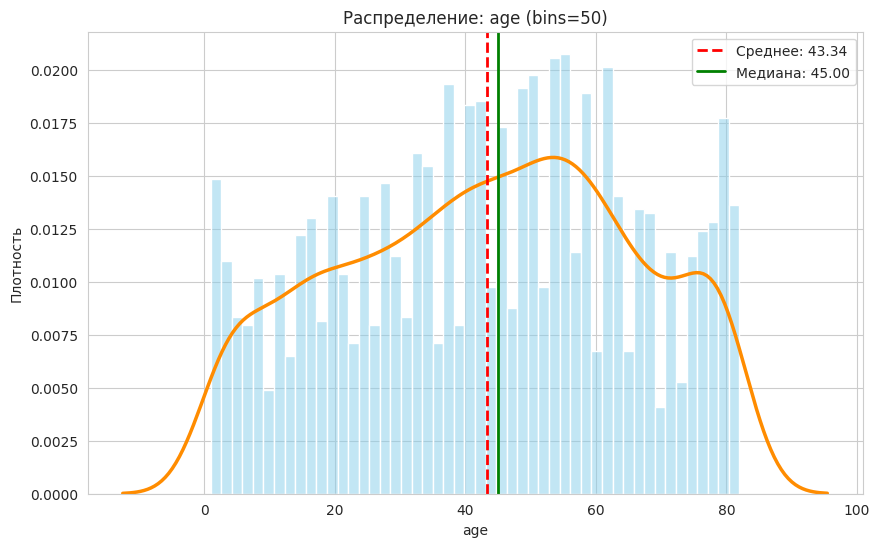

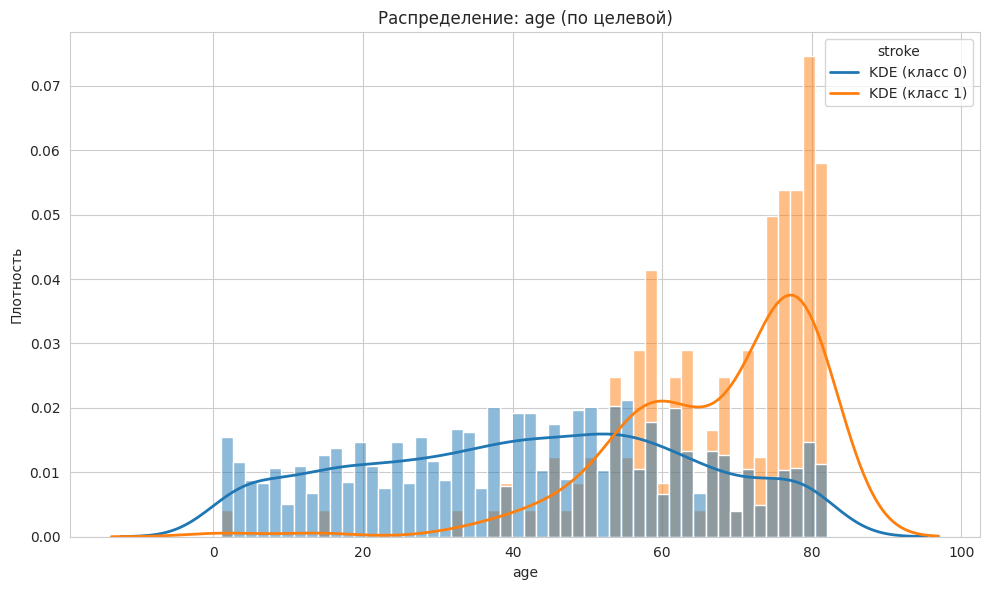


  📊 [2/3] avg_glucose_level


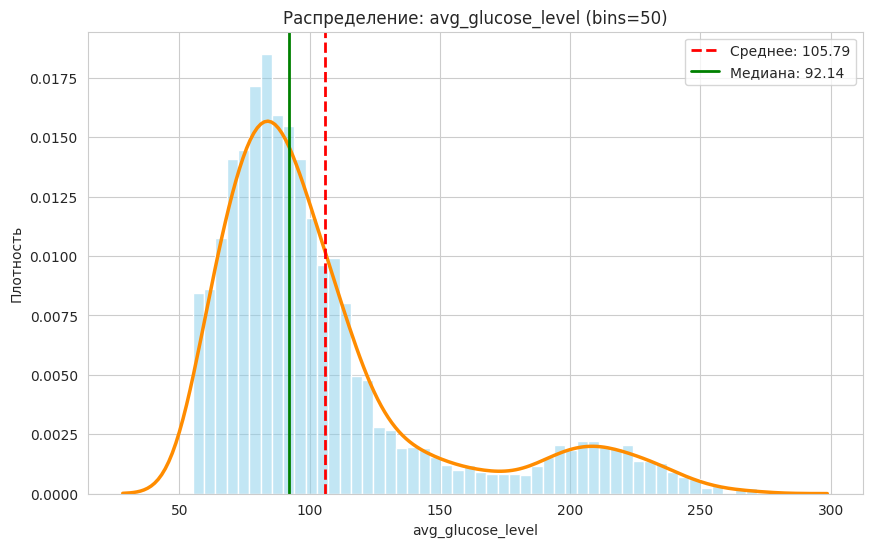

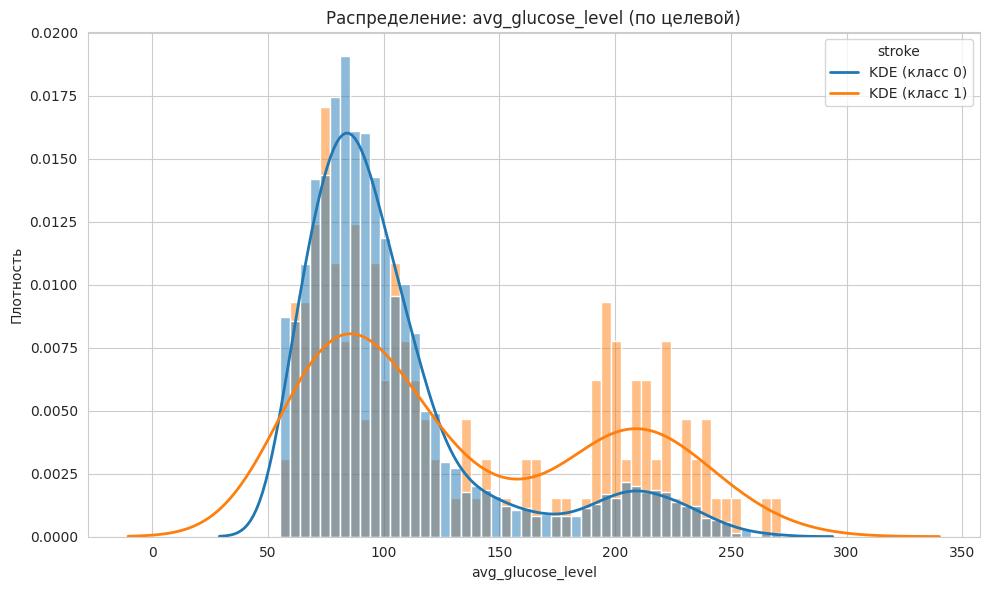


  📊 [3/3] bmi


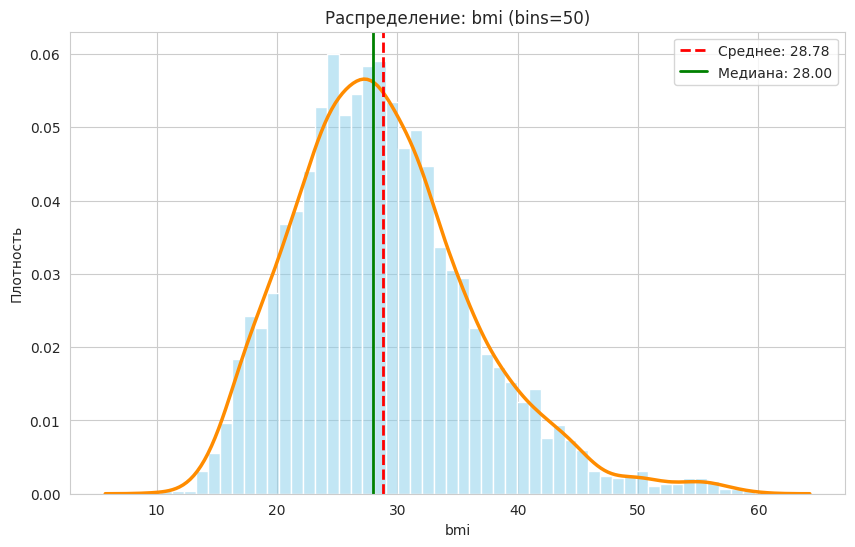

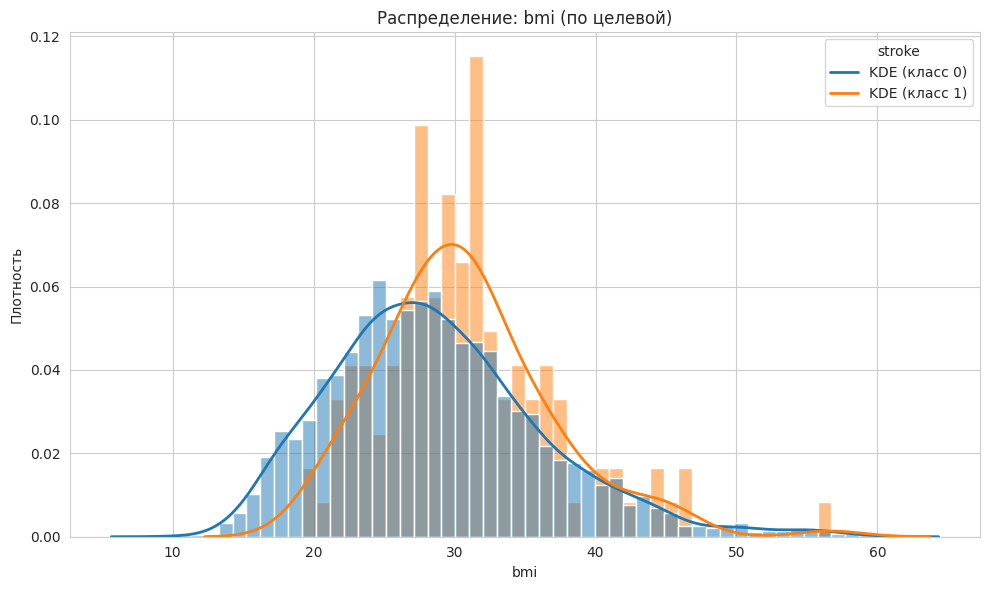


✅ Графики сохранены в: /content/drive/MyDrive/ml_learning/datasets/stroke/cycle_5/eda/plots

✓ Визуализация числовых признаков завершена



In [ ]:
# 2.4 ВИЗУАЛИЗАЦИЯ ЧИСЛОВЫХ КОЛОНОК (непрерывные)

print("\n" + "="*50)
print("📊 ВИЗУАЛИЗАЦИЯ ЧИСЛОВЫХ ПРИЗНАКОВ")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    # Рекомендация по bins
    auto_bins = int(np.sqrt(len(X_train)))
    print(f"\n📐 AUTO_BINS: {auto_bins} (√{len(X_train)})")
    print(f"🔧 Используется BINS: {BINS}")

    # Определяем непрерывные колонки
    numeric_cols = X_train.select_dtypes(include=['int64', 'Int64', 'float64', 'int32', 'float32']).columns.tolist()
    continuous_cols = [col for col in numeric_cols if X_train[col].nunique() > 2]

    if len(continuous_cols) == 0:
        print("\n⚠️ Нет непрерывных числовых колонок для визуализации")
    else:
        print(f"\n📌 Непрерывные признаки ({len(continuous_cols)}): {continuous_cols}")
        print(f"\n💾 Графики сохраняются в: {EDA_PLOTS_PATH}")

        for i, col in enumerate(continuous_cols, 1):
            mean_val = X_train[col].mean()
            median_val = X_train[col].median()

            print(f"\n  📊 [{i}/{len(continuous_cols)}] {col}")

            # --------------------------------------------
            # График 1: Общее распределение
            # --------------------------------------------
            plt.figure(figsize=(10, 6))

            sns.histplot(X_train[col], bins=BINS, color='skyblue', alpha=0.5, stat='density')
            sns.kdeplot(X_train[col], color='darkorange', linewidth=2.5)

            plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_val:.2f}')
            plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Медиана: {median_val:.2f}')

            plt.title(f'Распределение: {col} (bins={BINS})')
            plt.xlabel(col)
            plt.ylabel('Плотность')
            plt.legend()

            plot_path = os.path.join(EDA_PLOTS_PATH, f'distribution_{col}.png')
            plt.savefig(plot_path, dpi=150, bbox_inches='tight')
            plt.show()
            plt.close()

            # --------------------------------------------
            # График 2: С разделением по целевой
            # --------------------------------------------
            if HUE_BY_TARGET and TASK_TYPE == 'classification' and y_train is not None and TARGET_COLUMN:
                # Проверка совместимости размеров
                if len(X_train) != len(y_train):
                    print(f"   ⚠️ Пропускаем разделение по целевой: размеры X_train и y_train не совпадают")
                else:
                    plt.figure(figsize=(10, 6))

                    plot_df = pd.DataFrame({col: X_train[col], TARGET_COLUMN: y_train})

                    sns.histplot(data=plot_df, x=col, hue=TARGET_COLUMN, bins=BINS,
                                alpha=0.5, stat='density', common_norm=False)

                    for target_val in y_train.unique():
                        subset = plot_df[plot_df[TARGET_COLUMN] == target_val]
                        if len(subset) > 1:
                            sns.kdeplot(data=subset, x=col, linewidth=2, label=f'KDE (класс {target_val})')

                    plt.title(f'Распределение: {col} (по целевой)')
                    plt.xlabel(col)
                    plt.ylabel('Плотность')
                    plt.legend(title=TARGET_COLUMN)
                    plt.tight_layout()

                    plot_path_hue = os.path.join(EDA_PLOTS_PATH, f'distribution_{col}_by_target.png')
                    plt.savefig(plot_path_hue, dpi=150, bbox_inches='tight')
                    plt.show()
                    plt.close()

        print(f"\n✅ Графики сохранены в: {EDA_PLOTS_PATH}")

print("\n" + "="*50)
print("✓ Визуализация числовых признаков завершена")
print("="*50 + "\n")

# Viz label


🎯 ВИЗУАЛИЗАЦИЯ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

📊 Распределение классов:
   0:   2882 ( 95.1%)
   1:    149 (  4.9%)

⚠️ Дисбаланс классов: 19.3:1
   → RF_CLASS_WEIGHT = 'balanced' уже установлено


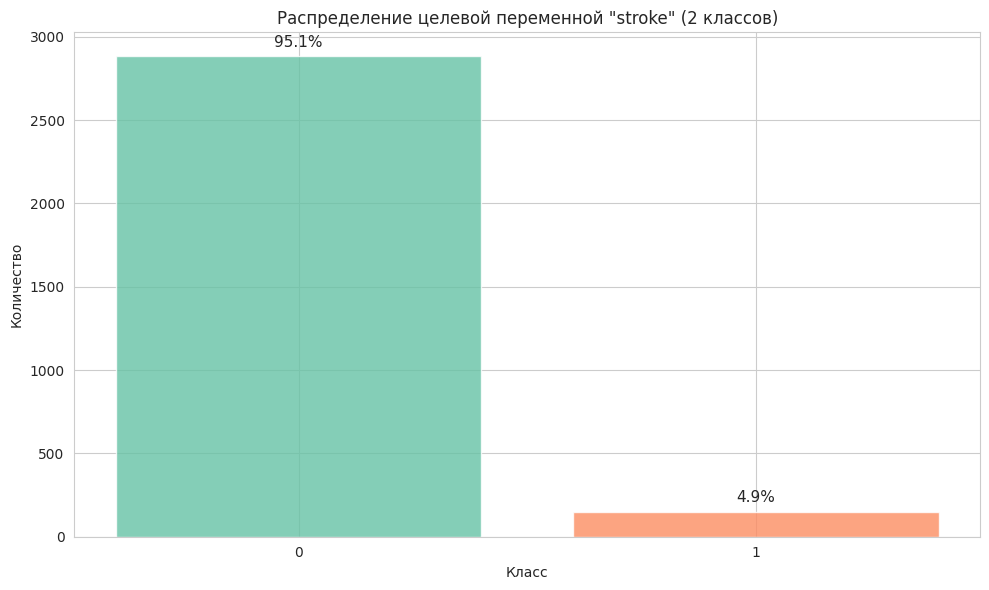


✅ График сохранён: plots/target_distribution.png

✓ Визуализация целевой переменной завершена



In [ ]:
# 2.5 ВИЗУАЛИЗАЦИЯ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

print("\n" + "="*50)
print("🎯 ВИЗУАЛИЗАЦИЯ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
print("="*50)

if y_train is None:
    print("\n⚠️ y_train не загружен. Пропускаем.")
else:
    # Защита от None в TARGET_COLUMN
    target_display = TARGET_COLUMN if TARGET_COLUMN else 'target'

    plt.figure(figsize=(10, 6))

    if TASK_TYPE == 'classification':
        # Для классификации — столбчатая диаграмма
        class_counts = y_train.value_counts()
        colors = plt.cm.Set2(range(len(class_counts)))

        bars = plt.bar(range(len(class_counts)), class_counts.values, color=colors, alpha=0.8)
        plt.xticks(range(len(class_counts)), class_counts.index)
        plt.title(f'Распределение целевой переменной "{target_display}" ({len(class_counts)} классов)')
        plt.xlabel('Класс')
        plt.ylabel('Количество')

        # Подписи с процентами
        for i, (cls, count) in enumerate(class_counts.items()):
            percentage = count / len(y_train) * 100
            plt.text(i, count + max(class_counts.values) * 0.02,
                    f'{percentage:.1f}%', ha='center', fontsize=11)

        print("\n📊 Распределение классов:")
        for cls, count in class_counts.items():
            pct = count / len(y_train) * 100
            print(f"   {cls}: {count:>6} ({pct:>5.1f}%)")

        # Краткое напоминание о дисбалансе
        min_class_pct = class_counts.min() / len(y_train) * 100
        if min_class_pct < 10:
            imbalance_ratio = class_counts.max() / class_counts.min()
            print(f"\n⚠️ Дисбаланс классов: {imbalance_ratio:.1f}:1")
            print(f"   → RF_CLASS_WEIGHT = 'balanced' уже установлено")

    else:
        # Для регрессии: гистограмма + KDE + статистика
        mean_val = y_train.mean()
        median_val = y_train.median()

        print(f"\n📊 Статистика целевой переменной:")
        print(f"   Среднее: {mean_val:.2f}")
        print(f"   Медиана: {median_val:.2f}")
        print(f"   Мин: {y_train.min():.2f}")
        print(f"   Макс: {y_train.max():.2f}")
        print(f"   Станд. отклонение: {y_train.std():.2f}")

        # Гистограмма с KDE
        sns.histplot(y_train, bins=BINS, stat='density',
                    color='skyblue', alpha=0.5, label='Гистограмма')
        sns.kdeplot(y_train, color='darkorange', linewidth=2.5, label='KDE')

        # Линии среднего и медианы
        plt.axvline(mean_val, color='red', linestyle='--', linewidth=2,
                   label=f'Среднее: {mean_val:.2f}')
        plt.axvline(median_val, color='green', linestyle='-', linewidth=2,
                   label=f'Медиана: {median_val:.2f}')

        plt.title(f'Распределение целевой переменной "{target_display}" (регрессия)')
        plt.xlabel('Значение')
        plt.ylabel('Плотность')
        plt.legend()

    plt.tight_layout()
    plot_path = os.path.join(EDA_PLOTS_PATH, 'target_distribution.png')
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n✅ График сохранён: plots/target_distribution.png")

print("\n" + "="*50)
print("✓ Визуализация целевой переменной завершена")
print("="*50 + "\n")


🔘 АНАЛИЗ БИНАРНЫХ ПРИЗНАКОВ

📊 Найдено бинарных признаков: 2
   ['hypertension', 'heart_disease']

----------------------------------------
📌 hypertension
----------------------------------------

📊 Распределение:
   Нет (0): 2744 (90.5%)
   Да (1): 287 (9.5%)

📊 Связь с stroke:
   Нет (0): 4.2% класса 1
   Да (1): 11.5% класса 1


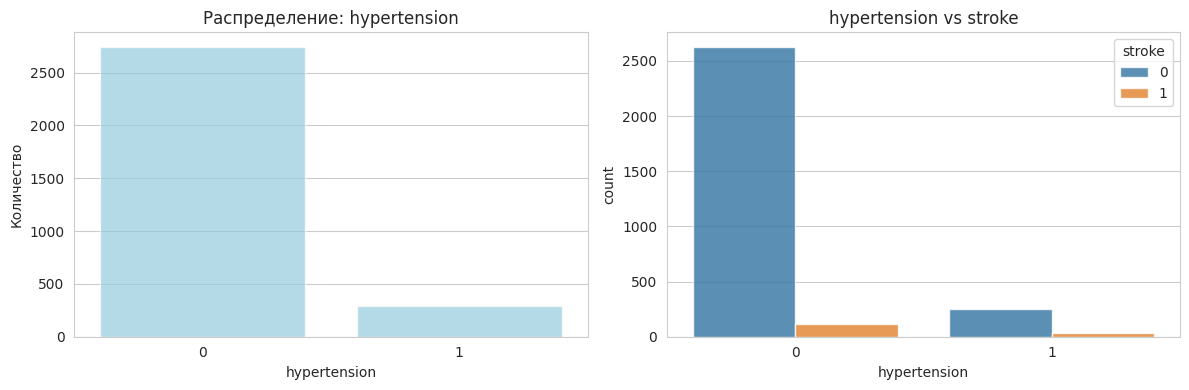


   ✓ График сохранён: plots/binary_hypertension.png

----------------------------------------
📌 heart_disease
----------------------------------------

📊 Распределение:
   Нет (0): 2866 (94.6%)
   Да (1): 165 (5.4%)

📊 Связь с stroke:
   Нет (0): 4.2% класса 1
   Да (1): 17.6% класса 1


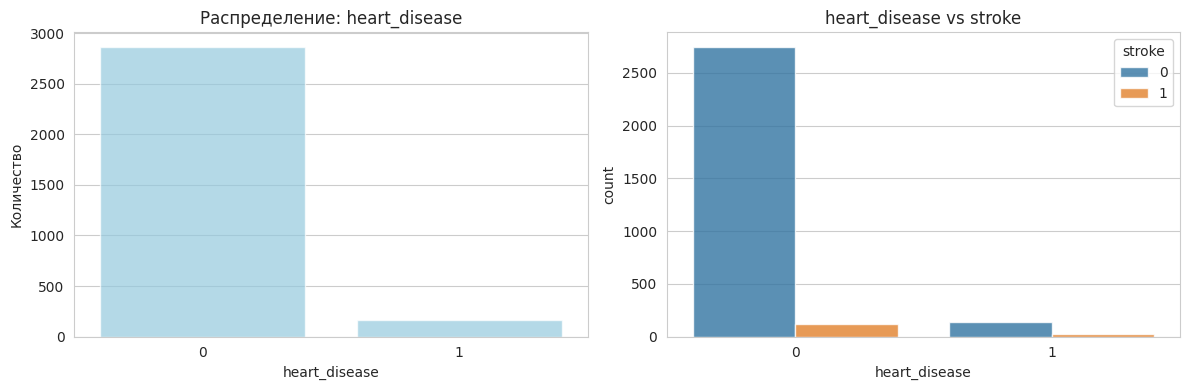


   ✓ График сохранён: plots/binary_heart_disease.png

📊 СВОДНАЯ ТАБЛИЦА БИНАРНЫХ ПРИЗНАКОВ


,Признак,% 1,stroke при 0,stroke при 1,Lift
0,hypertension,9.5%,4.2%,11.5%,🟢 2.7x
1,heart_disease,5.4%,4.2%,17.6%,🟢 4.2x



💡 Интерпретация Lift:
   🟢 >2.0x — сильное влияние
   🟡 1.5-2.0x — умеренное влияние
   🔴 <1.5x — слабое влияние

✓ Анализ бинарных признаков завершён



In [ ]:
# 2.6 АНАЛИЗ БИНАРНЫХ ПРИЗНАКОВ

print("\n" + "="*50)
print("🔘 АНАЛИЗ БИНАРНЫХ ПРИЗНАКОВ")
print("="*50)

if X_train is None or y_train is None:
    print("\n⚠️ Данные не загружены. Пропускаем.")
else:
    # Защита от None в TARGET_COLUMN
    target_display = TARGET_COLUMN if TARGET_COLUMN else 'target'

    # Находим бинарные колонки
    binary_cols = []
    for col in X_train.columns:
        if X_train[col].dtype in ['int64', 'Int64', 'float64', 'bool']:
            if X_train[col].nunique() <= 2:
                binary_cols.append(col)

    if len(binary_cols) == 0:
        print("\n⚠️ Бинарных признаков не обнаружено")
    else:
        print(f"\n📊 Найдено бинарных признаков: {len(binary_cols)}")
        print(f"   {binary_cols}")

        for col in binary_cols:
            print(f"\n" + "-"*40)
            print(f"📌 {col}")
            print("-"*40)

            # Распределение
            print(f"\n📊 Распределение:")
            value_counts = X_train[col].value_counts()
            for val, cnt in value_counts.items():
                pct = cnt / len(X_train) * 100
                val_name = "Да" if val == 1 else ("Нет" if val == 0 else str(val))
                print(f"   {val_name} ({val}): {cnt} ({pct:.1f}%)")

            # Связь с целевой
            if TASK_TYPE == 'classification' and TARGET_COLUMN:
                cross_tab = pd.crosstab(X_train[col], y_train, normalize='index') * 100
                print(f"\n📊 Связь с {target_display}:")
                for idx in cross_tab.index:
                    val_name = "Да" if idx == 1 else ("Нет" if idx == 0 else str(idx))
                    if 1 in cross_tab.columns:
                        target_pct = cross_tab.loc[idx, 1]
                        print(f"   {val_name} ({idx}): {target_pct:.1f}% класса 1")
            elif TASK_TYPE != 'classification' and TARGET_COLUMN:
                # Для регрессии: среднее целевой
                print(f"\n📊 Связь с {target_display} (среднее):")
                for val in value_counts.index:
                    subset = y_train[X_train[col] == val]
                    val_name = "Да" if val == 1 else ("Нет" if val == 0 else str(val))
                    print(f"   {val_name} ({val}): {subset.mean():.2f}")

            # Визуализация
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))

            # График 1: распределение
            sns.countplot(x=X_train[col], ax=axes[0], color='skyblue', alpha=0.7)
            axes[0].set_title(f'Распределение: {col}')
            axes[0].set_xlabel(col)
            axes[0].set_ylabel('Количество')

            # График 2: связь с целевой (если TARGET_COLUMN задан)
            if TARGET_COLUMN:
                plot_df = pd.DataFrame({col: X_train[col], TARGET_COLUMN: y_train})
                if TASK_TYPE == 'classification':
                    sns.countplot(data=plot_df, x=col, hue=TARGET_COLUMN, ax=axes[1], alpha=0.8)
                    axes[1].legend(title=target_display)
                else:
                    sns.boxplot(data=plot_df, x=col, y=TARGET_COLUMN, ax=axes[1])
                axes[1].set_title(f'{col} vs {target_display}')
            else:
                axes[1].set_title(f'{col} (целевая не задана)')
                axes[1].text(0.5, 0.5, 'TARGET_COLUMN не задан',
                            ha='center', va='center', transform=axes[1].transAxes)

            axes[1].set_xlabel(col)

            plt.tight_layout()
            plot_path = os.path.join(EDA_PLOTS_PATH, f'binary_{col}.png')
            plt.savefig(plot_path, dpi=150, bbox_inches='tight')
            plt.show()
            print(f"\n   ✓ График сохранён: plots/binary_{col}.png")

        # Сводная таблица (только если TARGET_COLUMN задан и классификация)
        if TASK_TYPE == 'classification' and TARGET_COLUMN:
            print("\n" + "="*50)
            print("📊 СВОДНАЯ ТАБЛИЦА БИНАРНЫХ ПРИЗНАКОВ")
            print("="*50)

            summary_data = []
            for col in binary_cols:
                total_1 = (X_train[col] == 1).sum()
                pct_1 = total_1 / len(X_train) * 100
                target_rate_1 = y_train[X_train[col] == 1].mean() * 100 if total_1 > 0 else 0
                target_rate_0 = y_train[X_train[col] == 0].mean() * 100

                if target_rate_0 > 0:
                    lift = target_rate_1 / target_rate_0
                    if lift > 2:
                        indicator = "🟢"
                    elif lift > 1.5:
                        indicator = "🟡"
                    else:
                        indicator = "🔴"
                    lift_str = f'{indicator} {lift:.1f}x'
                else:
                    lift_str = '—'

                summary_data.append({
                    'Признак': col,
                    '% 1': f'{pct_1:.1f}%',
                    f'{target_display} при 0': f'{target_rate_0:.1f}%',
                    f'{target_display} при 1': f'{target_rate_1:.1f}%',
                    'Lift': lift_str
                })

            summary_df = pd.DataFrame(summary_data)
            display(summary_df)

            print("\n💡 Интерпретация Lift:")
            print("   🟢 >2.0x — сильное влияние")
            print("   🟡 1.5-2.0x — умеренное влияние")
            print("   🔴 <1.5x — слабое влияние")

print("\n" + "="*50)
print("✓ Анализ бинарных признаков завершён")
print("="*50 + "\n")

# БЛОК 3. Пустоты

In [ ]:
# 3.1 ПОИСК ВСЕХ ВИДОВ ПУСТОТ

print("\n" + "="*50)
print("🔍 ПОИСК ВСЕХ ВИДОВ ПУСТОТ")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
    empty_info = {}
else:
    def find_all_empty(df, col):
        """Находит все виды пустот в колонке"""
        empty_mask = pd.Series(False, index=df.index)

        # 1. Стандартные NaN
        empty_mask = empty_mask | df[col].isna()

        # 2. Строковые маркеры (object и string типы)
        if df[col].dtype in ['object', 'string']:
            col_str = df[col].astype(str).str.lower()
            for marker in EMPTY_MARKERS_STR:
                empty_mask = empty_mask | (col_str == marker.lower())

        # 3. Числовые маркеры
        if pd.api.types.is_numeric_dtype(df[col]):
            for marker in EMPTY_MARKERS_NUM:
                empty_mask = empty_mask | (df[col] == marker)

        return empty_mask

    # Копия для анализа (оригинал не трогаем)
    X_train_analysis = X_train.copy()

    # Словарь для хранения информации
    empty_info = {}

    print("\n🔍 Поиск пустот в X_train:\n")

    for col in X_train_analysis.columns:
        empty_mask = find_all_empty(X_train_analysis, col)
        empty_count = empty_mask.sum()

        if empty_count > 0:
            # Определяем уровень проблемы
            pct = empty_count / len(X_train_analysis) * 100
            if pct > 60:
                level = "🔴"
            elif pct > 20:
                level = "🟠"
            elif pct > 5:
                level = "🟡"
            else:
                level = "🟢"

            empty_info[col] = {
                'count': empty_count,
                'percent': pct,
                'mask': empty_mask,
                'level': level
            }

            print(f"{level} {col}: {empty_count} ({pct:.1f}%)")

            # Примеры найденных значений
            empty_values = X_train_analysis.loc[empty_mask, col].unique()[:5].tolist()
            print(f"   Примеры: {empty_values}")

    # Сводная таблица
    if empty_info:
        print("\n" + "-"*50)
        print("📊 СВОДНАЯ ТАБЛИЦА ПУСТОТ:")
        print("-"*50)

        summary_data = []
        for col, info in empty_info.items():
            summary_data.append({
                'Колонка': col,
                'Пропусков': info['count'],
                'Процент': f"{info['percent']:.1f}%",
                'Уровень': info['level']
            })

        summary_df = pd.DataFrame(summary_data).sort_values('Пропусков', ascending=False)
        display(summary_df)
    else:
        print("\n✅ Пустот (включая скрытые) не обнаружено")

    # Проверка y_train (целевую НЕ копируем, только смотрим)
    print("\n" + "-"*50)
    print("🎯 ПРОВЕРКА y_train:")
    print("-"*50)

    y_empty_mask = find_all_empty(pd.DataFrame({'y': y_train}), 'y')
    y_empty_count = y_empty_mask.sum()

    if y_empty_count > 0:
        print(f"⚠️ В y_train найдено {y_empty_count} пустот")
        print(f"   Примеры: {y_train[y_empty_mask].head(5).tolist()}")
    else:
        print("✅ В y_train пустот не обнаружено")

    # Рекомендации
    if empty_info:
        print("\n📋 РЕКОМЕНДАЦИИ ПО ОБРАБОТКЕ:")
        print("-"*50)

        for col, info in empty_info.items():
            pct = info['percent']
            level = info['level']

            if pct > 60:
                rec = "🗑️ УДАЛИТЬ колонку"
            elif pct > 20:
                rec = "⚠️ СОЗДАТЬ ФЛАГ + заполнить"
            elif pct > 5:
                rec = "📝 ЗАПОЛНИТЬ или создать флаг"
            else:
                rec = "✅ ЗАПОЛНИТЬ (мода/медиана)"

            print(f"   {level} {col}: {pct:.1f}% → {rec}")

print("\n" + "="*50)
print("✓ Поиск пустот завершён")
print("="*50 + "\n")


🔍 ПОИСК ВСЕХ ВИДОВ ПУСТОТ

🔍 Поиск пустот в X_train:

🟢 bmi: 114 (3.8%)
   Примеры: [nan]
🟠 smoking_status: 868 (28.6%)
   Примеры: ['unknown']

--------------------------------------------------
📊 СВОДНАЯ ТАБЛИЦА ПУСТОТ:
--------------------------------------------------


,Колонка,Пропусков,Процент,Уровень
1,smoking_status,868,28.6%,🟠
0,bmi,114,3.8%,🟢



--------------------------------------------------
🎯 ПРОВЕРКА y_train:
--------------------------------------------------
✅ В y_train пустот не обнаружено

📋 РЕКОМЕНДАЦИИ ПО ОБРАБОТКЕ:
--------------------------------------------------
   🟢 bmi: 3.8% → ✅ ЗАПОЛНИТЬ (мода/медиана)
   🟠 smoking_status: 28.6% → ⚠️ СОЗДАТЬ ФЛАГ + заполнить

✓ Поиск пустот завершён



In [ ]:
# 3.2 СТРАТЕГИЯ ОБРАБОТКИ ПРОПУСКОВ

print("\n" + "="*50)
print("📋 СТРАТЕГИЯ ОБРАБОТКИ ПРОПУСКОВ")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    # Проверка наличия empty_info (из блока 3.1)
    if 'empty_info' not in globals():
        print("\n⚠️ empty_info не найден. Выполните блок 3.1")
        empty_info = {}

    if missing_strategy:
        print("\n📊 Выбранные стратегии:\n")

        # Статистика по стратегиям
        strategy_counts = {}
        valid_cols = []
        invalid_cols = []

        for col, (strategy, param) in missing_strategy.items():
            if col in X_train.columns:
                valid_cols.append(col)
                strategy_counts[strategy] = strategy_counts.get(strategy, 0) + 1

                if param:
                    print(f"   • {col}: {strategy} (параметр: {param})")
                else:
                    print(f"   • {col}: {strategy}")
            else:
                invalid_cols.append(col)

        # Предупреждение о несуществующих колонках
        if invalid_cols:
            print(f"\n⚠️ Колонки не найдены в X_train: {invalid_cols}")

        # Сводка
        if strategy_counts:
            print(f"\n📊 Сводка по стратегиям:")
            for strategy, count in strategy_counts.items():
                print(f"   {strategy}: {count} колонок")

        # ============================================
        # ДОПОЛНИТЕЛЬНО: ГРУППОВОЕ ЗАПОЛНЕНИЕ
        # ============================================
        if 'GROUPED_IMPUTATION_CONFIG' in globals() and GROUPED_IMPUTATION_CONFIG:
            print(f"\n📊 Групповое заполнение (grouped_imputation):")
            for col, cfg in GROUPED_IMPUTATION_CONFIG.items():
                strategy = cfg.get('strategy', 'median')
                groupby = cfg.get('groupby_col', '?')
                create_flag = cfg.get('create_flag', False)
                flag_info = f", флаг {col}_missing_flag" if create_flag else ""
                print(f"   • {col}: {strategy} по группам {groupby}{flag_info}")

        # Проверка: есть ли колонки с пропусками без стратегии
        if empty_info:
            cols_with_empty = set(empty_info.keys())
            cols_with_strategy = set(valid_cols)
            missing_strategy_cols = cols_with_empty - cols_with_strategy

            if missing_strategy_cols:
                print(f"\n⚠️ Колонки с пропусками БЕЗ стратегии:")
                for col in missing_strategy_cols:
                    pct = empty_info[col]['percent']
                    print(f"   • {col}: {pct:.1f}% пропусков")
                print(f"\n💡 Добавьте их в missing_strategy в блоке 1.2")

    else:
        print("\n⚠️ Словарь missing_strategy пуст.")
        print("   Заполните его в блоке 1.2 на основе анализа:")

        if empty_info:
            print(f"\n   Найдено колонок с пропусками: {len(empty_info)}")
            for col, info in list(empty_info.items())[:5]:
                print(f"   • {col}: {info['percent']:.1f}%")
            if len(empty_info) > 5:
                print(f"   ... и ещё {len(empty_info) - 5}")

            print(f"\n   📝 Пример заполнения:")
            print(f"   missing_strategy = {{")
            first_col = list(empty_info.keys())[0]
            print(f"       '{first_col}': ('median', None),")
            print(f"       # 'колонка': ('стратегия', 'параметр')")
            print(f"   }}")
        else:
            print("\n   ✅ Пропусков не обнаружено, стратегия не требуется")
print("\n" + "="*50)
print("✓ Анализ стратегии завершён")
print("="*50 + "\n")


📋 СТРАТЕГИЯ ОБРАБОТКИ ПРОПУСКОВ

📊 Выбранные стратегии:

   • smoking_status: constant (параметр: unknown)

📊 Сводка по стратегиям:
   constant: 1 колонок

📊 Групповое заполнение (grouped_imputation):
   • bmi: median по группам age, флаг bmi_missing_flag

⚠️ Колонки с пропусками БЕЗ стратегии:
   • bmi: 3.8% пропусков

💡 Добавьте их в missing_strategy в блоке 1.2

✓ Анализ стратегии завершён



In [ ]:
# 3.3 ПРИМЕНЕНИЕ СТРАТЕГИЙ ОБРАБОТКИ ПРОПУСКОВ

print("\n" + "="*50)
print("🔧 ПРИМЕНЕНИЕ СТРАТЕГИЙ ОБРАБОТКИ ПРОПУСКОВ")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
    X_train_clean = None
    X_val_clean = None
    X_test_clean = None
    flag_columns = []
else:
    # Проверка наличия empty_info
    if 'empty_info' not in globals():
        empty_info = {}

    # Словари для хранения параметров заполнения (для применения к Val/Test)
    fill_values = {}        # col -> значение для заполнения
    columns_to_drop = []    # колонки для удаления
    flag_columns = []       # созданные флаги

    # ============================================
    # ШАГ 1: Создаём копии всех выборок
    # ============================================
    X_train_clean = X_train.copy()
    X_val_clean = X_val.copy() if X_val is not None else None
    X_test_clean = X_test.copy() if X_test is not None else None

    # ============================================
    # ШАГ 2: Замена скрытых пустот на NaN (для всех выборок)
    # ============================================
    if empty_info:
        print("\n🔄 Замена скрытых пустот на NaN...")

        # Для Train используем готовые маски из empty_info
        for col, info in empty_info.items():
            if col in X_train_clean.columns:
                X_train_clean.loc[info['mask'], col] = np.nan
                print(f"   ✓ Train - {col}: {info['count']} значений → NaN")

        # Для Val и Test ищем те же маркеры (повторяем логику из 3.1)
        def replace_markers(df, col):
            if col not in df.columns:
                return 0
            empty_mask = pd.Series(False, index=df.index)

            # Строковые маркеры
            if df[col].dtype == 'object':
                col_str = df[col].astype(str).str.lower()
                for marker in EMPTY_MARKERS_STR:
                    empty_mask = empty_mask | (col_str == marker.lower())

            # Числовые маркеры
            if pd.api.types.is_numeric_dtype(df[col]):
                for marker in EMPTY_MARKERS_NUM:
                    empty_mask = empty_mask | (df[col] == marker)

            count = empty_mask.sum()
            if count > 0:
                df.loc[empty_mask, col] = np.nan
            return count

        if X_val_clean is not None:
            for col in empty_info.keys():
                count = replace_markers(X_val_clean, col)
                if count > 0:
                    print(f"   ✓ Val - {col}: {count} значений → NaN")

        if X_test_clean is not None:
            for col in empty_info.keys():
                count = replace_markers(X_test_clean, col)
                if count > 0:
                    print(f"   ✓ Test - {col}: {count} значений → NaN")

    # ============================================
    # ШАГ 3: Анализ стратегий и вычисление параметров на TRAIN
    # ============================================
    if missing_strategy:
        print("\n📌 Анализ стратегий на Train:\n")

        for col, (strategy, param) in missing_strategy.items():
            if col not in X_train_clean.columns:
                print(f"   ⚠️ Колонка '{col}' не найдена, пропускаем")
                continue

            print(f"   📍 {col}: {strategy}", end="")

            if strategy == 'drop_column':
                columns_to_drop.append(col)
                print(f" → колонка будет удалена")

            elif strategy == 'mode':
                mode_vals = X_train_clean[col].mode()
                val = mode_vals[0] if not mode_vals.empty else 'unknown'
                fill_values[col] = val
                print(f" → мода = '{val}'")

            elif strategy == 'median':
                val = X_train_clean[col].median()
                fill_values[col] = val
                print(f" → медиана = {val:.2f}")

            elif strategy == 'mean':
                val = X_train_clean[col].mean()
                fill_values[col] = val
                print(f" → среднее = {val:.2f}")

            elif strategy == 'constant':
                val = param if param is not None else 'unknown'
                fill_values[col] = val
                print(f" → константа = '{val}'")

            elif strategy == 'flag':
                flag_col = f'{col}_missing_flag'
                flag_columns.append(flag_col)

                # Определяем значение для заполнения
                if param == 'mode':
                    mode_vals = X_train_clean[col].mode()
                    val = mode_vals[0] if not mode_vals.empty else 'unknown'
                elif param == 'median':
                    val = X_train_clean[col].median()
                elif param == 'mean':
                    val = X_train_clean[col].mean()
                elif param is not None:
                    val = param
                else:
                    val = 'unknown'

                fill_values[col] = val
                print(f" → флаг {flag_col} + заполнение '{val}'")

            else:
                print(f" → ⚠️ неизвестная стратегия")

    # ============================================
    # ШАГ 4: Применение стратегий ко ВСЕМ выборкам
    # ============================================
    def apply_strategies(df, df_name, fill_values, columns_to_drop, flag_columns):
        """Применяет стратегии обработки пропусков к датафрейму"""
        if df is None:
            return df

        df = df.copy()

        # 4.1 Создаём флаги
        for flag_col in flag_columns:
            base_col = flag_col.replace('_missing_flag', '')
            if base_col in df.columns:
                df[flag_col] = df[base_col].isna().astype(int)

        # 4.2 Заполняем пропуски
        for col, val in fill_values.items():
            if col in df.columns:
                df[col].fillna(val, inplace=True)

        # 4.3 Удаляем колонки
        cols_to_drop_existing = [c for c in columns_to_drop if c in df.columns]
        if cols_to_drop_existing:
            df.drop(columns=cols_to_drop_existing, inplace=True)

        return df

    print("\n🔧 Применение стратегий ко всем выборкам:")

    X_train_clean = apply_strategies(X_train_clean, "Train", fill_values, columns_to_drop, flag_columns)
    print(f"   ✓ Train обработан: {X_train_clean.shape}")

    if X_val_clean is not None:
        X_val_clean = apply_strategies(X_val_clean, "Val", fill_values, columns_to_drop, flag_columns)
        print(f"   ✓ Val обработан: {X_val_clean.shape}")

    if X_test_clean is not None:
        X_test_clean = apply_strategies(X_test_clean, "Test", fill_values, columns_to_drop, flag_columns)
        print(f"   ✓ Test обработан: {X_test_clean.shape}")


    # ==========   FEATURE ENGINEERING ЗДЕСЬ ==========
    print("\n🔧 ПРИМЕНЕНИЕ FEATURE ENGINEERING ПОСЛЕ ОБРАБОТКИ ПРОПУСКОВ:")

    X_train_clean = create_features(X_train_clean)
    print(f"   ✓ Train: FE применён, {X_train_clean.shape[1]} признаков")

    if X_val_clean is not None:
        X_val_clean = create_features(X_val_clean)
        print(f"   ✓ Val: FE применён, {X_val_clean.shape[1]} признаков")

    if X_test_clean is not None:
        X_test_clean = create_features(X_test_clean)
        print(f"   ✓ Test: FE применён, {X_test_clean.shape[1]} признаков")

    # ============================================
    # 🆕 ГРУППОВОЕ ЗАПОЛНЕНИЕ ПРОПУСКОВ
    # ============================================
    if 'GROUPED_IMPUTATION_CONFIG' in globals() and GROUPED_IMPUTATION_CONFIG:
        print("\n📊 Групповое заполнение пропусков:")

        grouped_imputation_values = {}

        for col, cfg in GROUPED_IMPUTATION_CONFIG.items():
            if col not in X_train_clean.columns:
                print(f"   ⚠️ {col}: не найдена, пропускаем")
                continue

            # Применяем к Train (fit)
            X_train_clean, group_values = grouped_imputation(
                X_train_clean,
                {col: cfg},
                mode='fit'
            )
            grouped_imputation_values[col] = group_values
            print(f"   ✓ {col}: заполнено по {cfg['groupby_col']} ({cfg['strategy']})")

            # Применяем к Val (transform)
            if X_val_clean is not None:
                X_val_clean, _ = grouped_imputation(
                    X_val_clean,
                    {col: cfg},
                    group_values_dict=group_values,
                    mode='transform'
                )

            # Применяем к Test (transform)
            if X_test_clean is not None:
                X_test_clean, _ = grouped_imputation(
                    X_test_clean,
                    {col: cfg},
                    group_values_dict=group_values,
                    mode='transform'
                )

            # Добавляем колонку в flag_columns (если нужно)
            if cfg.get('create_flag', False):
                flag_col = f'{col}_missing_flag'
                if flag_col not in flag_columns:
                    flag_columns.append(flag_col)

        # ============================================
        # СОХРАНЯЕМ grouped_imputation_values
        # ============================================
        if grouped_imputation_values:
            grouped_values_path = os.path.join(EDA_TRANSFORMERS_PATH, 'grouped_imputation_values.pkl')
            joblib.dump(grouped_imputation_values, grouped_values_path)
            print(f"\n💾 Сохранены grouped_imputation_values: transformers/grouped_imputation_values.pkl")

    # ============================================
    # ШАГ 5: Проверка результатов
    # ============================================
    print("\n📊 Проверка результатов:")

    train_nulls = X_train_clean.isnull().sum().sum()
    val_nulls = X_val_clean.isnull().sum().sum() if X_val_clean is not None else 0
    test_nulls = X_test_clean.isnull().sum().sum() if X_test_clean is not None else 0

    if train_nulls == 0 and val_nulls == 0 and test_nulls == 0:
        print(f"   ✅ Пропусков не осталось")
    else:
        print(f"   ⚠️ Остались пропуски: Train={train_nulls}, Val={val_nulls}, Test={test_nulls}")

    if columns_to_drop:
        print(f"   🗑️ Удалены колонки: {columns_to_drop}")

    if flag_columns:
        print(f"   🚩 Созданы флаги: {flag_columns}")

    if fill_values:
        print(f"   📝 Заполнены колонки: {list(fill_values.keys())}")

print("\n" + "="*50)
print("✓ Применение стратегий завершено")
print("="*50 + "\n")


🔧 ПРИМЕНЕНИЕ СТРАТЕГИЙ ОБРАБОТКИ ПРОПУСКОВ

🔄 Замена скрытых пустот на NaN...
   ✓ Train - bmi: 114 значений → NaN
   ✓ Train - smoking_status: 868 значений → NaN
   ✓ Val - smoking_status: 316 значений → NaN
   ✓ Test - smoking_status: 313 значений → NaN

📌 Анализ стратегий на Train:

   📍 smoking_status: constant → константа = 'unknown'

🔧 Применение стратегий ко всем выборкам:
   ✓ Train обработан: (3031, 10)
   ✓ Val обработан: (1011, 10)
   ✓ Test обработан: (1011, 10)

🔧 ПРИМЕНЕНИЕ FEATURE ENGINEERING ПОСЛЕ ОБРАБОТКИ ПРОПУСКОВ:
   ✓ Train: FE применён, 15 признаков
   ✓ Val: FE применён, 15 признаков
   ✓ Test: FE применён, 15 признаков

📊 Групповое заполнение пропусков:
   ✓ bmi: заполнено по age (median)

💾 Сохранены grouped_imputation_values: transformers/grouped_imputation_values.pkl

📊 Проверка результатов:
   ✅ Пропусков не осталось
   🚩 Созданы флаги: ['bmi_missing_flag']
   📝 Заполнены колонки: ['smoking_status']

✓ Применение стратегий завершено



In [ ]:
# 3.4 ПРОВЕРКА РЕЗУЛЬТАТА ОБРАБОТКИ ПРОПУСКОВ

print("\n" + "="*50)
print("✅ ПРОВЕРКА РЕЗУЛЬТАТА ОБРАБОТКИ")
print("="*50)

if 'X_train_clean' not in globals() or X_train_clean is None:
    print("\n⚠️ X_train_clean не найден. Выполните блок 3.3.")
else:
    # ============================================
    # Сравнение Train с оригиналом
    # ============================================
    print(f"\n📊 Сравнение Train с оригиналом:")
    print(f"   До:  {X_train.shape[0]} строк, {X_train.shape[1]} колонок")
    print(f"   После: {X_train_clean.shape[0]} строк, {X_train_clean.shape[1]} колонок")

    if X_train.shape[1] != X_train_clean.shape[1]:
        removed = set(X_train.columns) - set(X_train_clean.columns)
        added = set(X_train_clean.columns) - set(X_train.columns)
        if removed:
            print(f"   Удалены: {list(removed)}")
        if added:
            print(f"   Добавлены (флаги): {list(added)}")

    # ============================================
    # Проверка Train на NaN
    # ============================================
    train_nulls = X_train_clean.isnull().sum().sum()

    if train_nulls > 0:
        print(f"\n⚠️ Train: осталось {train_nulls} NaN")
        print("   Колонки с NaN:")
        missing_cols = X_train_clean.columns[X_train_clean.isnull().any()].tolist()
        for col in missing_cols:
            count = X_train_clean[col].isnull().sum()
            pct = count / len(X_train_clean) * 100
            print(f"      • {col}: {count} ({pct:.1f}%)")
    else:
        print(f"\n✅ Train: NaN не осталось")

    # ============================================
    # Проверка Val на NaN
    # ============================================
    if 'X_val_clean' in globals() and X_val_clean is not None:
        val_nulls = X_val_clean.isnull().sum().sum()
        if val_nulls > 0:
            print(f"\n⚠️ Val: осталось {val_nulls} NaN")
            missing_cols = X_val_clean.columns[X_val_clean.isnull().any()].tolist()
            for col in missing_cols[:5]:
                count = X_val_clean[col].isnull().sum()
                pct = count / len(X_val_clean) * 100
                print(f"      • {col}: {count} ({pct:.1f}%)")
            if len(missing_cols) > 5:
                print(f"      ... и ещё {len(missing_cols) - 5}")
        else:
            print(f"✅ Val: NaN не осталось")
    else:
        print(f"\nℹ️ Val не обработан или не загружен")

    # ============================================
    # Проверка Test на NaN
    # ============================================
    if 'X_test_clean' in globals() and X_test_clean is not None:
        test_nulls = X_test_clean.isnull().sum().sum()
        if test_nulls > 0:
            print(f"\n⚠️ Test: осталось {test_nulls} NaN")
            missing_cols = X_test_clean.columns[X_test_clean.isnull().any()].tolist()
            for col in missing_cols[:5]:
                count = X_test_clean[col].isnull().sum()
                pct = count / len(X_test_clean) * 100
                print(f"      • {col}: {count} ({pct:.1f}%)")
            if len(missing_cols) > 5:
                print(f"      ... и ещё {len(missing_cols) - 5}")
        else:
            print(f"✅ Test: NaN не осталось")
    else:
        print(f"ℹ️ Test не обработан или не загружен")

    # ============================================
    # Проверка скрытых пустот в Train (быстрая)
    # ============================================
    hidden_empty_found = False
    # Проверяем object и string колонки
    str_cols = X_train_clean.select_dtypes(include=['object', 'string']).columns
    for col in str_cols:
        col_str = X_train_clean[col].astype(str).str.lower()
        for marker in EMPTY_MARKERS_STR:
            if (col_str == marker).any():
                count = (col_str == marker).sum()
                print(f"\n⚠️ Найдены скрытые пустоты: {col} содержит '{marker}' ({count} раз)")
                hidden_empty_found = True
                # Убираем break, продолжаем проверку других колонок

    # ============================================
    # Итог
    # ============================================
    all_nulls = train_nulls
    if 'X_val_clean' in globals() and X_val_clean is not None:
        all_nulls += X_val_clean.isnull().sum().sum()
    if 'X_test_clean' in globals() and X_test_clean is not None:
        all_nulls += X_test_clean.isnull().sum().sum()

    if not hidden_empty_found and all_nulls == 0:
        print(f"\n🎉 Данные полностью очищены от пропусков во всех выборках!")

    # ============================================
    # Информация о флагах
    # ============================================
    if 'flag_columns' in globals() and flag_columns:
        print(f"\n🚩 Созданные флаги пропусков:")
        for flag in flag_columns:
            if flag in X_train_clean.columns:
                ones = X_train_clean[flag].sum()
                pct = ones / len(X_train_clean) * 100
                print(f"   • {flag}: {ones} единиц ({pct:.1f}%)")

    # ============================================
    # Проверка консистентности колонок
    # ============================================
    if 'X_val_clean' in globals() and X_val_clean is not None:
        train_cols = set(X_train_clean.columns)
        val_cols = set(X_val_clean.columns)
        if train_cols != val_cols:
            diff = train_cols.symmetric_difference(val_cols)
            print(f"\n⚠️ Колонки Train и Val различаются: {diff}")

    if 'X_test_clean' in globals() and X_test_clean is not None:
        train_cols = set(X_train_clean.columns)
        test_cols = set(X_test_clean.columns)
        if train_cols != test_cols:
            diff = train_cols.symmetric_difference(test_cols)
            print(f"⚠️ Колонки Train и Test различаются: {diff}")

print("\n" + "="*50)
print("✓ Проверка завершена")
print("="*50 + "\n")


✅ ПРОВЕРКА РЕЗУЛЬТАТА ОБРАБОТКИ

📊 Сравнение Train с оригиналом:
   До:  3031 строк, 10 колонок
   После: 3031 строк, 16 колонок
   Добавлены (флаги): ['stable_old_age', 'bmi_missing_flag', 'smoking_age_impact', 'is_smoker', 'glucose_high_risk', 'cardio_risk']

✅ Train: NaN не осталось
✅ Val: NaN не осталось
✅ Test: NaN не осталось

⚠️ Найдены скрытые пустоты: smoking_status содержит 'unknown' (868 раз)

🚩 Созданные флаги пропусков:
   • bmi_missing_flag: 114 единиц (3.8%)

✓ Проверка завершена



# БЛОК 4. Выбросы


📊 ВИЗУАЛИЗАЦИЯ ВЫБРОСОВ (BOXPLOT)

📊 Все числовые колонки: 5
   Бинарные (исключены): ['hypertension', 'heart_disease']
   Непрерывные (анализ): ['age', 'avg_glucose_level', 'bmi']

📊 Статистика выбросов (IQR, коэффициент=1.5):
   age: 0 выбросов (0.0%)
   avg_glucose_level: 359 выбросов (11.8%)
   bmi: 60 выбросов (2.0%)

💾 Сохраняем графики в: /content/drive/MyDrive/ml_learning/datasets/stroke/cycle_5/eda/plots
   ✓ boxplot_age.png
   ✓ boxplot_avg_glucose_level.png
   ✓ boxplot_bmi.png


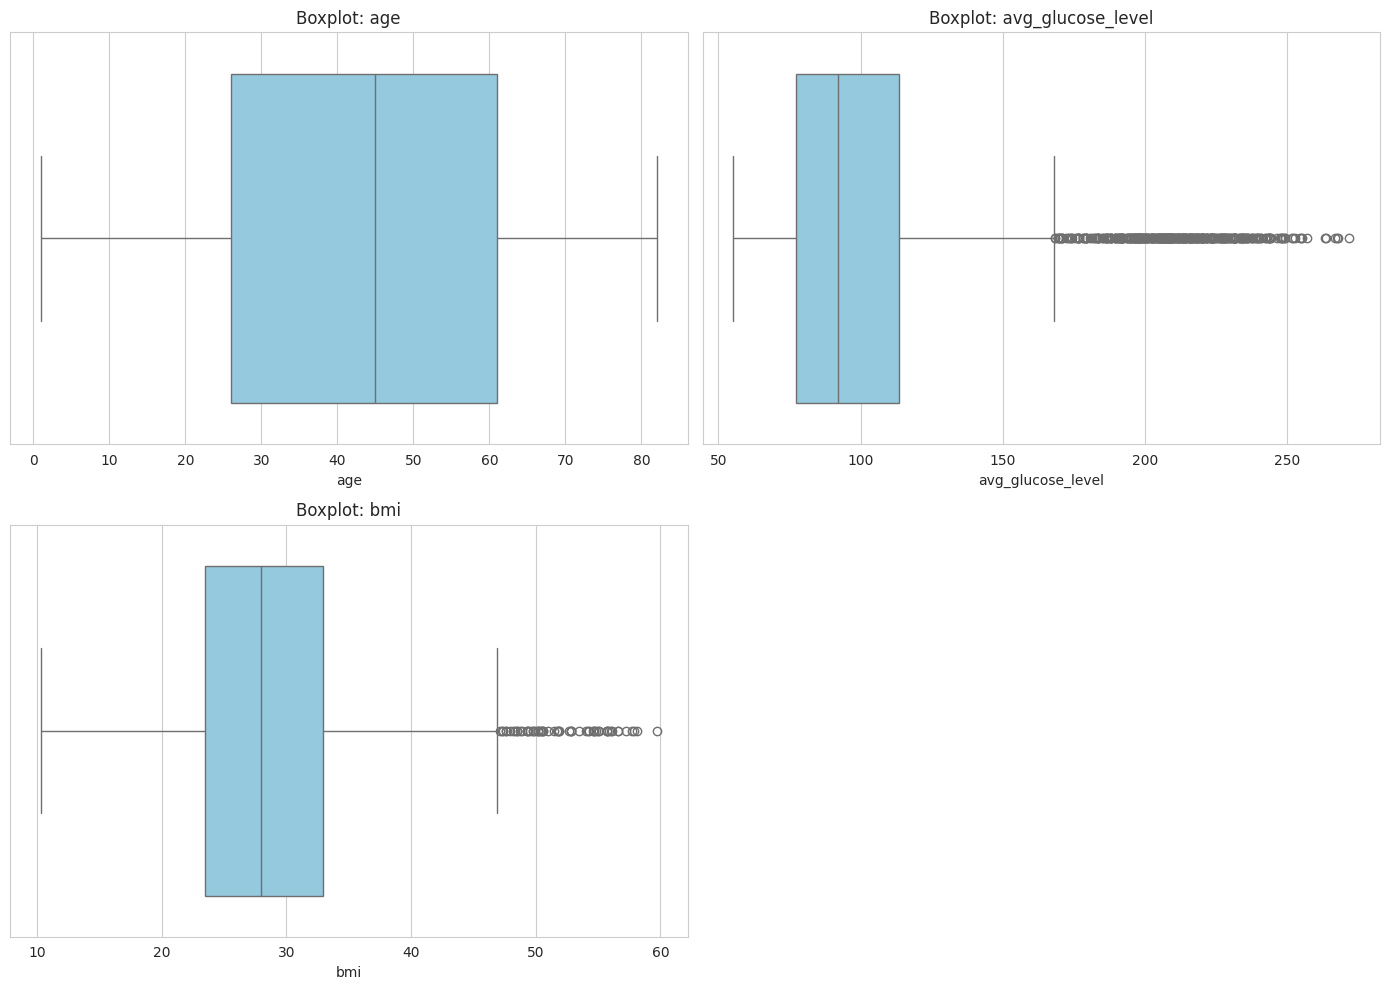


✅ Графики сохранены:
   • all_boxplots.png (все вместе)
   • boxplot_[col].png (по отдельности)
   • boxplot_[col]_by_target.png (с разделением по целевой)

✓ Визуализация выбросов завершена



In [ ]:
# 4.1 ВИЗУАЛИЗАЦИЯ ВЫБРОСОВ (BOXPLOT)

print("\n" + "="*50)
print("📊 ВИЗУАЛИЗАЦИЯ ВЫБРОСОВ (BOXPLOT)")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    # Определяем числовые колонки
    numeric_cols = X_train.select_dtypes(include=['int64', 'Int64', 'float64', 'int32', 'float32']).columns.tolist()

    # Исключаем бинарные
    binary_cols = [col for col in numeric_cols if X_train[col].nunique() <= 2]
    continuous_cols = [col for col in numeric_cols if X_train[col].nunique() > 2]

    print(f"\n📊 Все числовые колонки: {len(numeric_cols)}")
    print(f"   Бинарные (исключены): {binary_cols if binary_cols else 'нет'}")
    print(f"   Непрерывные (анализ): {continuous_cols if continuous_cols else 'нет'}")

    if len(continuous_cols) == 0:
        print("\n⚠️ Нет непрерывных колонок для анализа выбросов")
    else:
        # ============================================
        # СТАТИСТИКА ВЫБРОСОВ
        # ============================================
        print("\n📊 Статистика выбросов (IQR, коэффициент=1.5):")
        for col in continuous_cols:
            Q1 = X_train[col].quantile(0.25)
            Q3 = X_train[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            outliers = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
            pct = outliers / len(X_train) * 100
            print(f"   {col}: {outliers} выбросов ({pct:.1f}%)")

        print(f"\n💾 Сохраняем графики в: {EDA_PLOTS_PATH}")

        # Сетка графиков
        n_cols = len(continuous_cols)
        n_rows = (n_cols + 1) // 2

        fig, axes = plt.subplots(n_rows, 2, figsize=(14, 5 * n_rows))
        axes = axes.flatten() if n_cols > 1 else [axes]

        for i, col in enumerate(continuous_cols):
            # Boxplot
            sns.boxplot(x=X_train[col], ax=axes[i], color='skyblue')
            axes[i].set_title(f'Boxplot: {col}')
            axes[i].set_xlabel(col)

            # Сохраняем отдельный график
            plt.figure(figsize=(10, 4))
            sns.boxplot(x=X_train[col], color='skyblue')
            plt.title(f'Boxplot: {col}')
            plt.xlabel(col)

            plot_path = os.path.join(EDA_PLOTS_PATH, f'boxplot_{col}.png')
            plt.savefig(plot_path, dpi=150, bbox_inches='tight')
            plt.close()
            print(f"   ✓ boxplot_{col}.png")

            # Дополнительно: boxplot с hue по целевой (для классификации)
            if HUE_BY_TARGET and TASK_TYPE == 'classification' and y_train is not None and TARGET_COLUMN:
                plt.figure(figsize=(10, 4))
                plot_df = pd.DataFrame({col: X_train[col], TARGET_COLUMN: y_train})
                sns.boxplot(data=plot_df, x=TARGET_COLUMN, y=col, palette='Set2')

                target_display = TARGET_COLUMN if TARGET_COLUMN else 'target'
                plt.title(f'Boxplot: {col} vs {target_display}')
                plt.xlabel(target_display)
                plt.ylabel(col)

                hue_path = os.path.join(EDA_PLOTS_PATH, f'boxplot_{col}_by_target.png')
                plt.savefig(hue_path, dpi=150, bbox_inches='tight')
                plt.close()

        # Скрываем пустые подграфики
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        plt.tight_layout()
        all_path = os.path.join(EDA_PLOTS_PATH, 'all_boxplots.png')
        plt.savefig(all_path, dpi=150, bbox_inches='tight')
        plt.show()

        print(f"\n✅ Графики сохранены:")
        print(f"   • all_boxplots.png (все вместе)")
        print(f"   • boxplot_[col].png (по отдельности)")
        if HUE_BY_TARGET and TASK_TYPE == 'classification' and TARGET_COLUMN:
            print(f"   • boxplot_[col]_by_target.png (с разделением по целевой)")

print("\n" + "="*50)
print("✓ Визуализация выбросов завершена")
print("="*50 + "\n")

In [ ]:
# 4.2 СТАТИСТИКА ВЫБРОСОВ ПО МЕТОДУ IQR

print("\n" + "="*50)
print("📐 СТАТИСТИКА ВЫБРОСОВ (МЕТОД IQR)")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    # Проверяем наличие коэффициента в настройках
    if 'OUTLIER_IQR_COEFF' not in globals():
        OUTLIER_IQR_COEFF = 1.5
        print(f"\nℹ️ OUTLIER_IQR_COEFF не задан, используется стандартный: {OUTLIER_IQR_COEFF}")
    else:
        print(f"\nℹ️ Коэффициент IQR: {OUTLIER_IQR_COEFF}")

    # Выбираем непрерывные числовые колонки
    numeric_cols = X_train.select_dtypes(include=['int64', 'Int64', 'float64', 'int32', 'float32']).columns.tolist()
    continuous_cols = [col for col in numeric_cols if X_train[col].nunique() > 2]

    if len(continuous_cols) == 0:
        print("\n⚠️ Нет непрерывных числовых колонок для анализа выбросов")
    else:
        print(f"\n📊 Анализируемые колонки: {continuous_cols}")
        print(f"\n🔍 Метод: Q1 - {OUTLIER_IQR_COEFF}×IQR / Q3 + {OUTLIER_IQR_COEFF}×IQR\n")

        outliers_info = []

        for col in continuous_cols:
            Q1 = X_train[col].quantile(0.25)
            Q3 = X_train[col].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - OUTLIER_IQR_COEFF * IQR
            upper_bound = Q3 + OUTLIER_IQR_COEFF * IQR

            outliers_lower = X_train[X_train[col] < lower_bound][col]
            outliers_upper = X_train[X_train[col] > upper_bound][col]

            total_outliers = len(outliers_lower) + len(outliers_upper)
            outlier_percent = total_outliers / len(X_train) * 100

            # Определяем уровень
            if outlier_percent == 0:
                level = "🟢"
            elif outlier_percent < 5:
                level = "🟢"
            elif outlier_percent < 10:
                level = "🟡"
            else:
                level = "🔴"

            outliers_info.append({
                'Колонка': col,
                'Q1': Q1,
                'Q3': Q3,
                'IQR': IQR,
                'Нижняя': lower_bound,
                'Верхняя': upper_bound,
                'Выбросов': total_outliers,
                '%': outlier_percent,
                'Уровень': level
            })

            print(f"{level} {col}:")
            print(f"   Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
            print(f"   Границы: [{lower_bound:.2f}, {upper_bound:.2f}]")
            print(f"   Выбросов: {total_outliers} ({outlier_percent:.1f}%)")

            if total_outliers > 0:
                if len(outliers_lower) > 0:
                    print(f"   Низкие: {outliers_lower.head(3).tolist()}")
                if len(outliers_upper) > 0:
                    print(f"   Высокие: {outliers_upper.head(3).tolist()}")
            print()

        # Сводная таблица
        print("\n" + "-"*60)
        print("📊 СВОДНАЯ ТАБЛИЦА ВЫБРОСОВ:")
        print("-"*60)

        summary_data = []
        for info in outliers_info:
            summary_data.append({
                '': info['Уровень'],
                'Колонка': info['Колонка'],
                'Q1': f"{info['Q1']:.2f}",
                'Q3': f"{info['Q3']:.2f}",
                'IQR': f"{info['IQR']:.2f}",
                'Выбросов': info['Выбросов'],
                '%': f"{info['%']:.1f}%"
            })

        display(pd.DataFrame(summary_data))

        # Рекомендации
        print("\n💡 РЕКОМЕНДАЦИИ ПО ОБРАБОТКЕ ВЫБРОСОВ:")
        print("-"*60)

        for info in outliers_info:
            col = info['Колонка']
            pct = info['%']

            if pct == 0:
                print(f"   🟢 {col}: выбросов нет - оставить как есть")
            elif pct < 5:
                print(f"   🟢 {col}: {pct:.1f}% - можно оставить")
            elif pct < 10:
                print(f"   🟡 {col}: {pct:.1f}% - рассмотреть clipping (cap)")
            else:
                print(f"   🔴 {col}: {pct:.1f}% - проверить данные, использовать RobustScaler или cap")

        # Подсказка для outliers_strategy
        print(f"\n📝 Пример для outliers_strategy (блок 1.2):")
        print(f"   outliers_strategy = {{")
        for info in outliers_info[:3]:
            if info['%'] > 5:
                print(f"       '{info['Колонка']}': ('cap', ({info['Нижняя']:.2f}, {info['Верхняя']:.2f})),")
            else:
                print(f"       '{info['Колонка']}': ('keep', None),")
        print(f"   }}")

print("\n" + "="*50)
print("✓ Анализ выбросов завершён")
print("="*50 + "\n")


📐 СТАТИСТИКА ВЫБРОСОВ (МЕТОД IQR)

ℹ️ Коэффициент IQR: 1.5

📊 Анализируемые колонки: ['age', 'avg_glucose_level', 'bmi']

🔍 Метод: Q1 - 1.5×IQR / Q3 + 1.5×IQR

🟢 age:
   Q1=26.00, Q3=61.00, IQR=35.00
   Границы: [-26.50, 113.50]
   Выбросов: 0 (0.0%)

🔴 avg_glucose_level:
   Q1=77.30, Q3=113.63, IQR=36.34
   Границы: [22.79, 168.14]
   Выбросов: 359 (11.8%)
   Высокие: [217.39, 231.69, 231.43]

🟢 bmi:
   Q1=23.50, Q3=32.90, IQR=9.40
   Границы: [9.40, 47.00]
   Выбросов: 60 (2.0%)
   Высокие: [50.6, 56.1, 57.2]


------------------------------------------------------------
📊 СВОДНАЯ ТАБЛИЦА ВЫБРОСОВ:
------------------------------------------------------------


,,Колонка,Q1,Q3,IQR,Выбросов,%
0,🟢,age,26.00,61.00,35.00,0,0.0%
1,🔴,avg_glucose_level,77.30,113.63,36.34,359,11.8%
2,🟢,bmi,23.50,32.90,9.40,60,2.0%



💡 РЕКОМЕНДАЦИИ ПО ОБРАБОТКЕ ВЫБРОСОВ:
------------------------------------------------------------
   🟢 age: выбросов нет - оставить как есть
   🔴 avg_glucose_level: 11.8% - проверить данные, использовать RobustScaler или cap
   🟢 bmi: 2.0% - можно оставить

📝 Пример для outliers_strategy (блок 1.2):
   outliers_strategy = {
       'age': ('keep', None),
       'avg_glucose_level': ('cap', (22.79, 168.14)),
       'bmi': ('keep', None),
   }

✓ Анализ выбросов завершён




📊 АНАЛИЗ SKEWNESS (АСИММЕТРИИ) ДЛЯ ОЗНАКОМЛЕНИЯ

📊 Анализируемые непрерывные признаки: ['age', 'avg_glucose_level', 'bmi', 'smoking_age_impact']

📐 SKEWNESS (АСИММЕТРИЯ):
---------------------------------------------------------------------------
Признак                   Skewness     Уровень         Рекомендация             
---------------------------------------------------------------------------
avg_glucose_level         +1.60       🟡 Умеренная     RobustScaler             
smoking_age_impact        +1.14       🟡 Умеренная     RobustScaler             
bmi                       +0.74       🟢 Норма         StandardScaler           
age                       -0.12       🟢 Норма         StandardScaler           
---------------------------------------------------------------------------

📊 СВОДНАЯ ТАБЛИЦА SKEWNESS (для ознакомления):


,Признак,Skewness,Уровень асимметрии,Рекомендация по масштабированию
0,avg_glucose_level,+1.60,🟡 Умеренная,RobustScaler
1,smoking_age_impact,+1.14,🟡 Умеренная,RobustScaler
2,bmi,+0.74,🟢 Норма,StandardScaler
3,age,-0.12,🟢 Норма,StandardScaler



📈 СТАТИСТИКА АСИММЕТРИИ:
   🔴 Сильная (|skew| > 2):     0 — рекомендуется log + RobustScaler
   🟡 Умеренная (1 < |skew| ≤ 2): 2 — рекомендуется RobustScaler
   🟢 Норма (|skew| ≤ 1):        2 — рекомендуется StandardScaler

💾 График сохранён: /content/drive/MyDrive/ml_learning/datasets/stroke/cycle_5/eda/plots/skewness_analysis.png


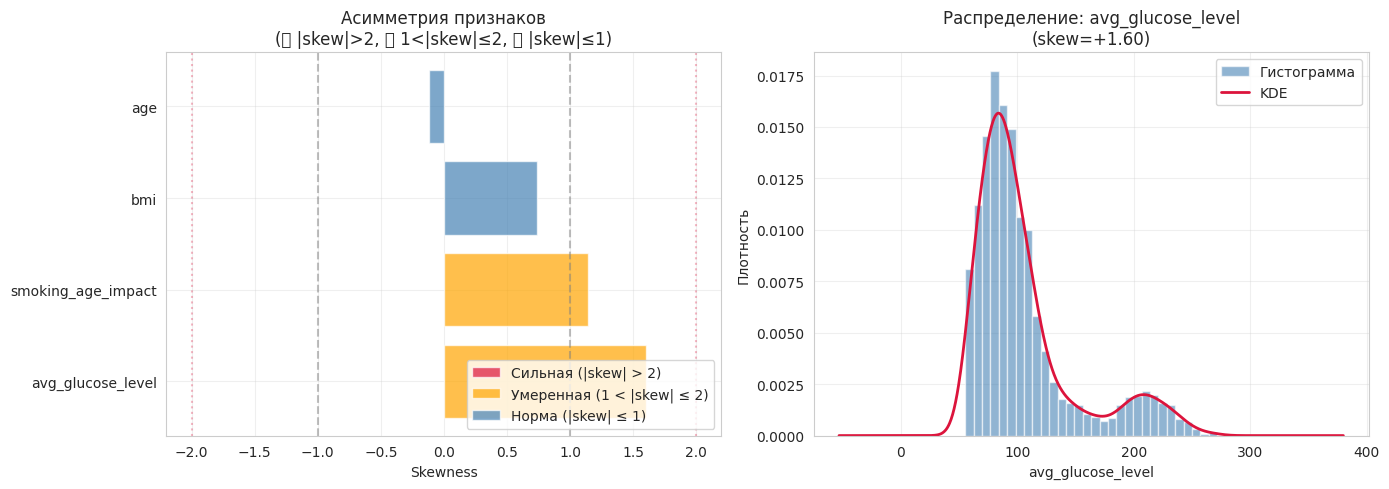


📊 СВОДНАЯ ТАБЛИЦА: ВЫБРОСЫ + SKEWNESS + РЕКОМЕНДАЦИИ
-----------------------------------------------------------------------------------------------


,Признак,Выбросов %,Skewness,Уровень,Рекомендация
0,age,0.0%,-0.1194,🟢 Норма,keep + StandardScaler
1,avg_glucose_level,11.8%,1.6049,🟡 Умеренная,cap + RobustScaler
2,bmi,2.0%,0.7421,🟢 Норма,keep + StandardScaler



📝 ПРИМЕР SCALING_CONFIG (для блока 1.2 или 1.3):
--------------------------------------------------
SCALING_CONFIG = {
    'avg_glucose_level': 'robust',
    'smoking_age_impact': 'robust',
    'bmi': 'standard',
    'age': 'standard',
}

📝 РЕКОМЕНДАЦИИ ДЛЯ outliers_strategy (блок 1.2):
------------------------------------------------------------
# На основе анализа выбросов и skewness:
outliers_strategy = {
    'age': ('keep', None),  # 0.0% выбросов
    'avg_glucose_level': ('cap', (22.8, 168.1)),  # 11.8% выбросов
    'bmi': ('keep', None),  # 2.0% выбросов
}

✓ Анализ skewness завершён (рекомендации НЕ сохранены в метаданные)



In [ ]:
# 4.3 АНАЛИЗ SKEWNESS И РЕКОМЕНДАЦИИ ПО МАСШТАБИРОВАНИЮ (ДЛЯ ОЗНАКОМЛЕНИЯ)

print("\n" + "="*50)
print("📊 АНАЛИЗ SKEWNESS (АСИММЕТРИИ) ДЛЯ ОЗНАКОМЛЕНИЯ")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    # Используем уже очищенные данные (если были обработаны ранее)
    X_for_analysis = X_train_clean if 'X_train_clean' in globals() and X_train_clean is not None else X_train

    # Определяем числовые колонки
    numeric_cols = X_for_analysis.select_dtypes(include=['int64', 'Int64', 'float64', 'int32', 'float32']).columns.tolist()
    binary_cols = [col for col in numeric_cols if X_for_analysis[col].nunique() <= 2]
    continuous_cols = [col for col in numeric_cols if X_for_analysis[col].nunique() > 2]

    print(f"\n📊 Анализируемые непрерывные признаки: {continuous_cols if continuous_cols else 'нет'}")

    if len(continuous_cols) == 0:
        print("\n⚠️ Нет непрерывных признаков для анализа skewness")
        recommendations = {}
    else:

        # 1. РАСЧЁТ SKEWNESS

        skewness = X_for_analysis[continuous_cols].skew().sort_values(ascending=False)

        print("\n📐 SKEWNESS (АСИММЕТРИЯ):")
        print("-" * 75)
        print(f"{'Признак':<25} {'Skewness':<12} {'Уровень':<15} {'Рекомендация':<25}")
        print("-" * 75)

        recommendations = {}

        for col, skew in skewness.items():
            abs_skew = abs(skew)

            if abs_skew > 2:
                level = "🔴 Сильная"
                scaler_rec = "log + RobustScaler"
            elif abs_skew > 1:
                level = "🟡 Умеренная"
                scaler_rec = "RobustScaler"
            else:
                level = "🟢 Норма"
                scaler_rec = "StandardScaler"

            print(f"{col:<25} {skew:+.2f}       {level:<15} {scaler_rec:<25}")

            recommendations[col] = {
                'skewness': round(skew, 4),
                'abs_skew': round(abs_skew, 4),
                'level': level,
                'scaler_rec': scaler_rec
            }

        print("-" * 75)


        # 2. СВОДНАЯ ТАБЛИЦА SKEWNESS

        summary_data = []
        for col, rec in recommendations.items():
            summary_data.append({
                'Признак': col,
                'Skewness': f"{rec['skewness']:+.2f}",
                'Уровень асимметрии': rec['level'],
                'Рекомендация по масштабированию': rec['scaler_rec']
            })

        print("\n📊 СВОДНАЯ ТАБЛИЦА SKEWNESS (для ознакомления):")
        display(pd.DataFrame(summary_data))


        # 3. СТАТИСТИКА

        strong = sum(1 for r in recommendations.values() if 'Сильная' in r['level'])
        moderate = sum(1 for r in recommendations.values() if 'Умеренная' in r['level'])
        normal = sum(1 for r in recommendations.values() if 'Норма' in r['level'])

        print(f"\n📈 СТАТИСТИКА АСИММЕТРИИ:")
        print(f"   🔴 Сильная (|skew| > 2):     {strong} — рекомендуется log + RobustScaler")
        print(f"   🟡 Умеренная (1 < |skew| ≤ 2): {moderate} — рекомендуется RobustScaler")
        print(f"   🟢 Норма (|skew| ≤ 1):        {normal} — рекомендуется StandardScaler")


        # 4. ВИЗУАЛИЗАЦИЯ SKEWNESS

        if len(continuous_cols) > 0:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))

            # График 1: Bar chart skewness
            colors = []
            for col in skewness.index:
                abs_skew = abs(skewness[col])
                if abs_skew > 2:
                    colors.append('crimson')
                elif abs_skew > 1:
                    colors.append('orange')
                else:
                    colors.append('steelblue')

            axes[0].barh(list(skewness.index), skewness.values, color=colors, alpha=0.7)
            axes[0].axvline(x=1, color='gray', linestyle='--', alpha=0.5)
            axes[0].axvline(x=-1, color='gray', linestyle='--', alpha=0.5)
            axes[0].axvline(x=2, color='crimson', linestyle=':', alpha=0.3)
            axes[0].axvline(x=-2, color='crimson', linestyle=':', alpha=0.3)
            axes[0].set_xlabel('Skewness')
            axes[0].set_title('Асимметрия признаков\n(🔴 |skew|>2, 🟡 1<|skew|≤2, 🔵 |skew|≤1)')
            axes[0].grid(alpha=0.3)

            # Легенда
            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor='crimson', alpha=0.7, label='Сильная (|skew| > 2)'),
                Patch(facecolor='orange', alpha=0.7, label='Умеренная (1 < |skew| ≤ 2)'),
                Patch(facecolor='steelblue', alpha=0.7, label='Норма (|skew| ≤ 1)')
            ]
            axes[0].legend(handles=legend_elements, loc='lower right')

            # График 2: Histogram + KDE для самого асимметричного признака
            if len(continuous_cols) > 0:
                most_skewed = skewness.index[0]
                axes[1].hist(X_for_analysis[most_skewed], bins=30, alpha=0.6, color='steelblue', density=True, label='Гистограмма')
                X_for_analysis[most_skewed].plot.kde(ax=axes[1], color='crimson', linewidth=2, label='KDE')
                axes[1].set_xlabel(most_skewed)
                axes[1].set_ylabel('Плотность')
                axes[1].set_title(f'Распределение: {most_skewed}\n(skew={skewness[most_skewed]:+.2f})')
                axes[1].legend()
                axes[1].grid(alpha=0.3)

            plt.tight_layout()

            skew_plot_path = os.path.join(EDA_PLOTS_PATH, 'skewness_analysis.png')
            plt.savefig(skew_plot_path, dpi=150, bbox_inches='tight')
            print(f"\n💾 График сохранён: {skew_plot_path}")
            plt.show()


    # 5. СВОДНАЯ ТАБЛИЦА: ВЫБРОСЫ + SKEWNESS + РЕКОМЕНДАЦИИ

    if 'outliers_info' in globals() and outliers_info:
        print("\n📊 СВОДНАЯ ТАБЛИЦА: ВЫБРОСЫ + SKEWNESS + РЕКОМЕНДАЦИИ")
        print("-" * 95)

        combined_data = []
        for info in outliers_info:
            col = info['Колонка']
            rec = recommendations.get(col, {})

            # Определяем итоговую рекомендацию
            pct = info['%']
            level = rec.get('level', '—')

            if pct > 10:
                if 'Сильная' in level:
                    final_rec = "log + RobustScaler"
                else:
                    final_rec = "cap + RobustScaler"
            elif pct > 5:
                if level in ['🔴 Сильная', '🟡 Умеренная']:
                    final_rec = "cap + RobustScaler"
                else:
                    final_rec = "keep + StandardScaler"
            else:
                if level in ['🔴 Сильная', '🟡 Умеренная']:
                    final_rec = "keep + RobustScaler"
                else:
                    final_rec = "keep + StandardScaler"

            combined_data.append({
                'Признак': col,
                'Выбросов %': f"{pct:.1f}%",
                'Skewness': rec.get('skewness', '—') if isinstance(rec.get('skewness'), (int, float)) else '—',
                'Уровень': level,
                'Рекомендация': final_rec
            })

        if combined_data:
            display(pd.DataFrame(combined_data))


    # 6. ПРИМЕР ДЛЯ ВСТАВКИ В БЛОК НАСТРОЕК — SCALING_CONFIG

    if recommendations:
        print("\n📝 ПРИМЕР SCALING_CONFIG (для блока 1.2 или 1.3):")
        print("-" * 50)
        print("SCALING_CONFIG = {")
        for col, rec in recommendations.items():
            if 'RobustScaler' in rec['scaler_rec']:
                print(f"    '{col}': 'robust',")
            else:
                print(f"    '{col}': 'standard',")
        print("}")


    # 7. РЕКОМЕНДАЦИИ ДЛЯ outliers_strategy

    if 'outliers_info' in globals() and outliers_info:
        print("\n📝 РЕКОМЕНДАЦИИ ДЛЯ outliers_strategy (блок 1.2):")
        print("-" * 60)
        print("# На основе анализа выбросов и skewness:")
        print("outliers_strategy = {")

        for info in outliers_info:
            col = info['Колонка']
            rec = recommendations.get(col, {})
            pct = info['%']

            if pct > 10:
                if rec.get('level', '') == '🔴 Сильная':
                    print(f"    '{col}': ('log', None),  # {pct:.1f}% выбросов, сильная асимметрия (skew={rec.get('skewness', '—')})")
                else:
                    print(f"    '{col}': ('cap', ({info['Нижняя']:.1f}, {info['Верхняя']:.1f})),  # {pct:.1f}% выбросов")
            elif pct > 5:
                print(f"    '{col}': ('cap', ({info['Нижняя']:.1f}, {info['Верхняя']:.1f})),  # {pct:.1f}% выбросов")
            else:
                print(f"    '{col}': ('keep', None),  # {pct:.1f}% выбросов")
        print("}")


    # 8. ДОПОЛНИТЕЛЬНЫЕ РЕКОМЕНДАЦИИ

    if recommendations:
        strong_cols = [col for col, rec in recommendations.items() if 'Сильная' in rec['level']]
        if strong_cols:
            print(f"\n💡 ДОПОЛНИТЕЛЬНО:")
            print(f"   Сильно асимметричные признаки: {strong_cols}")
            print(f"   Рекомендуется создать log-трансформированные версии в EDA или Modelling")

print("\n" + "="*50)
print("✓ Анализ skewness завершён (рекомендации НЕ сохранены в метаданные)")
print("="*50 + "\n")

In [ ]:
# 4.4 СТРАТЕГИЯ ОБРАБОТКИ ВЫБРОСОВ

print("\n" + "="*50)
print("📋 СТРАТЕГИЯ ОБРАБОТКИ ВЫБРОСОВ")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    if outliers_strategy:
        print("\n📊 Выбранные стратегии:\n")

        strategy_counts = {}
        valid_cols = []
        invalid_cols = []

        for col, (strategy, param) in outliers_strategy.items():
            if col in X_train.columns:
                valid_cols.append(col)
                strategy_counts[strategy] = strategy_counts.get(strategy, 0) + 1

                if param:
                    print(f"   • {col}: {strategy} (параметр: {param})")
                else:
                    print(f"   • {col}: {strategy}")
            else:
                invalid_cols.append(col)

        if invalid_cols:
            print(f"\n⚠️ Колонки не найдены в X_train: {invalid_cols}")

        # Сводка
        print(f"\n📊 Сводка по стратегиям:")
        for strategy, count in strategy_counts.items():
            if strategy == 'keep':
                desc = "оставить как есть"
            elif strategy == 'cap':
                desc = "обрезать по границам"
            elif strategy == 'remove':
                desc = "удалить строки"
            elif strategy == 'log':
                desc = "логарифмировать"
            elif strategy == 'flag':
                desc = "создать флаг"
            else:
                desc = ""
            print(f"   {strategy}: {count} колонок - {desc}")

        # Проверка: есть ли колонки с выбросами без стратегии
        if 'outliers_info' in globals() and outliers_info:
            cols_with_outliers = set([info['Колонка'] for info in outliers_info if info['Выбросов'] > 0])
            cols_with_strategy = set(valid_cols)
            missing_strategy_cols = cols_with_outliers - cols_with_strategy

            if missing_strategy_cols:
                print(f"\n⚠️ Колонки с выбросами БЕЗ стратегии:")
                for col in missing_strategy_cols:
                    info = next((x for x in outliers_info if x['Колонка'] == col), None)
                    if info:
                        print(f"   • {col}: {info['Выбросов']} выбросов ({info['%']:.1f}%)")
                print(f"\n💡 Добавьте их в outliers_strategy в блоке 1.2")

    else:
        print("\n⚠️ Словарь outliers_strategy пуст.")
        print("   Заполните его в блоке 1.2 на основе анализа:\n")

        if 'outliers_info' in globals() and outliers_info:
            print("   Найдены выбросы в колонках:")
            for info in outliers_info:
                if info['Выбросов'] > 0:
                    print(f"   • {info['Колонка']}: {info['Выбросов']} ({info['%']:.1f}%) — {info['Уровень']}")

        print(f"\n💡 Стратегии обработки:")
        print("   • keep   — оставить как есть (выбросы реальные)")
        print("   • cap    — обрезать по границам (винзоризация)")
        print("   • remove — удалить строки с выбросами")
        print("   • log    — логарифмическое преобразование (только для положительных значений)")
        print("   • flag   — создать флаг выброса")

        print(f"\n   💡 Границы для cap можно взять из анализа IQR (блок 4.2):")
        print("      нижняя = Q1 - 1.5×IQR, верхняя = Q3 + 1.5×IQR")

        print(f"\n📝 Пример заполнения:")
        print(f"   outliers_strategy = {{")
        print(f"       'avg_glucose_level': ('cap', (50, 250)),")
        print(f"       'bmi': ('log', None),")
        print(f"       'age': ('keep', None),")
        print(f"   }}")

print("\n" + "="*50)
print("✓ Анализ стратегии завершён")
print("="*50 + "\n")


📋 СТРАТЕГИЯ ОБРАБОТКИ ВЫБРОСОВ

📊 Выбранные стратегии:

   • age: keep
   • avg_glucose_level: keep
   • bmi: keep

📊 Сводка по стратегиям:
   keep: 3 колонок - оставить как есть

✓ Анализ стратегии завершён



In [ ]:
# 4.5 ПРИМЕНЕНИЕ СТРАТЕГИЙ ОБРАБОТКИ ВЫБРОСОВ

print("\n" + "="*50)
print("🔧 ПРИМЕНЕНИЕ СТРАТЕГИЙ ОБРАБОТКИ ВЫБРОСОВ")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
    X_train_clean = None
    y_train_clean = None
    outlier_flags = []
else:
    # Проверяем коэффициент IQR
    if 'OUTLIER_IQR_COEFF' not in globals():
        OUTLIER_IQR_COEFF = 1.5
        print(f"\nℹ️ OUTLIER_IQR_COEFF не задан, используется: {OUTLIER_IQR_COEFF}")

    # ============================================
    # ВРЕМЕННЫЕ КОПИИ ДЛЯ ОБРАБОТКИ ВЫБРОСОВ
    # ============================================
    X_train_outliers = X_train_clean.copy()
    y_train_outliers = y_train.copy() if y_train is not None else None
    X_val_outliers = X_val_clean.copy() if X_val_clean is not None else None
    X_test_outliers = X_test_clean.copy() if X_test_clean is not None else None

    outlier_flags = []
    cap_values = {}         # col -> (lower, upper) для обрезания
    log_columns = []        # колонки для логарифмирования
    remove_masks = {}       # col -> границы для удаления
    outlier_boundaries = {} # col -> (lower, upper) для флагов (из Train)

    # ============================================
    # ШАГ 1: Анализ стратегий и вычисление параметров на TRAIN
    # ============================================
    if outliers_strategy:
        print("\n📌 Анализ стратегий на Train:\n")

        for col, (strategy, param) in outliers_strategy.items():
            if col not in X_train_outliers.columns:
                print(f"   ⚠️ Колонка '{col}' не найдена, пропускаем")
                continue

            print(f"   📍 {col}: {strategy}", end="")

            # Вычисляем IQR-границы (сохраняем для всех стратегий)
            Q1 = X_train_outliers[col].quantile(0.25)
            Q3 = X_train_outliers[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - OUTLIER_IQR_COEFF * IQR
            upper_bound = Q3 + OUTLIER_IQR_COEFF * IQR

            # Сохраняем границы для флагов и удаления
            outlier_boundaries[col] = (lower_bound, upper_bound)

            if strategy == 'keep':
                print(" → оставлено без изменений")

            elif strategy == 'cap':
                if param and isinstance(param, (tuple, list)) and len(param) == 2:
                    cap_lower, cap_upper = param
                else:
                    cap_lower, cap_upper = lower_bound, upper_bound
                cap_values[col] = (cap_lower, cap_upper)
                print(f" → обрезание [{cap_lower:.2f}, {cap_upper:.2f}]")

            elif strategy == 'remove':
                remove_masks[col] = (lower_bound, upper_bound)
                outlier_mask = (X_train_outliers[col] < lower_bound) | (X_train_outliers[col] > upper_bound)
                outlier_count = outlier_mask.sum()
                print(f" → удаление строк с выбросами ({outlier_count} шт.)")

            elif strategy == 'log':
                log_columns.append(col)
                if (X_train_outliers[col] <= 0).any():
                    print(" → log1p (x+1)")
                else:
                    print(" → log")

            elif strategy == 'flag':
                flag_col = f'{col}_outlier_flag'
                outlier_flags.append(flag_col)
                print(f" → флаг {flag_col}")

            else:
                print(f" → ⚠️ неизвестная стратегия '{strategy}'")

    # ============================================
    # ШАГ 2: Функция применения стратегий (ПРАВИЛЬНЫЙ ПОРЯДОК)
    # ============================================
    def apply_outlier_strategies(df, df_name, cap_values, log_columns, outlier_flags, outlier_boundaries, remove_masks):
        """
        Применяет стратегии обработки выбросов к датафрейму
        Правильный порядок: Cap → Флаги → Удаление → Логарифмирование
        """
        if df is None:
            return df, None

        df = df.copy()
        rows_to_remove = []

        # ============================================
        # ШАГ 1: Cap (обрезание) на исходных данных
        # ============================================
        for col, (cap_lower, cap_upper) in cap_values.items():
            if col in df.columns:
                df[col] = df[col].clip(cap_lower, cap_upper)

        # ============================================
        # ШАГ 2: Создание флагов по границам из Train
        # ============================================
        for flag_col in outlier_flags:
            base_col = flag_col.replace('_outlier_flag', '')
            if base_col in df.columns and base_col in outlier_boundaries:
                lower_bound, upper_bound = outlier_boundaries[base_col]
                df[flag_col] = ((df[base_col] < lower_bound) | (df[base_col] > upper_bound)).astype(int)

        # ============================================
        # ШАГ 3: Пометка строк к удалению — по границам из Train
        # ============================================
        for col, (lower_bound, upper_bound) in remove_masks.items():
            if col in df.columns:
                outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
                outlier_indices = df.index[outlier_mask].tolist()
                rows_to_remove.extend(outlier_indices)

        # ============================================
        # ШАГ 4: Удаление строк
        # ============================================
        if rows_to_remove:
            rows_to_remove = list(set(rows_to_remove))
            df = df.drop(index=rows_to_remove)
            df.reset_index(drop=True, inplace=True)

        # ============================================
        # ШАГ 5: Логарифмирование — САМЫМ ПОСЛЕДНИМ!
        # ============================================
        for col in log_columns:
            if col in df.columns:
                if (df[col] <= 0).any():
                    df[col] = np.log1p(df[col])
                else:
                    df[col] = np.log(df[col])

        return df, len(rows_to_remove) if rows_to_remove else 0

    # ============================================
    # ШАГ 3: Применение ко всем выборкам (используем *_outliers)
    # ============================================
    print("\n🔧 Применение стратегий ко всем выборкам:")

    # Train
    X_train_outliers, train_removed = apply_outlier_strategies(
        X_train_outliers, "Train", cap_values, log_columns, outlier_flags, outlier_boundaries, remove_masks
    )
    print(f"   ✓ Train обработан: {X_train_outliers.shape}")
    if train_removed > 0:
        print(f"      Удалено строк: {train_removed}")

    # Синхронное удаление из y_train
    if y_train_outliers is not None and train_removed > 0:
        y_temp, _ = apply_outlier_strategies(
            pd.DataFrame({'y': y_train_outliers}), "y_train", {}, [], {}, outlier_boundaries, remove_masks
        )
        if y_temp is not None:
            y_train_outliers = y_temp['y']
            print(f"   ✓ y_train синхронизирован: {len(y_train_outliers)} строк")

    # ============================================
    # Val с корректной синхронизацией y_val
    # ============================================
    if X_val_outliers is not None:
        # Сохраняем маску удаления ДО применения трансформаций
        removal_mask_val = pd.Series(False, index=X_val_outliers.index)
        for col, (lower_bound, upper_bound) in remove_masks.items():
            if col in X_val_outliers.columns:
                removal_mask_val = removal_mask_val | (X_val_outliers[col] < lower_bound) | (X_val_outliers[col] > upper_bound)

        X_val_outliers, val_removed = apply_outlier_strategies(
            X_val_outliers, "Val", cap_values, log_columns, outlier_flags, outlier_boundaries, remove_masks
        )
        print(f"   ✓ Val обработан: {X_val_outliers.shape}")
        if val_removed > 0:
            print(f"      Удалено строк: {val_removed}")

            # Синхронизация y_val по той же маске
            if y_val is not None:
                # Применяем ту же маску удаления к y_val
                y_val = y_val[~removal_mask_val].reset_index(drop=True)
                print(f"      ✓ y_val синхронизирован: {len(y_val)} строк")

    # ============================================
    # Test с корректной синхронизацией y_test
    # ============================================
    if X_test_outliers is not None:
        # Сохраняем маску удаления ДО применения трансформаций
        removal_mask_test = pd.Series(False, index=X_test_outliers.index)
        for col, (lower_bound, upper_bound) in remove_masks.items():
            if col in X_test_outliers.columns:
                removal_mask_test = removal_mask_test | (X_test_outliers[col] < lower_bound) | (X_test_outliers[col] > upper_bound)

        X_test_outliers, test_removed = apply_outlier_strategies(
            X_test_outliers, "Test", cap_values, log_columns, outlier_flags, outlier_boundaries, remove_masks
        )
        print(f"   ✓ Test обработан: {X_test_outliers.shape}")
        if test_removed > 0:
            print(f"      Удалено строк: {test_removed}")

            # Синхронизация y_test по той же маске
            if y_test is not None:
                y_test = y_test[~removal_mask_test].reset_index(drop=True)
                print(f"      ✓ y_test синхронизирован: {len(y_test)} строк")

    # ============================================
    # ПЕРЕИМЕНОВЫВАЕМ ОБРАТНО для совместимости с блоками 5-9
    # ============================================
    X_train_clean = X_train_outliers
    y_train_clean = y_train_outliers
    X_val_clean = X_val_outliers
    X_test_clean = X_test_outliers

    # ============================================
    # ШАГ 4: Сохранение outlier_flags
    # ============================================
    if outlier_flags:
        outlier_flags_path = os.path.join(EDA_TRANSFORMERS_PATH, 'outlier_flags.pkl')
        joblib.dump(outlier_flags, outlier_flags_path)
        print(f"\n💾 Сохранены outlier_flags: transformers/outlier_flags.pkl")

    # ============================================
    # ШАГ 5: Итоги
    # ============================================
    print(f"\n✅ Обработка выбросов завершена")

    if cap_values:
        print(f"   📊 Обрезаны колонки: {list(cap_values.keys())}")
    if log_columns:
        print(f"   📐 Логарифмированы: {log_columns}")
    if outlier_flags:
        print(f"   🚩 Созданы флаги: {outlier_flags}")
    if remove_masks:
        print(f"   🗑️ Удалены выбросы в: {list(remove_masks.keys())}")

print("\n" + "="*50)
print("✓ Применение стратегий завершено")
print("="*50 + "\n")


🔧 ПРИМЕНЕНИЕ СТРАТЕГИЙ ОБРАБОТКИ ВЫБРОСОВ

📌 Анализ стратегий на Train:

   📍 age: keep → оставлено без изменений
   📍 avg_glucose_level: keep → оставлено без изменений
   📍 bmi: keep → оставлено без изменений

🔧 Применение стратегий ко всем выборкам:
   ✓ Train обработан: (3031, 16)
   ✓ Val обработан: (1011, 16)
   ✓ Test обработан: (1011, 16)

✅ Обработка выбросов завершена

✓ Применение стратегий завершено



In [ ]:
# 4.6 ПРОВЕРКА РЕЗУЛЬТАТА ОБРАБОТКИ ВЫБРОСОВ

print("\n" + "="*50)
print("✅ ПРОВЕРКА РЕЗУЛЬТАТА ОБРАБОТКИ ВЫБРОСОВ")
print("="*50)

if 'X_train_clean' not in globals() or X_train_clean is None:
    print("\n⚠️ X_train_clean не найден. Выполните блок 4.4.")
else:
    # Проверяем коэффициент IQR
    if 'OUTLIER_IQR_COEFF' not in globals():
        OUTLIER_IQR_COEFF = 1.5

    # ============================================
    # Сравнение Train с оригиналом
    # ============================================
    print(f"\n📊 Сравнение Train с оригиналом:")
    print(f"   До:  {X_train.shape[0]} строк, {X_train.shape[1]} колонок")
    print(f"   После: {X_train_clean.shape[0]} строк, {X_train_clean.shape[1]} колонок")

    if X_train.shape[0] != X_train_clean.shape[0]:
        removed_rows = X_train.shape[0] - X_train_clean.shape[0]
        print(f"   🗑️ Удалено строк: {removed_rows} ({removed_rows/X_train.shape[0]*100:.1f}%)")

    if X_train.shape[1] != X_train_clean.shape[1]:
        added_cols = set(X_train_clean.columns) - set(X_train.columns)
        if added_cols:
            print(f"   🚩 Добавлены флаги: {list(added_cols)}")

    # Проверка синхронизации с y_train
    if 'y_train_clean' in globals() and y_train_clean is not None:
        if len(X_train_clean) == len(y_train_clean):
            print(f"   ✓ y_train синхронизирован ({len(y_train_clean)} значений)")
        else:
            print(f"   ⚠️ X_train и y_train не совпадают! {len(X_train_clean)} vs {len(y_train_clean)}")

    # ============================================
    # Проверка синхронизации y_val
    # ============================================
    if 'y_val' in globals() and y_val is not None and 'X_val_clean' in globals() and X_val_clean is not None:
        if len(X_val_clean) == len(y_val):
            print(f"   ✓ y_val синхронизирован ({len(y_val)} значений)")
        else:
            print(f"   ⚠️ X_val_clean и y_val не совпадают! {len(X_val_clean)} vs {len(y_val)}")

    # ============================================
    # Проверка синхронизации y_test
    # ============================================
    if 'y_test' in globals() and y_test is not None and 'X_test_clean' in globals() and X_test_clean is not None:
        if len(X_test_clean) == len(y_test):
            print(f"   ✓ y_test синхронизирован ({len(y_test)} значений)")
        else:
            print(f"   ⚠️ X_test_clean и y_test не совпадают! {len(X_test_clean)} vs {len(y_test)}")

    # ============================================
    # Проверка Val
    # ============================================
    if 'X_val_clean' in globals() and X_val_clean is not None:
        print(f"\n📊 Val:")
        print(f"   До:  {X_val.shape[0]} строк, {X_val.shape[1]} колонок")
        print(f"   После: {X_val_clean.shape[0]} строк, {X_val_clean.shape[1]} колонок")

        if X_val.shape[0] != X_val_clean.shape[0]:
            removed = X_val.shape[0] - X_val_clean.shape[0]
            print(f"   🗑️ Удалено строк: {removed} ({removed/X_val.shape[0]*100:.1f}%)")

        # Проверка консистентности колонок с Train
        train_cols = set(X_train_clean.columns)
        val_cols = set(X_val_clean.columns)
        if train_cols != val_cols:
            diff = train_cols.symmetric_difference(val_cols)
            print(f"   ⚠️ Колонки Val отличаются от Train: {diff}")
        else:
            print(f"   ✓ Колонки совпадают с Train")
    else:
        print(f"\nℹ️ Val не обработан или не загружен")

    # ============================================
    # Проверка Test
    # ============================================
    if 'X_test_clean' in globals() and X_test_clean is not None:
        print(f"\n📊 Test:")
        print(f"   До:  {X_test.shape[0]} строк, {X_test.shape[1]} колонок")
        print(f"   После: {X_test_clean.shape[0]} строк, {X_test_clean.shape[1]} колонок")

        if X_test.shape[0] != X_test_clean.shape[0]:
            removed = X_test.shape[0] - X_test_clean.shape[0]
            print(f"   🗑️ Удалено строк: {removed} ({removed/X_test.shape[0]*100:.1f}%)")

        # Проверка консистентности колонок с Train
        train_cols = set(X_train_clean.columns)
        test_cols = set(X_test_clean.columns)
        if train_cols != test_cols:
            diff = train_cols.symmetric_difference(test_cols)
            print(f"   ⚠️ Колонки Test отличаются от Train: {diff}")
        else:
            print(f"   ✓ Колонки совпадают с Train")
    else:
        print(f"ℹ️ Test не обработан или не загружен")

    # ============================================
    # Проверка оставшихся выбросов в Train
    # ============================================
    print(f"\n🔍 Проверка оставшихся выбросов в Train:")
    print(f"   Коэффициент IQR: {OUTLIER_IQR_COEFF}")

    numeric_cols = X_train_clean.select_dtypes(include=['int64', 'Int64', 'float64', 'int32', 'float32']).columns.tolist()
    continuous_cols = [col for col in numeric_cols if X_train_clean[col].nunique() > 2]

    if continuous_cols:
        remaining_outliers = []

        for col in continuous_cols:
            Q1 = X_train_clean[col].quantile(0.25)
            Q3 = X_train_clean[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - OUTLIER_IQR_COEFF * IQR
            upper_bound = Q3 + OUTLIER_IQR_COEFF * IQR

            outliers_lower = (X_train_clean[col] < lower_bound).sum()
            outliers_upper = (X_train_clean[col] > upper_bound).sum()
            total = outliers_lower + outliers_upper

            if total > 0:
                remaining_outliers.append((col, total))

        if remaining_outliers:
            print(f"\n   ⚠️ Остались выбросы:")
            for col, count in remaining_outliers:
                pct = count / len(X_train_clean) * 100
                print(f"      • {col}: {count} ({pct:.1f}%)")
            print(f"\n   💡 Эти колонки имеют стратегию 'keep' или не указаны в outliers_strategy")
        else:
            print(f"\n   ✅ Выбросов не осталось (в обработанных колонках)")
    else:
        print(f"\n   ℹ️ Нет непрерывных колонок для проверки")

    # ============================================
    # Информация о флагах
    # ============================================
    if 'outlier_flags' in globals() and outlier_flags:
        print(f"\n🚩 Созданные флаги выбросов:")
        for flag in outlier_flags:
            if flag in X_train_clean.columns:
                ones = X_train_clean[flag].sum()
                pct = ones / len(X_train_clean) * 100
                print(f"   • {flag}: {ones} единиц ({pct:.1f}%)")

    # ============================================
    # Информация о логарифмированных колонках
    # ============================================
    if 'log_columns' in globals() and log_columns:
        print(f"\n📐 Логарифмированные колонки: {log_columns}")

print("\n" + "="*50)
print("✓ Проверка завершена")
print("="*50 + "\n")


✅ ПРОВЕРКА РЕЗУЛЬТАТА ОБРАБОТКИ ВЫБРОСОВ

📊 Сравнение Train с оригиналом:
   До:  3031 строк, 10 колонок
   После: 3031 строк, 16 колонок
   🚩 Добавлены флаги: ['stable_old_age', 'bmi_missing_flag', 'smoking_age_impact', 'is_smoker', 'glucose_high_risk', 'cardio_risk']
   ✓ y_train синхронизирован (3031 значений)
   ✓ y_val синхронизирован (1011 значений)
   ✓ y_test синхронизирован (1011 значений)

📊 Val:
   До:  1011 строк, 10 колонок
   После: 1011 строк, 16 колонок
   ✓ Колонки совпадают с Train

📊 Test:
   До:  1011 строк, 10 колонок
   После: 1011 строк, 16 колонок
   ✓ Колонки совпадают с Train

🔍 Проверка оставшихся выбросов в Train:
   Коэффициент IQR: 1.5

   ⚠️ Остались выбросы:
      • avg_glucose_level: 359 (11.8%)
      • bmi: 64 (2.1%)

   💡 Эти колонки имеют стратегию 'keep' или не указаны в outliers_strategy

✓ Проверка завершена



# БЛОК 5. Feature Engineering

In [ ]:
# 5.1 УДАЛЕНИЕ ПРИЗНАКОВ ПОСЛЕ FEATURE ENGINEERING

print("\n" + "="*50)
print("🗑️ УДАЛЕНИЕ ПРИЗНАКОВ ПОСЛЕ FEATURE ENGINEERING")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    if columns_to_drop_fe:
        # Проверяем существование колонок в Train
        existing_in_train = [col for col in columns_to_drop_fe if col in X_train.columns]
        missing_in_train = [col for col in columns_to_drop_fe if col not in X_train.columns]

        print(f"\n📋 Колонки к удалению: {len(columns_to_drop_fe)}")

        if missing_in_train:
            print(f"\n⚠️ Не найдены в Train ({len(missing_in_train)}):")
            for col in missing_in_train[:10]:
                print(f"   • {col}")
            if len(missing_in_train) > 10:
                print(f"   ... и ещё {len(missing_in_train) - 10}")

        # ============================================
        # Удаление из Train
        # ============================================
        if existing_in_train:
            X_train.drop(columns=existing_in_train, inplace=True)
            print(f"\n✓ Train: удалено {len(existing_in_train)} колонок")
            print(f"   Новая форма: {X_train.shape}")
        else:
            print("\n⚠️ Train: нет колонок для удаления")

        # ============================================
        # Удаление из Val
        # ============================================
        if X_val is not None:
            existing_in_val = [col for col in columns_to_drop_fe if col in X_val.columns]
            if existing_in_val:
                X_val.drop(columns=existing_in_val, inplace=True)
                print(f"✓ Val: удалено {len(existing_in_val)} колонок")
                print(f"   Новая форма: {X_val.shape}")
            else:
                print("ℹ️ Val: нет колонок для удаления")
        else:
            print("ℹ️ Val не загружен")

        # ============================================
        # Удаление из Test
        # ============================================
        if X_test is not None:
            existing_in_test = [col for col in columns_to_drop_fe if col in X_test.columns]
            if existing_in_test:
                X_test.drop(columns=existing_in_test, inplace=True)
                print(f"✓ Test: удалено {len(existing_in_test)} колонок")
                print(f"   Новая форма: {X_test.shape}")
            else:
                print("ℹ️ Test: нет колонок для удаления")
        else:
            print("ℹ️ Test не загружен")

        # ============================================
        # Удаление из CLEAN-версий (X_train_clean, X_val_clean, X_test_clean)
        # ============================================
        print("\n🧹 Удаление из CLEAN-версий:")

        # X_train_clean
        if 'X_train_clean' in globals() and X_train_clean is not None:
            existing_in_train_clean = [col for col in columns_to_drop_fe if col in X_train_clean.columns]
            if existing_in_train_clean:
                X_train_clean.drop(columns=existing_in_train_clean, inplace=True)
                print(f"   ✓ X_train_clean: удалено {len(existing_in_train_clean)} колонок")
            else:
                print(f"   ℹ️ X_train_clean: нет колонок для удаления")
        else:
            print(f"   ℹ️ X_train_clean не существует")

        # X_val_clean
        if 'X_val_clean' in globals() and X_val_clean is not None:
            existing_in_val_clean = [col for col in columns_to_drop_fe if col in X_val_clean.columns]
            if existing_in_val_clean:
                X_val_clean.drop(columns=existing_in_val_clean, inplace=True)
                print(f"   ✓ X_val_clean: удалено {len(existing_in_val_clean)} колонок")
            else:
                print(f"   ℹ️ X_val_clean: нет колонок для удаления")
        else:
            print(f"   ℹ️ X_val_clean не существует")

        # X_test_clean
        if 'X_test_clean' in globals() and X_test_clean is not None:
            existing_in_test_clean = [col for col in columns_to_drop_fe if col in X_test_clean.columns]
            if existing_in_test_clean:
                X_test_clean.drop(columns=existing_in_test_clean, inplace=True)
                print(f"   ✓ X_test_clean: удалено {len(existing_in_test_clean)} колонок")
            else:
                print(f"   ℹ️ X_test_clean: нет колонок для удаления")
        else:
            print(f"   ℹ️ X_test_clean не существует")

        # ============================================
        # Проверка консистентности колонок
        # ============================================
        print(f"\n📊 Проверка консистентности:")
        train_cols = set(X_train.columns)

        if X_val is not None:
            val_cols = set(X_val.columns)
            if train_cols != val_cols:
                diff = train_cols.symmetric_difference(val_cols)
                print(f"   ⚠️ Train и Val различаются: {diff}")
            else:
                print(f"   ✓ Train и Val: колонки совпадают ({len(train_cols)})")

        if X_test is not None:
            test_cols = set(X_test.columns)
            if train_cols != test_cols:
                diff = train_cols.symmetric_difference(test_cols)
                print(f"   ⚠️ Train и Test различаются: {diff}")
            else:
                print(f"   ✓ Train и Test: колонки совпадают ({len(train_cols)})")

        # Проверка консистентности clean-версий
        if 'X_train_clean' in globals() and X_train_clean is not None and \
           'X_val_clean' in globals() and X_val_clean is not None:
            train_clean_cols = set(X_train_clean.columns)
            val_clean_cols = set(X_val_clean.columns)
            if train_clean_cols != val_clean_cols:
                diff = train_clean_cols.symmetric_difference(val_clean_cols)
                print(f"   ⚠️ Train_clean и Val_clean различаются: {diff}")

    # Итоговый список признаков
    print(f"\n📋 Текущие признаки X_train ({len(X_train.columns)}):")
    print(f"   {X_train.columns.tolist()}")

print("\n" + "="*50)
print("✓ Удаление признаков завершено")
print("="*50 + "\n")


🗑️ УДАЛЕНИЕ ПРИЗНАКОВ ПОСЛЕ FEATURE ENGINEERING

📋 Колонки к удалению: 9

⚠️ Не найдены в Train (2):
   • glucose_high_risk
   • is_smoker

✓ Train: удалено 7 колонок
   Новая форма: (3031, 3)
✓ Val: удалено 7 колонок
   Новая форма: (1011, 3)
✓ Test: удалено 7 колонок
   Новая форма: (1011, 3)

🧹 Удаление из CLEAN-версий:
   ✓ X_train_clean: удалено 9 колонок
   ✓ X_val_clean: удалено 9 колонок
   ✓ X_test_clean: удалено 9 колонок

📊 Проверка консистентности:
   ✓ Train и Val: колонки совпадают (3)
   ✓ Train и Test: колонки совпадают (3)

📋 Текущие признаки X_train (3):
   ['age', 'work_type', 'avg_glucose_level']

✓ Удаление признаков завершено



In [ ]:
# 5.2 СВОДНЫЙ АНАЛИЗ НОВЫХ ПРИЗНАКОВ

print("\n" + "="*50)
print("📊 СВОДНЫЙ АНАЛИЗ НОВЫХ ПРИЗНАКОВ")
print("="*50)

if X_train is None or y_train is None:
    print("\n⚠️ Данные не загружены. Пропускаем.")
else:
    # Защита от None в TARGET_COLUMN
    target_display = TARGET_COLUMN if TARGET_COLUMN else 'target'

    # Используем список из настроек
    if 'NEW_FEATURES' in globals() and NEW_FEATURES:
        new_features = NEW_FEATURES
    else:
        new_features = []
        print("\n⚠️ NEW_FEATURES не определён или пуст")

    # Проверяем, какие из них реально существуют
    existing_features = [f for f in new_features if f in X_train.columns]
    missing_features = [f for f in new_features if f not in X_train.columns]

    if missing_features:
        print(f"\n⚠️ Указаны, но не найдены: {missing_features}")

    if not existing_features:
        print("\n⚠️ Нет новых признаков для анализа.")
        print("   Заполните NEW_FEATURES в блоке 1.2")
    else:
        print(f"\n📋 Анализируемые признаки ({len(existing_features)}):")
        print(f"   {existing_features}")

        # Сравнительная таблица
        print("\n" + "-"*60)
        print("📊 СРАВНИТЕЛЬНАЯ ТАБЛИЦА НОВЫХ ПРИЗНАКОВ")
        print("-"*60)

        comparison_data = []

        for col in existing_features:
            # Тип признака
            if X_train[col].dtype in ['int64', 'Int64', 'float64', 'int32', 'float32']:
                col_type = 'Числовой'
                unique_count = X_train[col].nunique()

                if unique_count <= 2:
                    risk_pct = X_train[col].mean() * 100
                    stats = f"доля 1: {risk_pct:.1f}%"
                else:
                    stats = f"[{X_train[col].min():.2f}, {X_train[col].max():.2f}]"
            else:
                col_type = 'Категориальный'
                unique_count = X_train[col].nunique()
                stats = f"категорий: {unique_count}"

            # Корреляция с целевой
            if TASK_TYPE == 'classification':
                if X_train[col].dtype in ['int64', 'Int64', 'float64']:
                    corr = X_train[col].corr(y_train)
                else:
                    le = LabelEncoder()
                    encoded = le.fit_transform(X_train[col].astype(str))
                    corr = pd.Series(encoded).corr(y_train)

                # Цветовая индикация
                if abs(corr) > 0.3:
                    corr_str = f"🟢 {corr:.3f}"
                elif abs(corr) > 0.15:
                    corr_str = f"🟡 {corr:.3f}"
                else:
                    corr_str = f"🔴 {corr:.3f}"
            else:
                corr_str = "-"

            comparison_data.append({
                'Признак': col,
                'Тип': col_type,
                'Уник': unique_count,
                'Статистика': stats,
                f'Корр с {target_display}': corr_str
            })

        comparison_df = pd.DataFrame(comparison_data)
        display(comparison_df)

        # Детальный анализ
        print("\n" + "="*50)
        print("🔍 ДЕТАЛЬНЫЙ АНАЛИЗ")
        print("="*50)

        for col in existing_features:
            print(f"\n{'─'*40}")
            print(f"📌 {col}")
            print('─'*40)

            if X_train[col].dtype in ['int64', 'Int64', 'float64', 'int32', 'float32']:
                print(f"   Тип: числовой")
                print(f"   Уникальных: {X_train[col].nunique()}")
                print(f"   Среднее: {X_train[col].mean():.3f}")
                print(f"   Медиана: {X_train[col].median():.3f}")
                print(f"   Пропусков: {X_train[col].isnull().sum()}")

                if X_train[col].nunique() <= 2:
                    print(f"\n   📊 Связь с {target_display}:")
                    cross = pd.crosstab(X_train[col], y_train, normalize='index') * 100
                    for idx in cross.index:
                        val_name = "Да" if idx == 1 else ("Нет" if idx == 0 else str(idx))
                        if 1 in cross.columns:
                            target_pct = cross.loc[idx, 1]
                            print(f"      {val_name}: {target_pct:.1f}% класса 1")
            else:
                print(f"   Тип: категориальный")
                print(f"   Уникальных: {X_train[col].nunique()}")
                print(f"   Пропусков: {X_train[col].isnull().sum()}")

                print(f"\n   📊 Связь с {target_display} (%):")
                cross = pd.crosstab(X_train[col], y_train, normalize='index') * 100
                display(cross.round(1))

        # Сила связи
        if TASK_TYPE == 'classification':
            print("\n💡 Сила связи:")
            print("   🟢 |r| > 0.3 — сильная связь (важный признак)")
            print("   🟡 |r| > 0.15 — умеренная связь")
            print("   🔴 |r| ≤ 0.15 — слабая связь (кандидат на удаление)")

print("\n" + "="*50)
print("✓ Анализ новых признаков завершён")
print("="*50 + "\n")


📊 СВОДНЫЙ АНАЛИЗ НОВЫХ ПРИЗНАКОВ

⚠️ Указаны, но не найдены: ['cardio_risk', 'stable_old_age', 'glucose_high_risk', 'smoking_age_impact', 'is_smoker']

⚠️ Нет новых признаков для анализа.
   Заполните NEW_FEATURES в блоке 1.2

✓ Анализ новых признаков завершён



# БЛОК 6. category info

# Viz categorical_cols

In [ ]:
# 6.1 АНАЛИЗ КАТЕГОРИАЛЬНЫХ КОЛОНОК ПЕРЕД КОДИРОВАНИЕМ

print("\n" + "="*50)
print("🏷️ АНАЛИЗ КАТЕГОРИАЛЬНЫХ КОЛОНОК")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    # Определяем категориальные колонки (bool отдельно)
    categorical_cols = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    bool_cols = X_train.select_dtypes(include=['bool']).columns.tolist()

    if len(categorical_cols) == 0 and len(bool_cols) == 0:
        print("\n⚠️ Нет категориальных или boolean колонок для анализа")
    else:
        # ============================================
        # КАТЕГОРИАЛЬНЫЕ КОЛОНКИ
        # ============================================
        if categorical_cols:
            print(f"\n📋 Категориальные колонки ({len(categorical_cols)}):")
            print(f"   {categorical_cols}")

            categorical_info = []

            for col in categorical_cols:
                unique_count = X_train[col].nunique()
                top_values = X_train[col].value_counts().head(3)

                # Показываем все значения для бинарных
                if unique_count == 2:
                    all_values = X_train[col].unique().tolist()
                    values_str = f"{all_values[0]} / {all_values[1]}"
                else:
                    values_str = None

                # Редкие категории (<1%)
                value_counts = X_train[col].value_counts()
                rare_threshold = max(len(X_train) * 0.01, 1)
                rare_categories = value_counts[value_counts < rare_threshold]

                # Определяем рекомендуемый метод кодирования
                if unique_count == 2:
                    method = "🔵 Ручной маппинг / 🟢 LabelEncoder"
                elif unique_count <= 10:
                    method = "🟢 OneHotEncoder"
                elif unique_count <= 50:
                    method = "🟡 TargetEncoder"
                else:
                    method = "🔴 TargetEncoder / FeatureHasher"

                categorical_info.append({
                    'Колонка': col,
                    'Уник': unique_count,
                    'Значения': values_str if values_str else '-',
                    'Топ-1': f"{top_values.index[0]}" if len(top_values) > 0 else '-',
                    'Топ-1 %': f"{(top_values.iloc[0]/len(X_train)*100):.1f}%" if len(top_values) > 0 else '-',
                    'Редких': len(rare_categories),
                    'Метод': method
                })

                print(f"\n🏷️ {col}:")
                print(f"   Уникальных: {unique_count}")

                if unique_count == 2:
                    print(f"   Значения: {all_values[0]} / {all_values[1]}")

                print(f"   Топ-3 значений:")
                for val, cnt in top_values.items():
                    pct = cnt / len(X_train) * 100
                    val_str = str(val)[:20] + ('...' if len(str(val)) > 20 else '')
                    print(f"      {val_str}: {cnt:>6} ({pct:>5.1f}%)")

                if len(rare_categories) > 0:
                    print(f"   ⚠️ Редких категорий (<1%): {len(rare_categories)}")
                    rare_examples = list(rare_categories.head(3).index)
                    print(f"      Примеры: {rare_examples}")

            # Сводная таблица
            print("\n" + "-"*60)
            print("📊 СВОДНАЯ ТАБЛИЦА:")
            print("-"*60)
            categorical_df = pd.DataFrame(categorical_info)
            display(categorical_df)

            # Рекомендации по кодированию
            print("\n💡 РЕКОМЕНДАЦИИ ПО КОДИРОВАНИЮ:")
            print("-"*60)
            print("   🔵 Ручной маппинг - для бинарных, где важна интерпретация")
            print("      BINARY_MAPPING = {'колонка': {'значение1': 1, 'значение2': 0}}")
            print("   🟢 LabelEncoder - для бинарных (автоматически 0/1 по алфавиту)")
            print("   🟢 OneHotEncoder - для низкокардинальных (≤10), drop='first'")
            print("   🟡 TargetEncoder - для среднекардинальных (11-50)")
            print("   🔴 TargetEncoder/FeatureHasher - для высококардинальных (>50)")

            print("\n📝 Пример для encoding_config (блок 1.2):")
            print("   encoding_config = {")

            # Примеры для первых 3 колонок
            for info in categorical_info[:3]:
                col = info['Колонка']
                unique = info['Уник']
                if unique == 2:
                    # Пытаемся предложить осмысленный маппинг
                    if 'yes' in str(X_train[col].unique()).lower():
                        print(f"       '{col}': ('binary_map', {{'yes': 1, 'no': 0}}),")
                    elif 'true' in str(X_train[col].unique()).lower():
                        print(f"       '{col}': ('binary_map', {{'True': 1, 'False': 0}}),")
                    elif 'male' in str(X_train[col].unique()).lower():
                        print(f"       '{col}': ('binary_map', {{'Male': 1, 'Female': 0}}),")
                    else:
                        vals = X_train[col].unique().tolist()
                        print(f"       '{col}': ('binary_map', {{'{vals[0]}': 1, '{vals[1]}': 0}}),  # или ('label', None)")
                elif unique <= 10:
                    print(f"       '{col}': ('one_hot', None),")
                else:
                    print(f"       '{col}': ('target', None),")
            print("   }")

            # Предупреждение о редких категориях
            cols_with_rare = [info['Колонка'] for info in categorical_info if info['Редких'] > 0]
            if cols_with_rare:
                print(f"\n⚠️ Колонки с редкими категориями: {cols_with_rare}")
                print("   💡 Рассмотрите объединение редких категорий в 'other' перед кодированием")

            # Информация о бинарных колонках
            binary_cols = [info['Колонка'] for info in categorical_info if info['Уник'] == 2]
            if binary_cols:
                print(f"\n🔵 Бинарные колонки (кандидаты на ручной маппинг): {binary_cols}")
                print("   Рекомендуется задать BINARY_MAPPING в блоке 1.2 для интерпретируемости")

        # ============================================
        # BOOLEAN КОЛОНКИ (0/1)
        # ============================================
        if bool_cols:
            print(f"\n🔘 BOOLEAN КОЛОНКИ (0/1): {bool_cols}")
            print(f"   Boolean колонки можно оставить как есть, не кодируя как категории")

            for col in bool_cols:
                value_counts = X_train[col].value_counts()
                total = len(X_train[col])
                print(f"\n   {col}:")
                for val, count in value_counts.items():
                    pct = count / total * 100
                    print(f"      {val}: {count:>6} ({pct:>5.1f}%)")

print("\n" + "="*50)
print("✓ Анализ категориальных колонок завершён")
print("="*50 + "\n")


🏷️ АНАЛИЗ КАТЕГОРИАЛЬНЫХ КОЛОНОК

📋 Категориальные колонки (1):
   ['work_type']

🏷️ work_type:
   Уникальных: 5
   Топ-3 значений:
      private:   1733 ( 57.2%)
      self-employed:    506 ( 16.7%)
      govt_job:    388 ( 12.8%)
   ⚠️ Редких категорий (<1%): 1
      Примеры: ['never_worked']

------------------------------------------------------------
📊 СВОДНАЯ ТАБЛИЦА:
------------------------------------------------------------


,Колонка,Уник,Значения,Топ-1,Топ-1 %,Редких,Метод
0,work_type,5,-,private,57.2%,1,🟢 OneHotEncoder



💡 РЕКОМЕНДАЦИИ ПО КОДИРОВАНИЮ:
------------------------------------------------------------
   🔵 Ручной маппинг - для бинарных, где важна интерпретация
      BINARY_MAPPING = {'колонка': {'значение1': 1, 'значение2': 0}}
   🟢 LabelEncoder - для бинарных (автоматически 0/1 по алфавиту)
   🟢 OneHotEncoder - для низкокардинальных (≤10), drop='first'
   🟡 TargetEncoder - для среднекардинальных (11-50)
   🔴 TargetEncoder/FeatureHasher - для высококардинальных (>50)

📝 Пример для encoding_config (блок 1.2):
   encoding_config = {
       'work_type': ('one_hot', None),
   }

⚠️ Колонки с редкими категориями: ['work_type']
   💡 Рассмотрите объединение редких категорий в 'other' перед кодированием

✓ Анализ категориальных колонок завершён




📊 ВИЗУАЛИЗАЦИЯ КАТЕГОРИАЛЬНЫХ КОЛОНОК

📋 Категориальные колонки (1):
   ['work_type']

💾 Сохраняем графики в: /content/drive/MyDrive/ml_learning/datasets/stroke/cycle_5/eda/plots



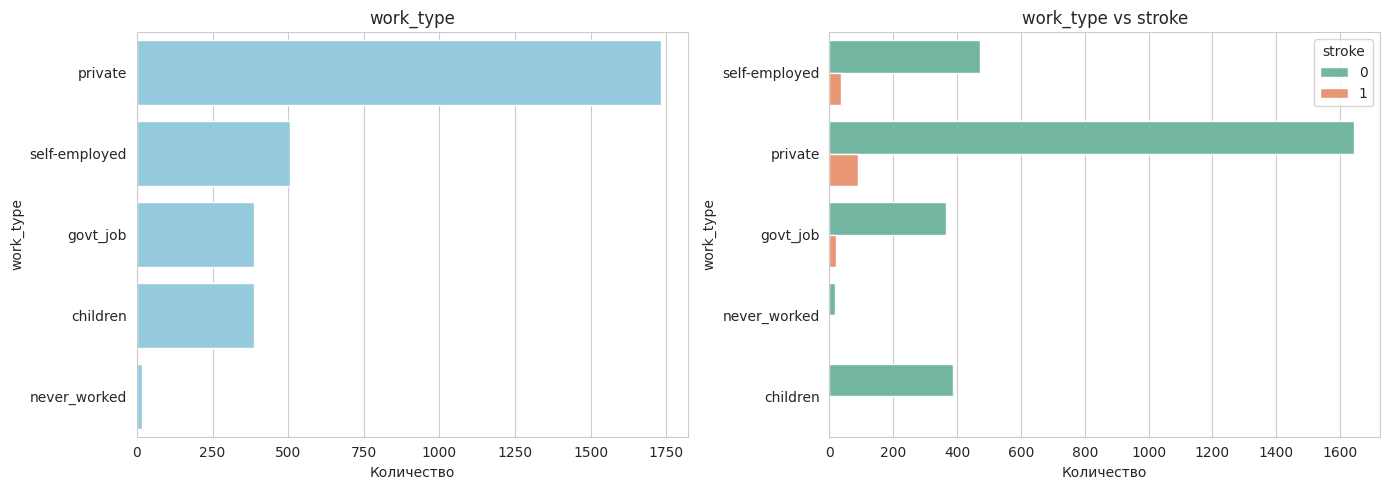

   ✓ work_type

✅ Графики категориальных колонок сохранены в: /content/drive/MyDrive/ml_learning/datasets/stroke/cycle_5/eda/plots

✓ Визуализация категориальных колонок завершена


✓ Визуализация категориальных колонок завершена



In [ ]:
# 6.2 ВИЗУАЛИЗАЦИЯ КАТЕГОРИАЛЬНЫХ КОЛОНОК

print("\n" + "="*50)
print("📊 ВИЗУАЛИЗАЦИЯ КАТЕГОРИАЛЬНЫХ КОЛОНОК")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    # Защита от None в TARGET_COLUMN
    target_display = TARGET_COLUMN if TARGET_COLUMN else 'target'

    # Определяем категориальные колонки (bool отдельно)
    categorical_cols = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
    bool_cols = X_train.select_dtypes(include=['bool']).columns.tolist()

    # ============================================
    # КАТЕГОРИАЛЬНЫЕ КОЛОНКИ
    # ============================================
    if len(categorical_cols) > 0:
        print(f"\n📋 Категориальные колонки ({len(categorical_cols)}):")
        print(f"   {categorical_cols}")
        print(f"\n💾 Сохраняем графики в: {EDA_PLOTS_PATH}\n")

        for col in categorical_cols:
            try:
                # Определяем, нужен ли hue
                use_hue = (HUE_BY_TARGET and
                          TASK_TYPE == 'classification' and
                          y_train is not None and
                          TARGET_COLUMN is not None)

                if use_hue:
                    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

                    # График 1: общее распределение
                    value_counts = X_train[col].value_counts()
                    if len(value_counts) > 20:
                        plot_data = value_counts.head(15)
                        title1 = f'{col} (топ-15 из {len(value_counts)})'
                    else:
                        plot_data = value_counts
                        title1 = col

                    sns.barplot(x=plot_data.values, y=plot_data.index, ax=axes[0], color='skyblue')
                    axes[0].set_title(title1)
                    axes[0].set_xlabel('Количество')

                    # График 2: с разделением по целевой
                    plot_df = pd.DataFrame({col: X_train[col], TARGET_COLUMN: y_train})
                    if len(X_train[col].unique()) > 10:
                        top_cats = X_train[col].value_counts().head(10).index
                        plot_df = plot_df[plot_df[col].isin(top_cats)]
                        title2 = f'{col} vs {target_display} (топ-10)'
                    else:
                        title2 = f'{col} vs {target_display}'

                    sns.countplot(data=plot_df, y=col, hue=TARGET_COLUMN, ax=axes[1], palette='Set2')
                    axes[1].set_title(title2)
                    axes[1].set_xlabel('Количество')
                    axes[1].legend(title=target_display)

                else:
                    # Только общее распределение
                    plt.figure(figsize=(8, max(4, X_train[col].nunique() * 0.3)))

                    value_counts = X_train[col].value_counts()
                    if len(value_counts) > 20:
                        plot_data = value_counts.head(15)
                        title = f'{col} (топ-15 из {len(value_counts)})'
                    else:
                        plot_data = value_counts
                        title = col

                    ax = sns.barplot(x=plot_data.values, y=plot_data.index, color='skyblue')
                    plt.title(title)
                    plt.xlabel('Количество')

                    # Добавляем проценты
                    total = len(X_train)
                    for i, (val, count) in enumerate(plot_data.items()):
                        pct = count / total * 100
                        ax.text(count + max(plot_data.values) * 0.01, i, f'{pct:.1f}%', va='center')

                plt.tight_layout()
                plot_path = os.path.join(EDA_PLOTS_PATH, f'categorical_{col}.png')
                plt.savefig(plot_path, dpi=150, bbox_inches='tight')
                plt.show()
                plt.close()

                print(f"   ✓ {col}")

            except Exception as e:
                print(f"   ⚠️ Ошибка для {col}: {e}")

        print(f"\n✅ Графики категориальных колонок сохранены в: {EDA_PLOTS_PATH}")

    # ============================================
    # BOOLEAN КОЛОНКИ (0/1)
    # ============================================
    if bool_cols:
        print(f"\n🔘 BOOLEAN КОЛОНКИ (0/1): {bool_cols}")
        print(f"   Boolean колонки можно оставить как есть, не кодируя как категории")
        print(f"\n💾 Сохраняем графики boolean колонок в: {EDA_PLOTS_PATH}\n")

        for col in bool_cols:
            try:
                plt.figure(figsize=(8, 4))

                value_counts = X_train[col].value_counts()
                total = len(X_train)

                ax = sns.barplot(x=value_counts.index.astype(str), y=value_counts.values, color='skyblue')
                plt.title(f'Распределение: {col}')
                plt.xlabel(col)
                plt.ylabel('Количество')

                # Добавляем проценты
                for i, (val, count) in enumerate(value_counts.items()):
                    pct = count / total * 100
                    ax.text(i, count + max(value_counts.values) * 0.01, f'{pct:.1f}%', ha='center', va='bottom')

                plt.tight_layout()
                plot_path = os.path.join(EDA_PLOTS_PATH, f'boolean_{col}.png')
                plt.savefig(plot_path, dpi=150, bbox_inches='tight')
                plt.show()
                plt.close()

                print(f"   ✓ {col}")

            except Exception as e:
                print(f"   ⚠️ Ошибка для {col}: {e}")

print("\n" + "="*50)
print("✓ Визуализация категориальных колонок завершена")
print("="*50 + "\n")
print("\n" + "="*50)
print("✓ Визуализация категориальных колонок завершена")
print("="*50 + "\n")

# БЛОК 7. Корреляция

In [ ]:
# 7.1 КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ

print("\n" + "="*50)
print("🔧 КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
    X_train_encoded = None
    encoders = {}
else:
    # ============================================
    # ОПРЕДЕЛЯЕМ, ЧТО КОДИРОВАТЬ
    # ============================================
    if 'X_train_clean' in globals() and X_train_clean is not None:
        print(f"\n📌 Используем X_train_clean как основу")
        base_df = X_train_clean.copy()
    else:
        print(f"\n⚠️ X_train_clean не найден, используем X_train")
        base_df = X_train.copy()

    # Создаём копию для кодирования
    X_train_encoded = base_df.copy()

    # Диагностика
    print(f"\n🔍 Диагностика исходных данных:")
    print(f"   Форма X_train_encoded: {X_train_encoded.shape}")
    print(f"   Колонки X_train_encoded: {list(X_train_encoded.columns)}")
    if 'bmi_missing_flag' in X_train_encoded.columns:
        print(f"   ✅ bmi_missing_flag присутствует")
    else:
        print(f"   ⚠️ bmi_missing_flag отсутствует в исходных данных")

    # Приводим Int64 к int64
    for col in X_train_encoded.select_dtypes(include=['Int64']).columns:
        X_train_encoded[col] = X_train_encoded[col].astype('int64')
        print(f"   ✓ {col}: Int64 → int64")

    encoders = {}

    # ============================================
    # ОСНОВНАЯ ЛОГИКА: ЕСТЬ ЛИ ЧТО КОДИРОВАТЬ?
    # ============================================
    if encoding_config:
        print("\n📊 Применяем кодирование:\n")

        # Колонки, которые НЕ нужно кодировать (сохраняем как есть)
        cols_to_keep = [col for col in X_train_encoded.columns if col not in encoding_config.keys()]
        print(f"   Колонки без кодирования (сохраняются): {len(cols_to_keep)}")

        for col, (method, params) in encoding_config.items():
            if col not in X_train_encoded.columns:
                print(f"   ⚠️ {col}: не найдена, пропускаем")
                continue

            # --------------------------------------------
            # ONE-HOT
            # --------------------------------------------
            if method == 'one_hot':
                if params and isinstance(params, dict) and 'categories' in params:
                    X_train_encoded[col] = pd.Categorical(
                        X_train_encoded[col],
                        categories=params['categories'],
                        ordered=False
                    )

                dummies = pd.get_dummies(X_train_encoded[col], prefix=col, drop_first=True, dtype=int)
                X_train_encoded = pd.concat([X_train_encoded, dummies], axis=1)
                X_train_encoded.drop(columns=[col], inplace=True)

                encoders[col] = {
                    'method': 'one_hot',
                    'columns': list(dummies.columns),
                    'drop_first': True
                }
                print(f"   ✓ {col}: ONE-HOT → {len(dummies.columns)} колонок (drop_first=True)")

            # --------------------------------------------
            # LABEL ENCODER
            # --------------------------------------------
            elif method == 'label':
                le = LabelEncoder()
                X_train_encoded[col] = le.fit_transform(X_train_encoded[col].astype(str))
                encoders[col] = {
                    'method': 'label',
                    'encoder': le,
                    'classes': le.classes_.tolist()
                }
                print(f"   ✓ {col}: LABEL → {len(le.classes_)} классов")

            # --------------------------------------------
            # РУЧНОЙ МАППИНГ (BINARY_MAP)
            # --------------------------------------------
            elif method == 'binary_map':
                if params and isinstance(params, dict):
                    # ИСПРАВЛЕНО: используем X_train_encoded вместо X_train
                    X_train_encoded[col] = X_train_encoded[col].map(params)

                    if X_train_encoded[col].isna().any():
                        unmapped = X_train_encoded[col][X_train_encoded[col].isna()].unique().tolist()
                        print(f"   ⚠️ {col}: есть незамапленные значения: {unmapped}")
                        X_train_encoded[col].fillna(-1, inplace=True)

                    X_train_encoded[col] = X_train_encoded[col].astype(int)

                    encoders[col] = {
                        'method': 'binary_map',
                        'mapping': params,
                        'default': -1
                    }
                    print(f"   ✓ {col}: BINARY_MAP → {params}")
                else:
                    print(f"   ⚠️ {col}: для binary_map нужен словарь, пропускаем")

            # --------------------------------------------
            # TARGET ENCODING
            # --------------------------------------------
            elif method == 'target':
                global_mean = y_train.mean()
                agg = y_train.groupby(X_train_encoded[col]).agg(['mean', 'count'])
                agg.columns = ['mean', 'count']

                smoothing = params if isinstance(params, (int, float)) else 10
                agg['smooth'] = (agg['count'] * agg['mean'] + smoothing * global_mean) / (agg['count'] + smoothing)

                new_col = f'{col}_target'
                X_train_encoded[new_col] = X_train_encoded[col].map(agg['smooth'])
                X_train_encoded.drop(columns=[col], inplace=True)

                encoders[col] = {
                    'method': 'target',
                    'mapping': agg['smooth'].to_dict(),
                    'global_mean': global_mean,
                    'new_column': new_col
                }
                print(f"   ✓ {col}: TARGET → {new_col} (smoothing={smoothing})")

            # --------------------------------------------
            # FREQUENCY ENCODING
            # --------------------------------------------
            elif method == 'frequency':
                freq = X_train_encoded[col].value_counts(normalize=True)
                new_col = f'{col}_freq'
                X_train_encoded[new_col] = X_train_encoded[col].map(freq)
                X_train_encoded.drop(columns=[col], inplace=True)

                encoders[col] = {
                    'method': 'frequency',
                    'mapping': freq.to_dict(),
                    'new_column': new_col
                }
                print(f"   ✓ {col}: FREQUENCY → {new_col}")

            # --------------------------------------------
            # НЕТ КОДИРОВАНИЯ (оставляем как есть)
            # --------------------------------------------
            elif method == 'none':
                print(f"   ✓ {col}: без кодирования (оставлено как есть)")
                encoders[col] = {'method': 'none'}

            else:
                print(f"   ⚠️ {col}: неизвестный метод '{method}'")

        print(f"\n✅ Кодирование завершено")
        print(f"   Форма после кодирования: {X_train_encoded.shape}")
        print(f"   Колонок стало: {len(X_train_encoded.columns)}")

        # Проверка: сохранился ли флаг?
        if 'bmi_missing_flag' in X_train_encoded.columns:
            print(f"   ✅ bmi_missing_flag сохранён")
        else:
            print(f"   ❌ bmi_missing_flag ПОТЕРЯН - проверьте логику!")

    # ============================================
    # КЛЮЧЕВОЕ ИСПРАВЛЕНИЕ: ПУСТОЙ КОНФИГ
    # ============================================
    else:
        print("\n⚠️ encoding_config пуст, кодирование не применяется")
        print("   → Просто передаём X_train_clean дальше")

        # ИСПРАВЛЕНО: используем X_train_clean, а не X_train
        X_train_encoded = base_df.copy()  # base_df уже содержит X_train_clean

        print(f"   Форма X_train_encoded: {X_train_encoded.shape}")

        # Проверка сохранения флага
        if 'bmi_missing_flag' in X_train_encoded.columns:
            print(f"   ✅ bmi_missing_flag сохранён")
        else:
            print(f"   ⚠️ bmi_missing_flag отсутствует (возможно, не был создан)")

    # ============================================
    # ФИНАЛЬНАЯ ДИАГНОСТИКА
    # ============================================
    print("\n" + "="*50)
    print("📊 ИТОГОВАЯ ДИАГНОСТИКА")
    print("="*50)
    print(f"   Форма X_train_encoded: {X_train_encoded.shape}")
    print(f"   Количество колонок: {len(X_train_encoded.columns)}")

    # Список всех колонок
    all_cols = X_train_encoded.columns.tolist()
    print(f"\n   Все колонки ({len(all_cols)}):")
    for i, col in enumerate(all_cols):
        print(f"      {i+1}. {col}")

    # Проверка флага
    if 'bmi_missing_flag' in X_train_encoded.columns:
        flag_sum = X_train_encoded['bmi_missing_flag'].sum()
        print(f"\n   ✅ bmi_missing_flag присутствует!")
        print(f"      Единиц в флаге: {flag_sum} ({flag_sum/len(X_train_encoded)*100:.1f}%)")
    else:
        print(f"\n   ❌ КРИТИЧЕСКАЯ ОШИБКА: bmi_missing_flag отсутствует!")

    # Сохраняем энкодеры (если есть)
    if encoders:
        encoders_path = os.path.join(EDA_TRANSFORMERS_PATH, 'encoders.pkl')
        joblib.dump(encoders, encoders_path)
        print(f"\n✓ Энкодеры сохранены: transformers/encoders.pkl")

print("\n" + "="*50)
print("✓ Кодирование завершено")
print("="*50 + "\n")


🔧 КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ

📌 Используем X_train_clean как основу

🔍 Диагностика исходных данных:
   Форма X_train_encoded: (3031, 7)
   Колонки X_train_encoded: ['age', 'work_type', 'avg_glucose_level', 'cardio_risk', 'stable_old_age', 'smoking_age_impact', 'bmi_missing_flag']
   ✅ bmi_missing_flag присутствует
   ✓ cardio_risk: Int64 → int64
   ✓ stable_old_age: Int64 → int64
   ✓ bmi_missing_flag: Int64 → int64

📊 Применяем кодирование:

   Колонки без кодирования (сохраняются): 6
   ✓ work_type: ONE-HOT → 4 колонок (drop_first=True)

✅ Кодирование завершено
   Форма после кодирования: (3031, 10)
   Колонок стало: 10
   ✅ bmi_missing_flag сохранён

📊 ИТОГОВАЯ ДИАГНОСТИКА
   Форма X_train_encoded: (3031, 10)
   Количество колонок: 10

   Все колонки (10):
      1. age
      2. avg_glucose_level
      3. cardio_risk
      4. stable_old_age
      5. smoking_age_impact
      6. bmi_missing_flag
      7. work_type_govt_job
      8. work_type_never_worked
      9. work_type_p


📈 КОРРЕЛЯЦИЯ ЧИСЛОВЫХ ПРИЗНАКОВ

📌 Используем X_train_clean (после обработки пропусков, ДО кодирования и масштабирования)

   Исключены из корреляции (флаги): ['bmi_missing_flag']

📊 Числовых колонок для анализа: 5
   ['age', 'avg_glucose_level', 'cardio_risk', 'stable_old_age', 'smoking_age_impact']

📊 Матрица корреляции:


,age,avg_glucose_level,cardio_risk,stable_old_age,smoking_age_impact
age,1.00,0.24,0.35,0.69,0.39
avg_glucose_level,0.24,1.00,0.20,0.21,0.15
cardio_risk,0.35,0.20,1.00,0.29,0.19
stable_old_age,0.69,0.21,0.29,1.00,0.27
smoking_age_impact,0.39,0.15,0.19,0.27,1.00


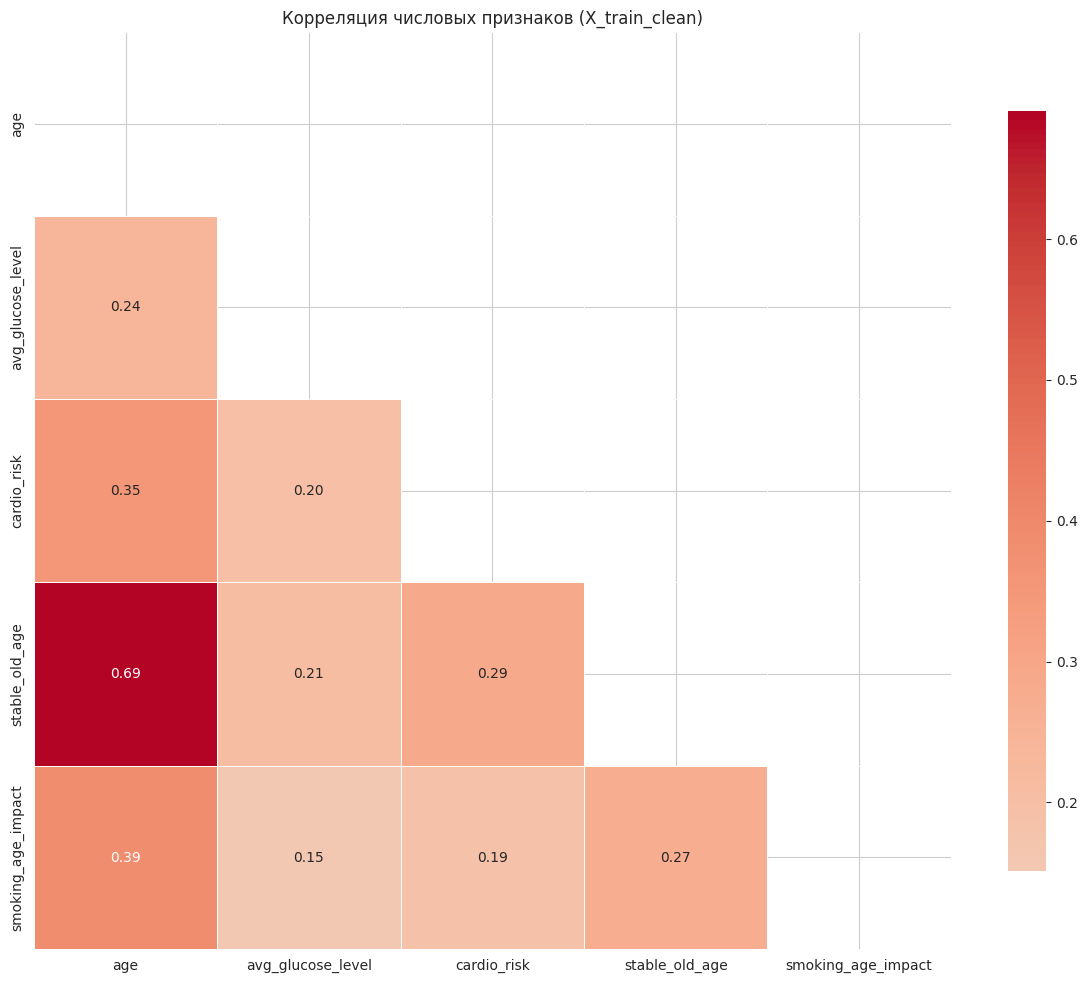


✓ Тепловая карта сохранена: plots/correlation_heatmap.png

🔍 Сильные корреляции (|r| > 0.7):

   ✅ Сильных корреляций не обнаружено

✓ Корреляционный анализ завершён



In [ ]:
# 7.2 КОРРЕЛЯЦИЯ ЧИСЛОВЫХ ПРИЗНАКОВ (ПОСЛЕ ВСЕХ УДАЛЕНИЙ)

print("\n" + "="*50)
print("📈 КОРРЕЛЯЦИЯ ЧИСЛОВЫХ ПРИЗНАКОВ")
print("="*50)

# ИСПРАВЛЕНО: используем правильный приоритет
if 'X_train_clean' in locals() and X_train_clean is not None:
    data_for_corr = X_train_clean
    print("\n📌 Используем X_train_clean (после обработки пропусков, ДО кодирования и масштабирования)")
elif 'X_train_encoded' in locals() and X_train_encoded is not None:
    data_for_corr = X_train_encoded
    print("\n⚠️ Используем X_train_encoded (после кодирования) корреляции могут быть искажены")
elif 'X_train' in locals() and X_train is not None:
    data_for_corr = X_train
    print("\n⚠️ Используем X_train (исходные) - возможны пропуски")
else:
    print("\n⚠️ Данные не загружены. Пропускаем.")
    data_for_corr = None

if data_for_corr is None:
    print("\n⚠️ Данные не загружены. Пропускаем.")
else:
    # Определяем числовые колонки (исключаем бинарные, если они не нужны для корреляции)
    numeric_cols = data_for_corr.select_dtypes(include=['int64', 'Int64', 'float64', 'int32', 'float32']).columns.tolist()

    # Опционально: исключаем флаги из корреляции (если нужно)
    flag_cols = [col for col in numeric_cols if col.endswith('_flag')]
    if flag_cols:
        print(f"\n   Исключены из корреляции (флаги): {flag_cols}")
        numeric_cols = [col for col in numeric_cols if col not in flag_cols]

    if len(numeric_cols) < 2:
        print("\n⚠️ Недостаточно числовых колонок для корреляции")
    else:
        print(f"\n📊 Числовых колонок для анализа: {len(numeric_cols)}")
        print(f"   {numeric_cols}")

        # Матрица корреляции
        corr_matrix = data_for_corr[numeric_cols].corr()

        print("\n📊 Матрица корреляции:")
        display(corr_matrix.round(2))

        # Тепловая карта
        plt.figure(figsize=(12, 10))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
                    fmt='.2f', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
        plt.title('Корреляция числовых признаков (X_train_clean)')
        plt.tight_layout()

        plot_path = os.path.join(EDA_PLOTS_PATH, 'correlation_heatmap.png')
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\n✓ Тепловая карта сохранена: plots/correlation_heatmap.png")

        # Поиск сильных корреляций
        print("\n🔍 Сильные корреляции (|r| > 0.7):")

        strong_corr = []

        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                corr_val = corr_matrix.iloc[i, j]
                if abs(corr_val) > 0.7:
                    col1, col2 = corr_matrix.columns[i], corr_matrix.columns[j]

                    if abs(corr_val) > 0.9:
                        level = "🔴"
                    elif abs(corr_val) > 0.8:
                        level = "🟠"
                    else:
                        level = "🟡"

                    strong_corr.append({
                        '': level,
                        'Признак 1': col1,
                        'Признак 2': col2,
                        'Корреляция': f"{corr_val:+.2f}"
                    })

        if strong_corr:
            print(f"\n   Найдено пар: {len(strong_corr)}")
            strong_df = pd.DataFrame(strong_corr).sort_values('Корреляция', ascending=False)
            display(strong_df)
            print("\n💡 Рекомендация: рассмотрите удаление одного из пары")

            print("\n📝 Пример для features_to_drop (блок 1.2):")
            print("   features_to_drop = [")
            for pair in strong_corr[:3]:
                print(f"       '{pair['Признак 2']}',  # коррелирует с {pair['Признак 1']} ({pair['Корреляция']})")
            print("   ]")
        else:
            print("\n   ✅ Сильных корреляций не обнаружено")

print("\n" + "="*50)
print("✓ Корреляционный анализ завершён")
print("="*50 + "\n")


🎯 СВЯЗЬ ПРИЗНАКОВ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

📌 Используем X_train_clean (рекомендуется для анализа)

📊 Числовых признаков для анализа: 6

📊 ANOVA F-value (классификация):



,Признак,F-value,p-value,Значимость
0,age,193.9963,0.0,🟢
3,stable_old_age,150.2447,0.0,🟢
5,bmi_missing_flag,83.2947,0.0,🟢
2,cardio_risk,65.1248,0.0,🟢
1,avg_glucose_level,62.1871,0.0,🟢
4,smoking_age_impact,52.1406,0.0,🟢


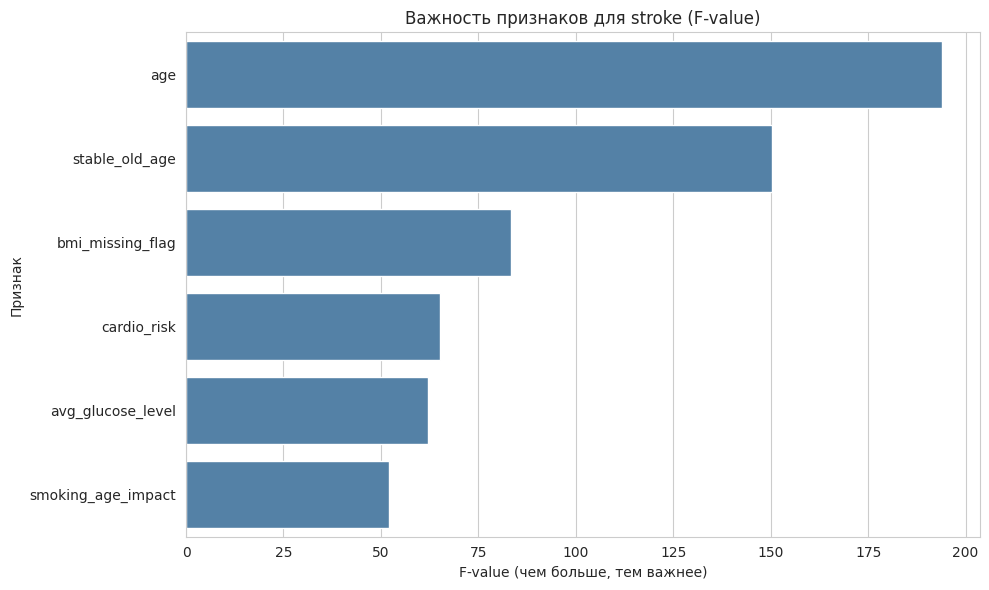


✓ График сохранён: plots/target_fvalue.png

✓ Анализ связи с целевой завершён



In [ ]:
# 7.3 СВЯЗЬ ПРИЗНАКОВ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (ПОСЛЕ ВСЕХ УДАЛЕНИЙ)

print("\n" + "="*50)
print("🎯 СВЯЗЬ ПРИЗНАКОВ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
print("="*50)

# ИСПРАВЛЕНО: используем правильный приоритет
if 'X_train_clean' in locals() and X_train_clean is not None:
    data_for_analysis = X_train_clean
    print("\n📌 Используем X_train_clean (рекомендуется для анализа)")
elif 'X_train_encoded' in locals() and X_train_encoded is not None:
    data_for_analysis = X_train_encoded
    print("\n⚠️ Используем X_train_encoded (после кодирования)")
elif 'X_train' in locals() and X_train is not None:
    data_for_analysis = X_train
    print("\n⚠️ Используем X_train (исходные)")
else:
    print("\n⚠️ Данные не загружены. Пропускаем.")
    data_for_analysis = None

if data_for_analysis is None or y_train is None:
    print("\n⚠️ Данные не загружены. Пропускаем.")
else:
    # ============================================
    # ПРОВЕРКА СИНХРОНИЗАЦИИ РАЗМЕРОВ
    # ============================================
    if len(data_for_analysis) != len(y_train):
        print(f"\n❌ ОШИБКА: Размеры не совпадают!")
        print(f"   data_for_analysis: {len(data_for_analysis)} строк")
        print(f"   y_train: {len(y_train)} строк")
        print(f"   → Пропускаем анализ")
    else:
        target_display = TARGET_COLUMN if TARGET_COLUMN else 'target'

        # Числовые колонки
        numeric_cols = data_for_analysis.select_dtypes(include=['int64', 'Int64', 'float64', 'int32', 'float32']).columns.tolist()

        # ============================================
        # УДАЛЯЕМ КОНСТАНТНЫЕ КОЛОНКИ (вызывают ошибку в f_classif)
        # ============================================
        constant_cols = []
        valid_numeric_cols = []

        for col in numeric_cols:
            if data_for_analysis[col].nunique() <= 1:
                constant_cols.append(col)
                print(f"   ⚠️ Константная колонка (исключена): {col}")
            else:
                valid_numeric_cols.append(col)

        if constant_cols:
            print(f"\n   Исключено константных колонок: {len(constant_cols)}")

        # ============================================
        # ПРОВЕРКА НА NaN (аварийная)
        # ============================================
        cols_with_nan = []
        for col in valid_numeric_cols:
            if data_for_analysis[col].isna().any():
                cols_with_nan.append(col)
                nan_count = data_for_analysis[col].isna().sum()
                print(f"   ⚠️ NaN в колонке {col}: {nan_count} значений")

        if cols_with_nan:
            print(f"\n❌ ОШИБКА: Есть NaN в данных! Запустите блок 3.3 сначала.")
            print(f"   Колонки с NaN: {cols_with_nan}")
        elif len(valid_numeric_cols) == 0:
            print("\n⚠️ Нет числовых колонок для анализа (все константные)")
        else:
            print(f"\n📊 Числовых признаков для анализа: {len(valid_numeric_cols)}")

            if TASK_TYPE == 'regression':
                # Корреляция Пирсона
                print("\n📈 Корреляция Пирсона с целевой переменной:\n")

                target_corr = {}
                for col in valid_numeric_cols:
                    corr_val = data_for_analysis[col].corr(y_train)
                    target_corr[col] = corr_val

                target_corr_df = pd.DataFrame({
                    'Признак': list(target_corr.keys()),
                    'Корреляция': list(target_corr.values())
                }).sort_values('Корреляция', key=abs, ascending=False)

                target_corr_df['Уровень'] = target_corr_df['Корреляция'].apply(
                    lambda x: '🔴' if abs(x) < 0.1 else ('🟡' if abs(x) < 0.15 else '🟢')
                )

                display(target_corr_df)

                # Визуализация
                if len(target_corr_df) > 0:
                    plt.figure(figsize=(10, max(6, len(valid_numeric_cols) * 0.3)))
                    colors = ['green' if x > 0 else 'red' for x in target_corr_df['Корреляция']]
                    sns.barplot(x='Корреляция', y='Признак', data=target_corr_df, palette=colors)
                    plt.title(f'Корреляция признаков с {target_display}')
                    plt.xlabel('Коэффициент корреляции Пирсона')
                    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
                    plt.tight_layout()

                    plot_path = os.path.join(EDA_PLOTS_PATH, 'target_correlation.png')
                    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
                    plt.show()
                    print(f"\n✓ График сохранён: plots/target_correlation.png")

            else:  # classification
                # ANOVA F-value
                print("\n📊 ANOVA F-value (классификация):\n")

                try:
                    # Используем только валидные колонки
                    X_for_anova = data_for_analysis[valid_numeric_cols]

                    # Дополнительная проверка: удаляем строки с NaN (если вдруг)
                    if X_for_anova.isna().any().any():
                        print("   ⚠️ Обнаружены NaN, удаляем строки...")
                        clean_mask = ~X_for_anova.isna().any(axis=1)
                        X_for_anova = X_for_anova[clean_mask]
                        y_clean = y_train[clean_mask]
                        print(f"   Осталось строк: {len(X_for_anova)}")
                    else:
                        y_clean = y_train

                    f_values, p_values = f_classif(X_for_anova, y_clean)

                    f_corr_df = pd.DataFrame({
                        'Признак': valid_numeric_cols,
                        'F-value': f_values,
                        'p-value': p_values
                    }).sort_values('F-value', ascending=False)

                    f_corr_df['Значимость'] = f_corr_df['p-value'].apply(
                        lambda x: '🔴' if x >= 0.05 else ('🟡' if x >= 0.01 else '🟢')
                    )

                    display(f_corr_df.round(4))

                    # Визуализация (только если есть признаки)
                    if len(f_corr_df) > 0:
                        plt.figure(figsize=(10, max(6, len(valid_numeric_cols) * 0.3)))
                        colors = ['lightgray' if p >= 0.05 else 'steelblue' for p in f_corr_df['p-value']]
                        sns.barplot(x='F-value', y='Признак', data=f_corr_df, palette=colors)
                        plt.title(f'Важность признаков для {target_display} (F-value)')
                        plt.xlabel('F-value (чем больше, тем важнее)')
                        plt.tight_layout()

                        plot_path = os.path.join(EDA_PLOTS_PATH, 'target_fvalue.png')
                        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
                        plt.show()
                        print(f"\n✓ График сохранён: plots/target_fvalue.png")

                    # Статистически незначимые признаки
                    insignificant = f_corr_df[f_corr_df['p-value'] >= 0.05]
                    if len(insignificant) > 0:
                        print(f"\n🔴 Статистически незначимые признаки (p ≥ 0.05):")
                        for _, row in insignificant.iterrows():
                            print(f"   • {row['Признак']}: p={row['p-value']:.4f}")
                        print(f"\n   ⚠️ Это НЕ значит, что признаки бесполезны!")
                        print(f"      • ANOVA проверяет разницу средних между классами")
                        print(f"      • Возможна нелинейная связь или взаимодействия")
                        print(f"      • Дождитесь RF-важности (блок 9.2) перед удалением")

                except Exception as e:
                    print(f"\n❌ ОШИБКА при расчёте ANOVA: {e}")
                    print(f"   Возможные причины:")
                    print(f"   • В данных есть константные колонки (должны быть исключены)")
                    print(f"   • В y_train только один класс")
                    print(f"   • Проблемы с типами данных")
                    print(f"\n   → Пропускаем визуализацию, но продолжаем выполнение")

print("\n" + "="*50)
print("✓ Анализ связи с целевой завершён")
print("="*50 + "\n")

In [ ]:
# 7.4 УДАЛЕНИЕ ПРИЗНАКОВ (КОРРЕЛЯЦИОННЫЙ ОТБОР) - УНИВЕРСАЛЬНАЯ ВЕРСИЯ

print("\n" + "="*50)
print("🗑️ УДАЛЕНИЕ ПРИЗНАКОВ (КОРРЕЛЯЦИОННЫЙ ОТБОР)")
print("="*50)

if X_train is None:
    print("\n⚠️ X_train не загружен. Пропускаем.")
else:
    # ============================================
    # ФУНКЦИЯ ДЛЯ УМНОГО УДАЛЕНИЯ
    # ============================================
    def drop_columns_smart(df, columns_to_drop, df_name=""):
        if df is None or not columns_to_drop:
            return df, 0, []

        df = df.copy()
        dropped = []

        for col in columns_to_drop:
            # Прямое удаление
            if col in df.columns:
                df.drop(columns=[col], inplace=True)
                dropped.append(col)
                continue

            # One-hot колонки с префиксом
            onehot_cols = [c for c in df.columns if c.startswith(f"{col}_")]
            if onehot_cols:
                df.drop(columns=onehot_cols, inplace=True)
                dropped.extend(onehot_cols)
                continue

            # Target-кодированные
            target_col = f"{col}_target"
            if target_col in df.columns:
                df.drop(columns=[target_col], inplace=True)
                dropped.append(target_col)
                continue

            # Frequency-кодированные
            freq_col = f"{col}_freq"
            if freq_col in df.columns:
                df.drop(columns=[freq_col], inplace=True)
                dropped.append(freq_col)
                continue

        return df, len(dropped), dropped

    # ============================================
    # ЗАПОМИНАЕМ ФЛАГИ ДО УДАЛЕНИЯ (универсально)
    # ============================================
    def get_flag_columns(df):
        """Возвращает список колонок-флагов (заканчиваются на _flag)"""
        if df is None:
            return []
        return [col for col in df.columns if col.endswith('_flag')]

    if features_to_drop:
        print(f"\n📋 Признаки для удаления ({len(features_to_drop)}):")
        print(f"   {features_to_drop}")

        # ⚠️ Универсальная проверка: не удаляем ли мы флаги?
        flags_in_drop = [col for col in features_to_drop if col.endswith('_flag')]
        if flags_in_drop:
            print(f"\n   ⚠️ ВНИМАНИЕ: Вы пытаетесь удалить флаги: {flags_in_drop}")
            print(f"   → Флаги обычно нужны для анализа пропусков.")
            print(f"   → Удалите их из features_to_drop, если не уверены.")

        # ============================================
        # СОХРАНЯЕМ СПИСОК ФЛАГОВ ДО УДАЛЕНИЯ
        # ============================================
        if 'X_train_clean' in globals() and X_train_clean is not None:
            flags_before = get_flag_columns(X_train_clean)
            print(f"\n📋 Флаги ДО удаления: {flags_before if flags_before else 'нет'}")

        # ============================================
        # ПРИМЕНЯЕМ УДАЛЕНИЕ КО ВСЕМ ВЕРСИЯМ
        # ============================================
        # X_train
        X_train, _, _ = drop_columns_smart(X_train, features_to_drop, "X_train")

        # X_train_encoded
        if 'X_train_encoded' in globals() and X_train_encoded is not None:
            X_train_encoded, _, _ = drop_columns_smart(X_train_encoded, features_to_drop, "X_train_encoded")

        # X_val
        if 'X_val' in globals() and X_val is not None:
            X_val, _, _ = drop_columns_smart(X_val, features_to_drop, "X_val")

        # X_test
        if 'X_test' in globals() and X_test is not None:
            X_test, _, _ = drop_columns_smart(X_test, features_to_drop, "X_test")

        # CLEAN-версии
        if 'X_train_clean' in globals() and X_train_clean is not None:
            X_train_clean, _, _ = drop_columns_smart(X_train_clean, features_to_drop, "X_train_clean")

        if 'X_val_clean' in globals() and X_val_clean is not None:
            X_val_clean, _, _ = drop_columns_smart(X_val_clean, features_to_drop, "X_val_clean")

        if 'X_test_clean' in globals() and X_test_clean is not None:
            X_test_clean, _, _ = drop_columns_smart(X_test_clean, features_to_drop, "X_test_clean")

        # ============================================
        # УНИВЕРСАЛЬНАЯ ПРОВЕРКА: все ли флаги на месте?
        # ============================================
        print("\n🔍 ПРОВЕРКА СОХРАНЕНИЯ ФЛАГОВ:")

        if 'X_train_clean' in globals() and X_train_clean is not None:
            flags_after = get_flag_columns(X_train_clean)
            flags_lost = set(flags_before) - set(flags_after)

            if flags_lost:
                print(f"   ❌ ПОТЕРЯНЫ ФЛАГИ: {list(flags_lost)}")
                print(f"   → Проверьте, не попали ли они в features_to_drop")
            else:
                print(f"   ✅ Все флаги сохранены: {flags_after if flags_after else 'флагов нет'}")

        # Остальная диагностика (ваша существующая)
        # ...

    else:
        print("\n⚠️ features_to_drop пуст.")

print("\n" + "="*50)
print("✓ Удаление признаков завершено")
print("="*50 + "\n")


🗑️ УДАЛЕНИЕ ПРИЗНАКОВ (КОРРЕЛЯЦИОННЫЙ ОТБОР)

⚠️ features_to_drop пуст.

✓ Удаление признаков завершено



# БЛОК 8. Обучение трансформеров

In [ ]:
# 8.1 ОПРЕДЕЛЕНИЕ ТИПОВ КОЛОНОК ДЛЯ МАСШТАБИРОВАНИЯ

print("\n" + "="*50)
print("🔍 ОПРЕДЕЛЕНИЕ ТИПОВ КОЛОНОК")
print("="*50)

if X_train is None:
    print("\n⚠️ Данные не загружены. Пропускаем.")
    df_for_analysis = None
else:
    # ============================================
    # ИСПРАВЛЕНО: приоритет у X_train_clean (более полные данные)
    # ============================================
    if 'X_train_clean' in globals() and X_train_clean is not None:
        df_for_analysis = X_train_clean
        source = "X_train_clean (рекомендуется для анализа)"
        print(f"\n✅ Источник данных: {source}")
    elif 'X_train_encoded' in globals() and X_train_encoded is not None:
        df_for_analysis = X_train_encoded
        source = "X_train_encoded (после кодирования)"
        print(f"\n⚠️ Источник данных: {source}")
        print(f"   → Если здесь мало колонок, проверьте блок 7.1")
    else:
        df_for_analysis = X_train
        source = "X_train (исходные)"
        print(f"\n⚠️ Источник данных: {source}")

    print(f"   Размер: {df_for_analysis.shape}")
    print(f"   Колонок: {df_for_analysis.shape[1]}")

    # ============================================
    # ПРОВЕРКА: есть ли флаги?
    # ============================================
    flag_cols = [col for col in df_for_analysis.columns if col.endswith('_flag')]
    if flag_cols:
        print(f"\n✅ Обнаружены флаги: {flag_cols}")
    else:
        print(f"\n⚠️ Флаги не обнаружены (возможно, потеряны на предыдущих этапах)")

    # Определяем типы колонок
    numeric_types = ['int16', 'int32', 'int64', 'Int64',
                     'float16', 'float32', 'float64',
                     'uint8', 'uint16', 'uint32', 'uint64',
                     'bool']

    numeric_cols_final = df_for_analysis.select_dtypes(include=numeric_types).columns.tolist()
    categorical_cols_final = df_for_analysis.select_dtypes(include=['object', 'category']).columns.tolist()

    # Статистика
    print(f"\n📊 Состав признаков:")
    print(f"   Числовые: {len(numeric_cols_final)}")
    print(f"   Категориальные: {len(categorical_cols_final)}")

    # Детали по числовым
    if numeric_cols_final:
        continuous = [c for c in numeric_cols_final if df_for_analysis[c].nunique() > 2]
        binary = [c for c in numeric_cols_final if df_for_analysis[c].nunique() <= 2]

        print(f"\n🔢 Числовые признаки:")
        if continuous:
            print(f"   Непрерывные ({len(continuous)}):")
            for col in continuous[:10]:
                print(f"      • {col}")
            if len(continuous) > 10:
                print(f"      ... и ещё {len(continuous) - 10}")
        else:
            print(f"   Непрерывные: нет")

        if binary:
            print(f"   Бинарные ({len(binary)}):")
            for col in binary[:10]:
                print(f"      • {col}")
            if len(binary) > 10:
                print(f"      ... и ещё {len(binary) - 10}")

        if continuous:
            print(f"\n💡 Непрерывные признаки требуют масштабирования")
            print(f"   Рекомендуемые методы:")
            print(f"   • StandardScaler - для нормально распределённых")
            print(f"   • RobustScaler - при наличии выбросов")
            print(f"   • MinMaxScaler - для нейронных сетей")

            # Подсказка для scaling_config
            print(f"\n📝 Текущий scaling_config (из блока 1.2):")
            if scaling_config:
                for col, (method, _) in scaling_config.items():
                    print(f"   • {col}: {method}")
            else:
                print(f"   ⚠️ scaling_config пуст")

    # Категориальные
    if categorical_cols_final:
        print(f"\n🏷️ Категориальные признаки ({len(categorical_cols_final)}):")
        for col in categorical_cols_final[:10]:
            print(f"   • {col} ({df_for_analysis[col].nunique()} значений)")
        if len(categorical_cols_final) > 10:
            print(f"   ... и ещё {len(categorical_cols_final) - 10}")

        print(f"\n⚠️ Категориальные признаки требуют кодирования!")
        print(f"   Выполните блок 7.1 или укажите их в encoding_config")

print("\n" + "="*50)
print("✓ Анализ типов завершён")
print("="*50 + "\n")


🔍 ОПРЕДЕЛЕНИЕ ТИПОВ КОЛОНОК

✅ Источник данных: X_train_clean (рекомендуется для анализа)
   Размер: (3031, 7)
   Колонок: 7

✅ Обнаружены флаги: ['bmi_missing_flag']

📊 Состав признаков:
   Числовые: 6
   Категориальные: 1

🔢 Числовые признаки:
   Непрерывные (3):
      • age
      • avg_glucose_level
      • smoking_age_impact
   Бинарные (3):
      • cardio_risk
      • stable_old_age
      • bmi_missing_flag

💡 Непрерывные признаки требуют масштабирования
   Рекомендуемые методы:
   • StandardScaler - для нормально распределённых
   • RobustScaler - при наличии выбросов
   • MinMaxScaler - для нейронных сетей

📝 Текущий scaling_config (из блока 1.2):
   • age: standard
   • avg_glucose_level: robust
   • smoking_age_impact: robust

🏷️ Категориальные признаки (1):
   • work_type (5 значений)

⚠️ Категориальные признаки требуют кодирования!
   Выполните блок 7.1 или укажите их в encoding_config

✓ Анализ типов завершён



In [ ]:
# 8.2 МАСШТАБИРОВАНИЕ ЧИСЛОВЫХ ПРИЗНАКОВ

print("\n" + "="*50)
print("📐 МАСШТАБИРОВАНИЕ ЧИСЛОВЫХ ПРИЗНАКОВ")
print("="*50)

# ============================================
# ИСПРАВЛЕНО: правильный приоритет источников
# ============================================
if 'X_train_encoded' in globals() and X_train_encoded is not None:
    data_to_scale = X_train_encoded.copy()
    source = "X_train_encoded"
    print(f"\n📌 Источник: X_train_encoded")
elif 'X_train_clean' in globals() and X_train_clean is not None:
    data_to_scale = X_train_clean.copy()
    source = "X_train_clean"
    print(f"\n⚠️ Источник: X_train_clean (X_train_encoded не найден)")
elif X_train is not None:
    data_to_scale = X_train.copy()
    source = "X_train"
    print(f"\n⚠️ Источник: X_train (потеряны флаги и кодирование!)")
else:
    print("\n⚠️ Данные не загружены. Пропускаем.")
    data_to_scale = None

if data_to_scale is not None:
    # ============================================
    # ФИКСИРУЕМ СПИСОК ВСЕХ КОЛОНОК ДО МАСШТАБИРОВАНИЯ
    # ============================================
    original_columns = set(data_to_scale.columns)
    X_train_scaled = data_to_scale.copy()
    scalers = {}

    # Проверка: есть ли флаги?
    flag_cols = [col for col in X_train_scaled.columns if col.endswith('_flag')]
    if flag_cols:
        print(f"\n✅ Обнаружены флаги: {flag_cols}")
    else:
        print(f"\n⚠️ Флаги отсутствуют в исходных данных")

    if scaling_config:
        print(f"\n📊 Применяем масштабирование:\n")

        for col, (method, params) in scaling_config.items():
            if col not in X_train_scaled.columns:
                print(f"   ⚠️ {col}: не найдена, пропускаем")
                continue

            if method == 'none':
                print(f"   • {col}: без масштабирования")
                continue

            # Выбор scaler'а
            if method == 'standard':
                scaler = StandardScaler()
                scaler_name = "StandardScaler"
            elif method == 'robust':
                scaler = RobustScaler()
                scaler_name = "RobustScaler"
            elif method == 'minmax':
                scaler = MinMaxScaler()
                scaler_name = "MinMaxScaler"
            else:
                print(f"   ⚠️ {col}: неизвестный метод '{method}'")
                continue

            # Статистика ДО
            mean_before = X_train_scaled[col].mean()
            std_before = X_train_scaled[col].std()

            # Масштабирование
            X_train_scaled[col] = scaler.fit_transform(X_train_scaled[[col]]).flatten()
            scalers[col] = scaler

            # Статистика ПОСЛЕ
            mean_after = X_train_scaled[col].mean()
            std_after = X_train_scaled[col].std()

            print(f"   ✓ {col}: {scaler_name}")
            print(f"      до: μ={mean_before:.3f}, σ={std_before:.3f}")
            print(f"      после: μ={mean_after:.3f}, σ={std_after:.3f}")

        # Сохраняем scaler'ы
        if scalers:
            scalers_path = os.path.join(EDA_TRANSFORMERS_PATH, 'scalers.pkl')
            joblib.dump(scalers, scalers_path)
            print(f"\n✅ Scaler'ы сохранены: transformers/scalers.pkl")
    else:
        print("\n⚠️ scaling_config пуст, масштабирование не применяется")
        print("   → Данные передаются без изменений")

    # ============================================
    # ПРОВЕРКА: все ли колонки на месте?
    # ============================================
    final_columns = set(X_train_scaled.columns)
    lost_columns = original_columns - final_columns

    if lost_columns:
        print(f"\n❌ ПОТЕРЯНЫ КОЛОНКИ: {list(lost_columns)}")
    else:
        print(f"\n✅ Все колонки сохранены ({len(final_columns)})")

    # Проверка флагов
    flag_cols_after = [col for col in X_train_scaled.columns if col.endswith('_flag')]
    if flag_cols_after:
        print(f"✅ Флаги на месте: {flag_cols_after}")
    elif flag_cols:
        print(f"❌ ФЛАГИ ПОТЕРЯНЫ! Были: {flag_cols}")

    print(f"\n📊 Форма данных: {X_train_scaled.shape}")

    # Сохраняем масштабированные данные
    scaled_path = os.path.join(EDA_DATA_PATH, 'X_train_scaled.csv')
    X_train_scaled.to_csv(scaled_path, index=False)
    print(f"✓ Данные сохранены: {EDA_DATA_PATH}/X_train_scaled.csv")

print("\n" + "="*50)
print("✓ Масштабирование завершено")
print("="*50 + "\n")


📐 МАСШТАБИРОВАНИЕ ЧИСЛОВЫХ ПРИЗНАКОВ

📌 Источник: X_train_encoded

✅ Обнаружены флаги: ['bmi_missing_flag']

📊 Применяем масштабирование:

   ✓ age: StandardScaler
      до: μ=43.342, σ=22.292
      после: μ=0.000, σ=1.000
   ✓ avg_glucose_level: RobustScaler
      до: μ=105.788, σ=44.610
      после: μ=0.376, σ=1.228
   ✓ smoking_age_impact: RobustScaler
      до: μ=16.754, σ=25.866
      после: μ=0.453, σ=0.699

✅ Scaler'ы сохранены: transformers/scalers.pkl

✅ Все колонки сохранены (10)
✅ Флаги на месте: ['bmi_missing_flag']

📊 Форма данных: (3031, 10)
✓ Данные сохранены: /content/drive/MyDrive/ml_learning/datasets/stroke/cycle_5/eda/data/X_train_scaled.csv

✓ Масштабирование завершено



In [ ]:
# 8.3 ФИНАЛЬНОЕ УДАЛЕНИЕ ПРИЗНАКОВ

print("\n" + "="*50)
print("🗑️ ФИНАЛЬНОЕ УДАЛЕНИЕ ПРИЗНАКОВ")
print("="*50)

if X_train is None:
    print("\n⚠️ Данные не загружены. Пропускаем.")
else:
    # ============================================
    # УНИВЕРСАЛЬНАЯ ФУНКЦИЯ УДАЛЕНИЯ
    # ============================================
    def safe_drop_columns(df, columns_to_drop, df_name=""):
        """Безопасно удаляет колонки из датафрейма"""
        if df is None or not columns_to_drop:
            return df, 0

        existing = [col for col in columns_to_drop if col in df.columns]
        if existing:
            df.drop(columns=existing, inplace=True)
            return df, len(existing)
        return df, 0

    # ============================================
    # ЗАПОМИНАЕМ ФЛАГИ ДО УДАЛЕНИЯ
    # ============================================
    def get_flag_columns(df):
        if df is None:
            return []
        return [col for col in df.columns if col.endswith('_flag')]

    if columns_to_drop_final:
        print(f"\n📋 Признаки для удаления ({len(columns_to_drop_final)}):")
        print(f"   {columns_to_drop_final}")

        # Проверка: не удаляем ли мы флаги?
        flags_in_drop = [col for col in columns_to_drop_final if col.endswith('_flag')]
        if flags_in_drop:
            print(f"\n   ⚠️ ВНИМАНИЕ: Вы пытаетесь удалить флаги: {flags_in_drop}")
            print(f"   → Флаги обычно нужны для анализа. Удалите их из columns_to_drop_final.")

        # Сохраняем флаги ДО удаления (если есть clean-версия)
        flags_before = {}
        if 'X_train_clean' in globals() and X_train_clean is not None:
            flags_before['X_train_clean'] = get_flag_columns(X_train_clean)
        if 'X_train_scaled' in globals() and X_train_scaled is not None:
            flags_before['X_train_scaled'] = get_flag_columns(X_train_scaled)

        # Статистика до
        shape_before_train = X_train.shape
        shape_before_val = X_val.shape if 'X_val' in globals() and X_val is not None else None
        shape_before_test = X_test.shape if 'X_test' in globals() and X_test is not None else None

        # ============================================
        # ПРИМЕНЯЕМ УДАЛЕНИЕ КО ВСЕМ ВЕРСИЯМ
        # ============================================

        # X_train
        X_train, dropped_train = safe_drop_columns(X_train, columns_to_drop_final, "X_train")
        print(f"\n   ✓ X_train: удалено {dropped_train}")

        # X_train_encoded
        if 'X_train_encoded' in globals() and X_train_encoded is not None:
            X_train_encoded, dropped_enc = safe_drop_columns(X_train_encoded, columns_to_drop_final, "X_train_encoded")
            print(f"   ✓ X_train_encoded: удалено {dropped_enc}")

        # X_train_scaled (ВАЖНО!)
        if 'X_train_scaled' in globals() and X_train_scaled is not None:
            X_train_scaled, dropped_scaled = safe_drop_columns(X_train_scaled, columns_to_drop_final, "X_train_scaled")
            print(f"   ✓ X_train_scaled: удалено {dropped_scaled}")

        # X_val
        if 'X_val' in globals() and X_val is not None:
            X_val, dropped_val = safe_drop_columns(X_val, columns_to_drop_final, "X_val")
            print(f"   ✓ X_val: удалено {dropped_val}")

        # X_test
        if 'X_test' in globals() and X_test is not None:
            X_test, dropped_test = safe_drop_columns(X_test, columns_to_drop_final, "X_test")
            print(f"   ✓ X_test: удалено {dropped_test}")

        # CLEAN-версии
        print("\n🧹 Удаление из CLEAN-версий:")

        if 'X_train_clean' in globals() and X_train_clean is not None:
            X_train_clean, dropped_train_clean = safe_drop_columns(X_train_clean, columns_to_drop_final, "X_train_clean")
            print(f"   ✓ X_train_clean: удалено {dropped_train_clean}")

        if 'X_val_clean' in globals() and X_val_clean is not None:
            X_val_clean, dropped_val_clean = safe_drop_columns(X_val_clean, columns_to_drop_final, "X_val_clean")
            print(f"   ✓ X_val_clean: удалено {dropped_val_clean}")

        if 'X_test_clean' in globals() and X_test_clean is not None:
            X_test_clean, dropped_test_clean = safe_drop_columns(X_test_clean, columns_to_drop_final, "X_test_clean")
            print(f"   ✓ X_test_clean: удалено {dropped_test_clean}")

        # Не найденные колонки
        not_found = [col for col in columns_to_drop_final if col not in X_train.columns]
        if not_found:
            print(f"\n   ⚠️ Не найдены в X_train: {not_found}")

        # ============================================
        # ПРОВЕРКА СОХРАНЕНИЯ ФЛАГОВ
        # ============================================
        print("\n🔍 ПРОВЕРКА ФЛАГОВ:")

        if 'X_train_clean' in globals() and X_train_clean is not None:
            flags_after = get_flag_columns(X_train_clean)
            flags_lost = set(flags_before.get('X_train_clean', [])) - set(flags_after)

            if flags_lost:
                print(f"   ❌ ПОТЕРЯНЫ ФЛАГИ: {list(flags_lost)}")
            else:
                print(f"   ✅ Все флаги сохранены: {flags_after if flags_after else 'нет'}")

        # Статистика после
        print(f"\n📊 Изменения:")
        print(f"   Train: {shape_before_train[1]} → {X_train.shape[1]} признаков (-{shape_before_train[1] - X_train.shape[1]})")
        if shape_before_val:
            print(f"   Val:   {shape_before_val[1]} → {X_val.shape[1]} признаков (-{shape_before_val[1] - X_val.shape[1]})")
        if shape_before_test:
            print(f"   Test:  {shape_before_test[1]} → {X_test.shape[1]} признаков (-{shape_before_test[1] - X_test.shape[1]})")

    else:
        print("\n✅ columns_to_drop_final пуст - удаление не требуется")

    # ============================================
    # ПРОВЕРКА КОНСИСТЕНТНОСТИ КОЛОНОК
    # ============================================
    print("\n📊 Проверка консистентности колонок:")

    # Проверяем X_val
    if 'X_val' in globals() and X_val is not None:
        train_cols = set(X_train.columns)
        val_cols = set(X_val.columns)
        if train_cols != val_cols:
            diff = train_cols.symmetric_difference(val_cols)
            print(f"   ⚠️ Train и Val различаются: {diff}")
        else:
            print(f"   ✓ Train и Val: колонки совпадают ({len(train_cols)})")

    # Проверяем X_test
    if 'X_test' in globals() and X_test is not None:
        train_cols = set(X_train.columns)
        test_cols = set(X_test.columns)
        if train_cols != test_cols:
            diff = train_cols.symmetric_difference(test_cols)
            print(f"   ⚠️ Train и Test различаются: {diff}")
        else:
            print(f"   ✓ Train и Test: колонки совпадают ({len(train_cols)})")

    # ============================================
    # ФИНАЛЬНЫЕ РАЗМЕРЫ
    # ============================================
    print(f"\n📊 Финальные размеры:")
    print(f"   X_train: {X_train.shape}")
    if 'X_train_encoded' in globals() and X_train_encoded is not None:
        print(f"   X_train_encoded: {X_train_encoded.shape}")
    if 'X_train_scaled' in globals() and X_train_scaled is not None:
        print(f"   X_train_scaled: {X_train_scaled.shape}")
    if 'X_val' in globals() and X_val is not None:
        print(f"   X_val: {X_val.shape}")
    if 'X_test' in globals() and X_test is not None:
        print(f"   X_test: {X_test.shape}")

print("\n" + "="*50)
print("✓ Финальное удаление завершено")
print("="*50 + "\n")


🗑️ ФИНАЛЬНОЕ УДАЛЕНИЕ ПРИЗНАКОВ

✅ columns_to_drop_final пуст - удаление не требуется

📊 Проверка консистентности колонок:
   ✓ Train и Val: колонки совпадают (3)
   ✓ Train и Test: колонки совпадают (3)

📊 Финальные размеры:
   X_train: (3031, 3)
   X_train_encoded: (3031, 10)
   X_train_scaled: (3031, 10)
   X_val: (1011, 3)
   X_test: (1011, 3)

✓ Финальное удаление завершено



In [ ]:
# 8.4 СОХРАНЕНИЕ ПОДГОТОВЛЕННЫХ ДАННЫХ И МЕТАДАННЫХ

print("\n" + "="*50)
print("💾 СОХРАНЕНИЕ ПОДГОТОВЛЕННЫХ ДАННЫХ")
print("="*50)

if X_train is None:
    print("\n⚠️ Данные не загружены. Пропускаем.")
else:
    # Защита от None в TARGET_COLUMN
    target_display = TARGET_COLUMN if TARGET_COLUMN else 'target'

    # Определяем основную версию данных (используем globals)
    if 'X_train_encoded' in globals() and X_train_encoded is not None:
        data_for_meta = X_train_encoded
        data_version = "encoded"
    elif 'X_train_scaled' in globals() and X_train_scaled is not None:
        data_for_meta = X_train_scaled
        data_version = "scaled"
    else:
        data_for_meta = X_train
        data_version = "raw"

    print(f"\n📌 Основная версия данных: {data_version}")
    print(f"   Размер: {data_for_meta.shape}")

    # --------------------------------------------
    # Сохранение данных Train
    # --------------------------------------------
    saved_files = []

    # Для деревьев (encoded)
    if 'X_train_encoded' in globals() and X_train_encoded is not None:
        path = os.path.join(EDA_DATA_PATH, 'X_train_encoded.csv')
        X_train_encoded.to_csv(path, index=False)
        saved_files.append('X_train_encoded.csv')
        print(f"   ✓ X_train_encoded.csv (для деревьев)")

    # Для линейных моделей (scaled)
    if 'X_train_scaled' in globals() and X_train_scaled is not None:
        path = os.path.join(EDA_DATA_PATH, 'X_train_scaled.csv')
        X_train_scaled.to_csv(path, index=False)
        saved_files.append('X_train_scaled.csv')
        print(f"   ✓ X_train_scaled.csv (для линейных моделей)")

    # Если нет ни encoded, ни scaled, сохраняем X_train
    if not saved_files:
        path = os.path.join(EDA_DATA_PATH, 'X_train_final.csv')
        X_train.to_csv(path, index=False)
        print(f"   ✓ X_train_final.csv")

    # Сохраняем y_train
    if y_train is not None:
        y_train_path = os.path.join(EDA_DATA_PATH, 'y_train.csv')
        y_train.to_csv(y_train_path, index=False, header=True)
        print(f"   ✓ y_train.csv ({len(y_train)} значений)")

    # --------------------------------------------
    # Метаданные трансформаций
    # --------------------------------------------
    transformations_meta = {
        "cycle_number": CYCLE_NUMBER,
        "data_version": data_version,
        "scaling_config": scaling_config if 'scaling_config' in globals() else {},
        "encoding_config": encoding_config if 'encoding_config' in globals() else {},
        "columns_to_drop_final": columns_to_drop_final if 'columns_to_drop_final' in globals() else [],
        "final_shape": list(data_for_meta.shape),
        "final_columns": list(data_for_meta.columns),
        "target_column": target_display,
        "date_processed": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

        # История удалений
        "dropped_columns": {
            "after_fe": columns_to_drop_fe if 'columns_to_drop_fe' in globals() else [],
            "after_correlation": features_to_drop if 'features_to_drop' in globals() else [],
            "after_rf": features_to_drop_rf if 'features_to_drop_rf' in globals() else [],
            "final": columns_to_drop_final if 'columns_to_drop_final' in globals() else []
        }
    }

    # Информация о scaler'ах
    if 'scalers' in globals() and scalers:
        transformations_meta["scalers"] = {
            col: type(scaler).__name__ for col, scaler in scalers.items()
        }

    # Информация об encoder'ах
    if 'encoders' in globals() and encoders:
        transformations_meta["encoders"] = {
            col: info['method'] for col, info in encoders.items()
        }

    meta_path = os.path.join(EDA_PATH, 'transformations_metadata.json')
    with open(meta_path, 'w', encoding='utf-8') as f:
        json.dump(transformations_meta, f, indent=2, ensure_ascii=False)
    print(f"\n✓ transformations_metadata.json")

    # --------------------------------------------
    # Production метаданные (с обновлёнными полями)
    # --------------------------------------------
    # Получаем original_shape
    if 'original_shape' in globals():
        orig_features = original_shape[1]
    elif 'metadata' in globals() and metadata:
        orig_features = metadata.get('feature_count', data_for_meta.shape[1])
    else:
        orig_features = data_for_meta.shape[1]

    # Получаем target_column из metadata или используем TARGET_COLUMN
    target_for_prod = None
    if 'metadata' in globals() and metadata:
        target_for_prod = metadata.get('target_column')
    if not target_for_prod:
        target_for_prod = target_display

    # Получаем data_contract из preprocessing (если есть)
    data_contract_for_prod = {}
    if 'metadata' in globals() and metadata:
        data_contract_for_prod = metadata.get('data_contract', {})

    production_metadata = {
        "project_name": PROJECT_NAME,
        "cycle_number": CYCLE_NUMBER,
        "base_path": BASE_PATH,
        "random_state": RANDOM_STATE,
        "target_column": target_for_prod,
        "task_type": TASK_TYPE if 'TASK_TYPE' in globals() else 'classification',
        "data_version": data_version,
        "original_feature_count": orig_features,
        "features": {
            "all_features": data_for_meta.columns.tolist(),
            "original_count": orig_features,
            "final_count": data_for_meta.shape[1]
        },
        "transformers": {
            "scalers": list(scalers.keys()) if 'scalers' in globals() and scalers else [],
            "encoders": list(encoders.keys()) if 'encoders' in globals() and encoders else []
        },
        "scaling_config": scaling_config if 'scaling_config' in globals() else {},
        "shapes": {
            "train_samples": len(data_for_meta),
            "n_features": data_for_meta.shape[1]
        },
        "preprocessing_metadata": {
            "date_processed": metadata.get('date_processed') if 'metadata' in globals() else None,
            "data_contract": data_contract_for_prod
        },
        "date_processed": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "package_versions": PACKAGE_VERSIONS if 'PACKAGE_VERSIONS' in globals() else {}
    }

    prod_meta_path = os.path.join(EDA_PATH, 'production_metadata.json')
    with open(prod_meta_path, 'w', encoding='utf-8') as f:
        json.dump(production_metadata, f, indent=2, ensure_ascii=False)
    print(f"✓ production_metadata.json")

    # --------------------------------------------
    # Итоговая сводка
    # --------------------------------------------
    print("\n" + "="*50)
    print("📊 ИТОГОВАЯ СВОДКА")
    print("="*50)
    print(f"   Проект: {PROJECT_NAME}")
    print(f"   Цикл: {CYCLE_NUMBER}")
    print(f"   Целевая переменная: {target_display}")
    print(f"   Финальных признаков: {data_for_meta.shape[1]}")
    print(f"   Сэмплов в train: {data_for_meta.shape[0]}")
    print(f"   Random state: {RANDOM_STATE}")
    print(f"   Масштабирование: {'✓' if 'scalers' in globals() and scalers else '—'}")
    print(f"   Кодирование: {'✓' if 'encoders' in globals() and encoders else '—'}")
    print(f"\n📁 Результаты сохранены в: {EDA_PATH}")

    print("\n✅ Данные Train полностью готовы для обучения модели!")
    print("   Val и Test будут обработаны в блоке 9.6")

print("\n" + "="*50)
print("✓ Сохранение завершено")
print("="*50 + "\n")


💾 СОХРАНЕНИЕ ПОДГОТОВЛЕННЫХ ДАННЫХ

📌 Основная версия данных: encoded
   Размер: (3031, 10)
   ✓ X_train_encoded.csv (для деревьев)
   ✓ X_train_scaled.csv (для линейных моделей)
   ✓ y_train.csv (3031 значений)

✓ transformations_metadata.json
✓ production_metadata.json

📊 ИТОГОВАЯ СВОДКА
   Проект: stroke
   Цикл: 5
   Целевая переменная: stroke
   Финальных признаков: 10
   Сэмплов в train: 3031
   Random state: 99
   Масштабирование: ✓
   Кодирование: ✓

📁 Результаты сохранены в: /content/drive/MyDrive/ml_learning/datasets/stroke/cycle_5/eda

✅ Данные Train полностью готовы для обучения модели!
   Val и Test будут обработаны в блоке 9.6

✓ Сохранение завершено



In [ ]:
# 8.5 ПРИМЕНЕНИЕ ТРАНСФОРМАЦИЙ К VAL/TEST (ФИНАЛЬНАЯ ВЕРСИЯ БЕЗ УДАЛЕНИЯ)

print("\n" + "="*50)
print("🔄 ПРИМЕНЕНИЕ ТРАНСФОРМАЦИЙ К VAL/TEST")
print("="*50)

# Используем уже готовые, чистые данные из блоков 3.3 и 4.5
if 'X_val_clean' in globals() and X_val_clean is not None:
    X_val = X_val_clean.copy()
    print(f"\n✓ Использован X_val_clean: {X_val.shape}")
else:
    val_path = os.path.join(SPLITS_PATH, 'X_val.csv')
    X_val = pd.read_csv(val_path)
    print(f"\n⚠️ X_val_clean не найден, загружен из CSV: {X_val.shape}")

if 'X_test_clean' in globals() and X_test_clean is not None:
    X_test = X_test_clean.copy()
    print(f"✓ Использован X_test_clean: {X_test.shape}")
else:
    test_path = os.path.join(SPLITS_PATH, 'X_test.csv')
    X_test = pd.read_csv(test_path)
    print(f"⚠️ X_test_clean не найден, загружен из CSV: {X_test.shape}")

# Загружаем y_val, y_test
y_val_path = os.path.join(SPLITS_PATH, 'y_val.csv')
y_test_path = os.path.join(SPLITS_PATH, 'y_test.csv')

y_val = pd.read_csv(y_val_path).iloc[:, 0] if os.path.exists(y_val_path) else None
y_test = pd.read_csv(y_test_path).iloc[:, 0] if os.path.exists(y_test_path) else None

print(f"\n✓ FE уже применён к Val и Test (блок 3.3)")

# Определяем эталон
if 'X_train_scaled' in globals() and X_train_scaled is not None:
    train_processed = X_train_scaled
    print("📌 Эталон: X_train_scaled")
elif 'X_train_encoded' in globals() and X_train_encoded is not None:
    train_processed = X_train_encoded
    print("📌 Эталон: X_train_encoded")
else:
    train_processed = X_train
    print("📌 Эталон: X_train")

X_val_processed = X_val.copy()
X_test_processed = X_test.copy()

# ============================================
# 1. КОДИРОВАНИЕ
# ============================================
if 'encoders' in globals() and encoders:
    print("\n📊 Кодирование:")

    for col, info in encoders.items():
        method = info.get('method', 'none')

        if col not in X_val_processed.columns:
            print(f"   ⚠️ {col}: не найдена, пропускаем")
            continue

        if method == 'one_hot':
            dummy_cols = info.get('columns', [])
            for dummy_col in dummy_cols:
                prefix = f"{col}_"
                if dummy_col.startswith(prefix):
                    category = dummy_col[len(prefix):]
                else:
                    category = dummy_col

                X_val_processed[dummy_col] = (X_val_processed[col] == category).astype(int)
                X_test_processed[dummy_col] = (X_test_processed[col] == category).astype(int)

            X_val_processed.drop(columns=[col], inplace=True)
            X_test_processed.drop(columns=[col], inplace=True)
            print(f"   ✓ {col}: ONE-HOT → {len(dummy_cols)} колонок")

        elif method == 'label':
            le = info['encoder']
            classes = info.get('classes', [])

            class_to_id = {cls: i for i, cls in enumerate(classes)}

            val_unique = set(X_val_processed[col].astype(str).unique())
            train_unique = set(classes)
            new_in_val = val_unique - train_unique
            if new_in_val:
                print(f"   ⚠️ {col}: В Val обнаружены новые категории: {list(new_in_val)[:5]}")
                if len(new_in_val) > 5:
                    print(f"      ... и ещё {len(new_in_val) - 5}")

            test_unique = set(X_test_processed[col].astype(str).unique())
            new_in_test = test_unique - train_unique
            if new_in_test:
                print(f"   ⚠️ {col}: В Test обнаружены новые категории: {list(new_in_test)[:5]}")
                if len(new_in_test) > 5:
                    print(f"      ... и ещё {len(new_in_test) - 5}")

            X_val_processed[col] = X_val_processed[col].astype(str).map(
                lambda x: class_to_id.get(x, -1)
            )
            X_test_processed[col] = X_test_processed[col].astype(str).map(
                lambda x: class_to_id.get(x, -1)
            )
            print(f"   ✓ {col}: LABEL (новые категории → -1)")

        elif method == 'binary_map':
            mapping = info.get('mapping', {})
            default_val = info.get('default', -1)

            val_unique = set(X_val_processed[col].astype(str).unique())
            train_unique = set(str(k) for k in mapping.keys())
            new_in_val = val_unique - train_unique
            if new_in_val:
                print(f"   ⚠️ {col}: В Val обнаружены новые категории: {list(new_in_val)[:5]}")
                if len(new_in_val) > 5:
                    print(f"      ... и ещё {len(new_in_val) - 5}")

            test_unique = set(X_test_processed[col].astype(str).unique())
            new_in_test = test_unique - train_unique
            if new_in_test:
                print(f"   ⚠️ {col}: В Test обнаружены новые категории: {list(new_in_test)[:5]}")
                if len(new_in_test) > 5:
                    print(f"      ... и ещё {len(new_in_test) - 5}")

            X_val_processed[col] = X_val_processed[col].map(mapping).fillna(default_val).astype(int)
            X_test_processed[col] = X_test_processed[col].map(mapping).fillna(default_val).astype(int)
            print(f"   ✓ {col}: BINARY_MAP → {mapping}")

        elif method == 'target':
            mapping = info.get('mapping', {})
            global_mean = info.get('global_mean', 0)
            new_col = info.get('new_column', f"{col}_target")

            val_unique = set(X_val_processed[col].unique())
            train_unique = set(mapping.keys())
            new_in_val = val_unique - train_unique
            if new_in_val:
                print(f"   ⚠️ {col}: В Val обнаружены новые категории: {list(new_in_val)[:5]}")
                if len(new_in_val) > 5:
                    print(f"      ... и ещё {len(new_in_val) - 5}")

            test_unique = set(X_test_processed[col].unique())
            new_in_test = test_unique - train_unique
            if new_in_test:
                print(f"   ⚠️ {col}: В Test обнаружены новые категории: {list(new_in_test)[:5]}")
                if len(new_in_test) > 5:
                    print(f"      ... и ещё {len(new_in_test) - 5}")

            X_val_processed[new_col] = X_val_processed[col].map(mapping).fillna(global_mean)
            X_test_processed[new_col] = X_test_processed[col].map(mapping).fillna(global_mean)
            X_val_processed.drop(columns=[col], inplace=True)
            X_test_processed.drop(columns=[col], inplace=True)
            print(f"   ✓ {col}: TARGET → {new_col} (новые категории → global_mean={global_mean:.4f})")

        elif method == 'frequency':
            mapping = info.get('mapping', {})
            new_col = info.get('new_column', f"{col}_freq")

            val_unique = set(X_val_processed[col].unique())
            train_unique = set(mapping.keys())
            new_in_val = val_unique - train_unique
            if new_in_val:
                print(f"   ⚠️ {col}: В Val обнаружены новые категории: {list(new_in_val)[:5]}")
                if len(new_in_val) > 5:
                    print(f"      ... и ещё {len(new_in_val) - 5}")

            test_unique = set(X_test_processed[col].unique())
            new_in_test = test_unique - train_unique
            if new_in_test:
                print(f"   ⚠️ {col}: В Test обнаружены новые категории: {list(new_in_test)[:5]}")
                if len(new_in_test) > 5:
                    print(f"      ... и ещё {len(new_in_test) - 5}")

            X_val_processed[new_col] = X_val_processed[col].map(mapping).fillna(0)
            X_test_processed[new_col] = X_test_processed[col].map(mapping).fillna(0)
            X_val_processed.drop(columns=[col], inplace=True)
            X_test_processed.drop(columns=[col], inplace=True)
            print(f"   ✓ {col}: FREQUENCY → {new_col} (новые категории → 0)")

        elif method == 'none':
            print(f"   ✓ {col}: без кодирования")
            pass
        else:
            print(f"   ⚠️ {col}: неизвестный метод '{method}'")

# ============================================
# 2. ПРИВЕДЕНИЕ К СТРУКТУРЕ ЭТАЛОНА
# ============================================
expected_cols = train_processed.columns.tolist()

missing_val = [col for col in expected_cols if col not in X_val_processed.columns]
missing_test = [col for col in expected_cols if col not in X_test_processed.columns]

for col in missing_val:
    X_val_processed[col] = 0
for col in missing_test:
    X_test_processed[col] = 0

if missing_val:
    print(f"\n   ➕ Добавлено недостающих колонок: {len(missing_val)}")

extra_val = [col for col in X_val_processed.columns if col not in expected_cols]
extra_test = [col for col in X_test_processed.columns if col not in expected_cols]

if extra_val:
    X_val_processed.drop(columns=extra_val, inplace=True)
if extra_test:
    X_test_processed.drop(columns=extra_test, inplace=True)

if extra_val:
    print(f"   🗑️ Удалено лишних колонок: {len(extra_val)}")

X_val_processed = X_val_processed[expected_cols]
X_test_processed = X_test_processed[expected_cols]

# ============================================
# 3. СОХРАНЕНИЕ ENCODED ВЕРСИЙ (ДО МАСШТАБИРОВАНИЯ)
# ============================================
val_encoded_path = os.path.join(EDA_DATA_PATH, 'X_val_encoded.csv')
test_encoded_path = os.path.join(EDA_DATA_PATH, 'X_test_encoded.csv')

X_val_processed.to_csv(val_encoded_path, index=False)
X_test_processed.to_csv(test_encoded_path, index=False)

print(f"\n💾 Сохранены encoded версии (до масштабирования):")
print(f"   ✓ X_val_encoded.csv: {X_val_processed.shape}")
print(f"   ✓ X_test_encoded.csv: {X_test_processed.shape}")

# ============================================
# 4. МАСШТАБИРОВАНИЕ
# ============================================
if 'scalers' in globals() and scalers:
    print("\n📊 Масштабирование:")
    for col, scaler in scalers.items():
        if col in X_val_processed.columns:
            X_val_processed[col] = scaler.transform(X_val_processed[[col]]).flatten()
            X_test_processed[col] = scaler.transform(X_test_processed[[col]]).flatten()
            print(f"   ✓ {col} ({type(scaler).__name__})")

# ============================================
# 5. ПРОВЕРКА ФЛАГОВ В VAL/TEST
# ============================================
val_flags = [col for col in X_val_processed.columns if col.endswith('_flag')]
test_flags = [col for col in X_test_processed.columns if col.endswith('_flag')]

if val_flags:
    print(f"\n✅ Флаги в X_val_scaled: {val_flags}")
else:
    print(f"\n⚠️ ВНИМАНИЕ: Флаги отсутствуют в X_val_scaled!")

if test_flags:
    print(f"✅ Флаги в X_test_scaled: {test_flags}")
else:
    print(f"⚠️ ВНИМАНИЕ: Флаги отсутствуют в X_test_scaled!")

# ============================================
# 6. СОХРАНЕНИЕ ФИНАЛЬНЫХ (SCALED) ВЕРСИЙ
# ============================================
val_final_path = os.path.join(EDA_DATA_PATH, 'X_val_scaled.csv')
test_final_path = os.path.join(EDA_DATA_PATH, 'X_test_scaled.csv')

X_val_processed.to_csv(val_final_path, index=False)
X_test_processed.to_csv(test_final_path, index=False)

print(f"\n✅ Трансформации применены:")
print(f"   X_val_scaled: {X_val_processed.shape}")
print(f"   X_test_scaled: {X_test_processed.shape}")

# Сохраняем y_val, y_test
if y_val is not None:
    y_val_final = os.path.join(EDA_DATA_PATH, 'y_val.csv')
    y_val.to_csv(y_val_final, index=False, header=True)
    print(f"   y_val: {len(y_val)} значений")

if y_test is not None:
    y_test_final = os.path.join(EDA_DATA_PATH, 'y_test.csv')
    y_test.to_csv(y_test_final, index=False, header=True)
    print(f"   y_test: {len(y_test)} значений")

print("\n" + "="*50)
print("✓ Применение трансформаций завершено")
print("="*50 + "\n")


🔄 ПРИМЕНЕНИЕ ТРАНСФОРМАЦИЙ К VAL/TEST

✓ Использован X_val_clean: (1011, 7)
✓ Использован X_test_clean: (1011, 7)

✓ FE уже применён к Val и Test (блок 3.3)
📌 Эталон: X_train_scaled

📊 Кодирование:
   ✓ work_type: ONE-HOT → 4 колонок

💾 Сохранены encoded версии (до масштабирования):
   ✓ X_val_encoded.csv: (1011, 10)
   ✓ X_test_encoded.csv: (1011, 10)

📊 Масштабирование:
   ✓ age (StandardScaler)
   ✓ avg_glucose_level (RobustScaler)
   ✓ smoking_age_impact (RobustScaler)

✅ Флаги в X_val_scaled: ['bmi_missing_flag']
✅ Флаги в X_test_scaled: ['bmi_missing_flag']

✅ Трансформации применены:
   X_val_scaled: (1011, 10)
   X_test_scaled: (1011, 10)
   y_val: 1011 значений
   y_test: 1011 значений

✓ Применение трансформаций завершено



# БЛОК 9. Ablation Study И RF


🔬 ABLATION STUDY: АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ

⚙️ НАСТРОЙКИ:
   One-hot режим: целиком (все колонки группы)
   Кастомные группы: ✅ включены

🌲 ABLATION ДЛЯ ДЕРЕВЬЕВ (RandomForest на X_train_encoded)

📊 RandomForest: 10 числовых признаков

📊 Baseline PR-AUC: 0.1662 ± 0.0303

🔬 1. Обычные признаки (удаление по одному):
   🔴 age: Δ=-0.0420 — КРИТИЧНЫЙ!
   🔴 avg_glucose_level: Δ=-0.0635 — КРИТИЧНЫЙ!
   🟡 cardio_risk: Δ=-0.0086 — важный
   🟡 stable_old_age: Δ=-0.0155 — важный
   🟢 smoking_age_impact: Δ=+0.0066 — можно удалить
   🟡 bmi_missing_flag: Δ=-0.0192 — важный

🔬 2. One-hot группы (удаление целиком):
   🔴 work_type: Δ=-0.0286 — КРИТИЧНЫЙ!

✓ Результаты сохранены: reports/ablation_study_tree.csv

📐 ABLATION ДЛЯ ЛИНЕЙНЫХ МОДЕЛЕЙ (LogisticRegression на X_train_scaled)

📊 LogisticRegression: 10 числовых признаков

📊 Baseline PR-AUC: 0.2670 ± 0.1018

🔬 1. Обычные признаки (удаление по одному):
   🔴 age: Δ=-0.0604 — КРИТИЧНЫЙ!
   🟡 avg_glucose_level: Δ=-0.0105 — важный
   🟢 cardio_risk: Δ=-

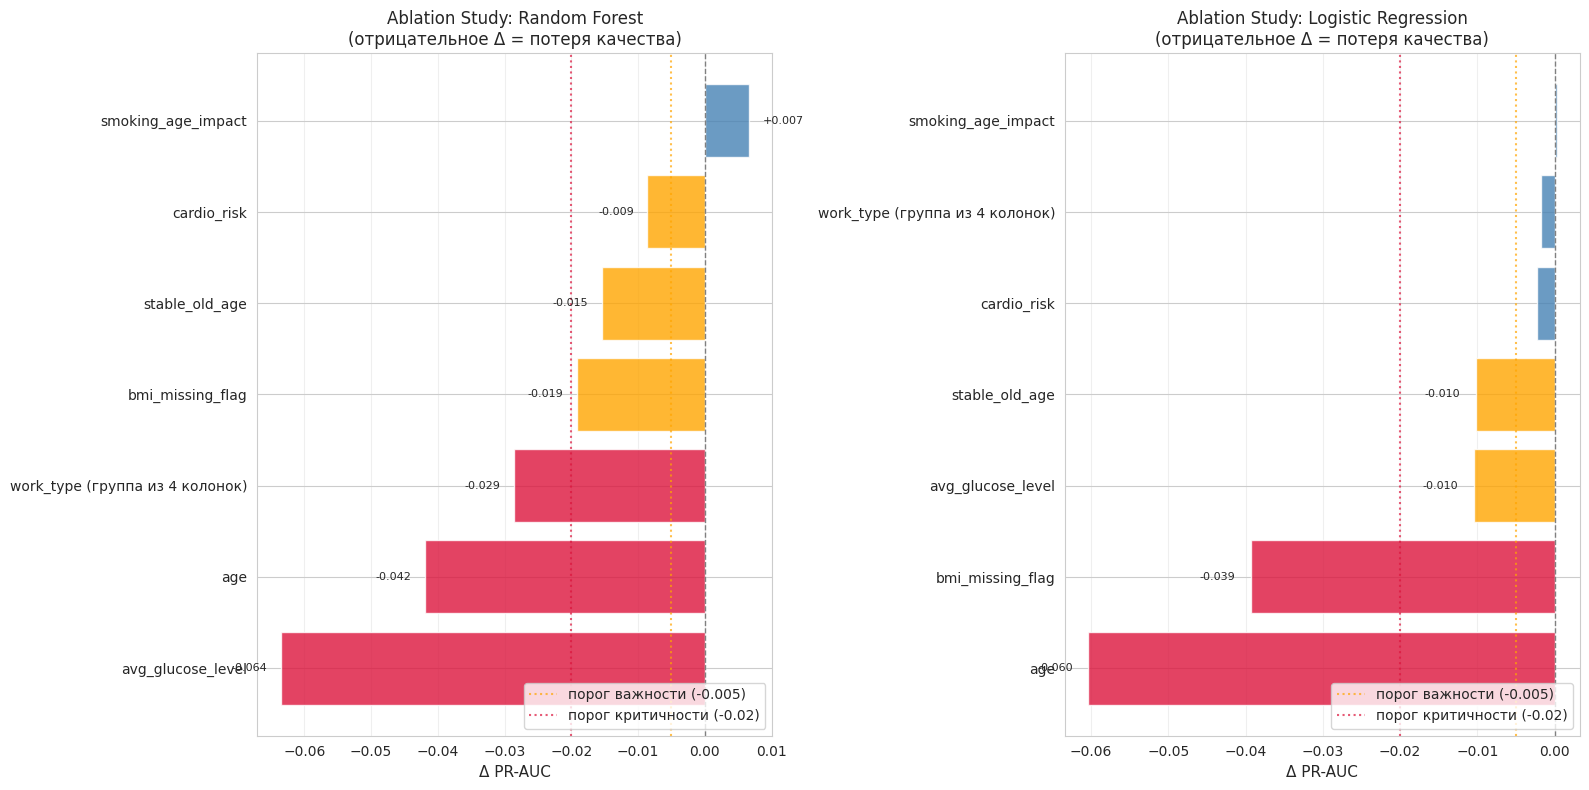


✓ График сохранён: plots/ablation_study.png

✓ Ablation Study завершён



In [ ]:
# 9.1 ABLATION STUDY (С АВТО-РАСКРЫТИЕМ ONE-HOT В КАСТОМНЫХ ГРУППАХ)

print("\n" + "="*60)
print("🔬 ABLATION STUDY: АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")
print("="*60)

if X_train is None or y_train is None:
    print("\n⚠️ Данные не загружены. Пропускаем.")
else:
    # Загружаем настройки
    cv_folds = ABLATION_CV_FOLDS if 'ABLATION_CV_FOLDS' in globals() else 5
    scoring = ABLATION_SCORING if 'ABLATION_SCORING' in globals() else 'average_precision'
    random_state = ABLATION_RANDOM_STATE if 'ABLATION_RANDOM_STATE' in globals() else 172

    onehot_mode = ABLATION_ONEHOT_MODE if 'ABLATION_ONEHOT_MODE' in globals() else 'whole'
    analyze_groups = ABLATION_ANALYZE_GROUPS if 'ABLATION_ANALYZE_GROUPS' in globals() else False

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    print(f"\n⚙️ НАСТРОЙКИ:")
    print(f"   One-hot режим: {'каждую колонку отдельно' if onehot_mode == 'separate' else 'целиком (все колонки группы)'}")
    print(f"   Кастомные группы: {'✅ включены' if analyze_groups else '❌ выключены'}")

    # ============================================
    # ФУНКЦИЯ ДЛЯ ABLATION
    # ============================================
    def run_ablation(X_data, y_data, model, model_name, onehot_mode, analyze_groups):
        """Запускает ablation study на данных"""

        X_abl = X_data.copy()

        # Только числовые колонки
        numeric_cols = X_abl.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
        X_abl = X_abl[numeric_cols]
        print(f"\n📊 {model_name}: {X_abl.shape[1]} числовых признаков")

        # ============================================
        # ПОЛУЧАЕМ ONE-HOT ГРУППЫ ИЗ ENCODERS (если доступны)
        # ============================================
        one_hot_groups_from_encoders = {}
        if 'encoders' in globals() and encoders:
            for col, info in encoders.items():
                if info.get('method') == 'one_hot':
                    one_hot_groups_from_encoders[col] = info.get('columns', [])

        # Определяем one-hot группы (для режима 'whole')
        one_hot_groups = {}
        if onehot_mode == 'whole':
            # Сначала пробуем взять из encoders
            if one_hot_groups_from_encoders:
                for prefix, group_cols in one_hot_groups_from_encoders.items():
                    # Проверяем, что все колонки группы существуют
                    existing_cols = [c for c in group_cols if c in X_abl.columns]
                    if existing_cols:
                        one_hot_groups[prefix] = existing_cols
                # Остальные колонки (не one-hot) идут в regular
                all_onehot_cols = [c for group in one_hot_groups.values() for c in group]
                regular_cols = [col for col in X_abl.columns if col not in all_onehot_cols]
            else:
                # Fallback: определяем по префиксу (старый метод)
                for col in X_abl.columns:
                    if '_' in col:
                        prefix = col.split('_')[0]
                        one_hot_groups.setdefault(prefix, []).append(col)
                one_hot_groups = {k: v for k, v in one_hot_groups.items() if len(v) > 1}
                regular_cols = [col for col in X_abl.columns
                               if not any(col.startswith(f"{p}_") for p in one_hot_groups.keys())]
        else:
            regular_cols = X_abl.columns.tolist()

        if len(numeric_cols) < 2:
            print(f"\n⚠️ Недостаточно признаков для Ablation Study (нужно ≥2)")
            return None

        # Baseline
        baseline_scores = cross_val_score(model, X_abl, y_data, cv=cv, scoring=scoring)
        baseline_pr_auc = baseline_scores.mean()
        print(f"\n📊 Baseline PR-AUC: {baseline_pr_auc:.4f} ± {baseline_scores.std():.4f}")

        ablation_results = []

        # ========================================
        # 1. ОТДЕЛЬНЫЕ ПРИЗНАКИ
        # ========================================
        if onehot_mode == 'separate':
            print("\n🔬 1. Отдельные признаки (удаление по одному):")
            for feature in regular_cols:
                X_reduced = X_abl.drop(columns=[feature])
                scores = cross_val_score(model, X_reduced, y_data, cv=cv, scoring=scoring)
                pr_auc = scores.mean()
                delta = pr_auc - baseline_pr_auc

                ablation_results.append({
                    'Признак': feature,
                    'PR-AUC': pr_auc,
                    'Δ': delta,
                    'Важность': '🔴 КРИТИЧНЫЙ' if delta < -0.02 else ('🟡 ВАЖНЫЙ' if delta < -0.005 else '🟢 МОЖНО УДАЛИТЬ')
                })

                if delta < -0.02:
                    print(f"   🔴 {feature}: Δ={delta:+.4f} — КРИТИЧНЫЙ!")
                elif delta < -0.005:
                    print(f"   🟡 {feature}: Δ={delta:+.4f} — важный")
                else:
                    print(f"   🟢 {feature}: Δ={delta:+.4f} — можно удалить")

        else:  # onehot_mode == 'whole'
            # Обычные признаки (по одному)
            print("\n🔬 1. Обычные признаки (удаление по одному):")
            for feature in regular_cols:
                X_reduced = X_abl.drop(columns=[feature])
                scores = cross_val_score(model, X_reduced, y_data, cv=cv, scoring=scoring)
                pr_auc = scores.mean()
                delta = pr_auc - baseline_pr_auc

                ablation_results.append({
                    'Признак': feature,
                    'PR-AUC': pr_auc,
                    'Δ': delta,
                    'Важность': '🔴 КРИТИЧНЫЙ' if delta < -0.02 else ('🟡 ВАЖНЫЙ' if delta < -0.005 else '🟢 МОЖНО УДАЛИТЬ')
                })

                if delta < -0.02:
                    print(f"   🔴 {feature}: Δ={delta:+.4f} — КРИТИЧНЫЙ!")
                elif delta < -0.005:
                    print(f"   🟡 {feature}: Δ={delta:+.4f} — важный")
                else:
                    print(f"   🟢 {feature}: Δ={delta:+.4f} — можно удалить")

            # One-hot группы (удаляем целиком)
            if one_hot_groups:
                print("\n🔬 2. One-hot группы (удаление целиком):")
                for prefix, group_cols in one_hot_groups.items():
                    X_reduced = X_abl.drop(columns=group_cols)
                    scores = cross_val_score(model, X_reduced, y_data, cv=cv, scoring=scoring)
                    pr_auc = scores.mean()
                    delta = pr_auc - baseline_pr_auc

                    ablation_results.append({
                        'Признак': f"{prefix} (группа из {len(group_cols)} колонок)",
                        'PR-AUC': pr_auc,
                        'Δ': delta,
                        'Важность': '🔴 КРИТИЧНЫЙ' if delta < -0.02 else ('🟡 ВАЖНЫЙ' if delta < -0.005 else '🟢 МОЖНО УДАЛИТЬ')
                    })

                    if delta < -0.02:
                        print(f"   🔴 {prefix}: Δ={delta:+.4f} — КРИТИЧНЫЙ!")
                    elif delta < -0.005:
                        print(f"   🟡 {prefix}: Δ={delta:+.4f} — важный")
                    else:
                        print(f"   🟢 {prefix}: Δ={delta:+.4f} — можно удалить")

        # ========================================
        # 2. КАСТОМНЫЕ ГРУППЫ (ТИХИЙ РЕЖИМ)
        # ========================================
        if analyze_groups and 'ABLATION_FEATURE_GROUPS' in globals() and ABLATION_FEATURE_GROUPS:
            print("\n🔬 3. Кастомные группы (удаление целиком):")
            for group_name, group_cols in ABLATION_FEATURE_GROUPS.items():
                existing_cols = []

                for col in group_cols:
                    if col in X_abl.columns:
                        existing_cols.append(col)
                    else:
                        onehot_cols = [c for c in X_abl.columns if c.startswith(f"{col}_")]
                        if onehot_cols:
                            existing_cols.extend(onehot_cols)

                existing_cols = list(set(existing_cols))

                if not existing_cols:
                    print(f"   ⚠️ {group_name}: нет колонок для удаления")
                    continue

                X_reduced = X_abl.drop(columns=existing_cols)
                scores = cross_val_score(model, X_reduced, y_data, cv=cv, scoring=scoring)
                pr_auc = scores.mean()
                delta = pr_auc - baseline_pr_auc

                ablation_results.append({
                    'Признак': f"[ГРУППА] {group_name} ({len(existing_cols)} колонок)",
                    'PR-AUC': pr_auc,
                    'Δ': delta,
                    'Важность': '🔴 КРИТИЧНЫЙ' if delta < -0.02 else ('🟡 ВАЖНЫЙ' if delta < -0.005 else '🟢 МОЖНО УДАЛИТЬ')
                })

                if delta < -0.02:
                    print(f"   🔴 {group_name}: Δ={delta:+.4f} — КРИТИЧНАЯ ГРУППА!")
                elif delta < -0.005:
                    print(f"   🟡 {group_name}: Δ={delta:+.4f} — важная группа")
                else:
                    print(f"   🟢 {group_name}: Δ={delta:+.4f} — группу можно удалить")

        return pd.DataFrame(ablation_results).sort_values('Δ')

    # ============================================
    # 1. ABLATION ДЛЯ ДЕРЕВЬЕВ (X_train_encoded)
    # ============================================
    print("\n" + "="*60)
    print("🌲 ABLATION ДЛЯ ДЕРЕВЬЕВ (RandomForest на X_train_encoded)")
    print("="*60)

    if 'X_train_encoded' in globals() and X_train_encoded is not None:
        rf_model = RandomForestClassifier(
            n_estimators=100,
            random_state=random_state,
            n_jobs=-1,
            class_weight='balanced'
        )

        df_tree = run_ablation(X_train_encoded, y_train, rf_model, "RandomForest", onehot_mode, analyze_groups)

        if df_tree is not None:
            df_tree.to_csv(os.path.join(EDA_REPORTS_PATH, 'ablation_study_tree.csv'), index=False)
            print(f"\n✓ Результаты сохранены: reports/ablation_study_tree.csv")
    else:
        print("\n⚠️ X_train_encoded не найден — пропускаем")

    # ============================================
    # 2. ABLATION ДЛЯ ЛИНЕЙНЫХ МОДЕЛЕЙ (X_train_scaled)
    # ============================================
    print("\n" + "="*60)
    print("📐 ABLATION ДЛЯ ЛИНЕЙНЫХ МОДЕЛЕЙ (LogisticRegression на X_train_scaled)")
    print("="*60)

    if 'X_train_scaled' in globals() and X_train_scaled is not None:
        lr_model = LogisticRegression(
            class_weight='balanced',
            random_state=random_state,
            max_iter=5000,
            C=1.0
        )

        df_linear = run_ablation(X_train_scaled, y_train, lr_model, "LogisticRegression", onehot_mode, analyze_groups)

        if df_linear is not None:
            df_linear.to_csv(os.path.join(EDA_REPORTS_PATH, 'ablation_study_linear.csv'), index=False)
            print(f"\n✓ Результаты сохранены: reports/ablation_study_linear.csv")
    else:
        print("\n⚠️ X_train_scaled не найден — пропускаем")


    # ============================================
    # ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
    # ============================================
    print("\n" + "="*60)
    print("📊 ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ABLATION STUDY")
    print("="*60)

    # Определяем пути к файлам (даже если текстовый отчёт удалён)
    tree_path = os.path.join(EDA_REPORTS_PATH, 'ablation_study_tree.csv')
    linear_path = os.path.join(EDA_REPORTS_PATH, 'ablation_study_linear.csv')

    df_tree_viz = pd.read_csv(tree_path) if os.path.exists(tree_path) else None
    df_linear_viz = pd.read_csv(linear_path) if os.path.exists(linear_path) else None

    if df_tree_viz is not None or df_linear_viz is not None:
        fig, axes = plt.subplots(1, 2, figsize=(16, max(8, len(df_tree_viz) * 0.3 if df_tree_viz is not None else 6)))

        # График для деревьев
        if df_tree_viz is not None and len(df_tree_viz) > 0:
            df_tree_viz = df_tree_viz.sort_values('Δ', ascending=True)

            colors = ['crimson' if d < -0.02 else ('orange' if d < -0.005 else 'steelblue')
                     for d in df_tree_viz['Δ']]

            axes[0].barh(df_tree_viz['Признак'], df_tree_viz['Δ'], color=colors, alpha=0.8)
            axes[0].axvline(x=0, color='gray', linestyle='--', linewidth=1)
            axes[0].axvline(x=-0.005, color='orange', linestyle=':', alpha=0.7, linewidth=1.5, label='порог важности (-0.005)')
            axes[0].axvline(x=-0.02, color='crimson', linestyle=':', alpha=0.7, linewidth=1.5, label='порог критичности (-0.02)')
            axes[0].set_xlabel('Δ PR-AUC', fontsize=11)
            axes[0].set_title('Ablation Study: Random Forest\n(отрицательное Δ = потеря качества)', fontsize=12)
            axes[0].legend(loc='lower right')
            axes[0].grid(axis='x', alpha=0.3)

            for i, (_, row) in enumerate(df_tree_viz.iterrows()):
                if abs(row['Δ']) > 0.005:
                    x_offset = 0.002 if row['Δ'] >= 0 else -0.002
                    ha = 'left' if row['Δ'] >= 0 else 'right'
                    axes[0].text(row['Δ'] + x_offset, i, f"{row['Δ']:+.3f}", va='center', ha=ha, fontsize=8)
        else:
            axes[0].text(0.5, 0.5, 'Нет данных для Random Forest', ha='center', va='center', transform=axes[0].transAxes)
            axes[0].set_title('Ablation Study: Random Forest')

        # График для линейных моделей
        if df_linear_viz is not None and len(df_linear_viz) > 0:
            df_linear_viz = df_linear_viz.sort_values('Δ', ascending=True)

            colors = ['crimson' if d < -0.02 else ('orange' if d < -0.005 else 'steelblue')
                     for d in df_linear_viz['Δ']]

            axes[1].barh(df_linear_viz['Признак'], df_linear_viz['Δ'], color=colors, alpha=0.8)
            axes[1].axvline(x=0, color='gray', linestyle='--', linewidth=1)
            axes[1].axvline(x=-0.005, color='orange', linestyle=':', alpha=0.7, linewidth=1.5, label='порог важности (-0.005)')
            axes[1].axvline(x=-0.02, color='crimson', linestyle=':', alpha=0.7, linewidth=1.5, label='порог критичности (-0.02)')
            axes[1].set_xlabel('Δ PR-AUC', fontsize=11)
            axes[1].set_title('Ablation Study: Logistic Regression\n(отрицательное Δ = потеря качества)', fontsize=12)
            axes[1].legend(loc='lower right')
            axes[1].grid(axis='x', alpha=0.3)

            for i, (_, row) in enumerate(df_linear_viz.iterrows()):
                if abs(row['Δ']) > 0.005:
                    x_offset = 0.002 if row['Δ'] >= 0 else -0.002
                    ha = 'left' if row['Δ'] >= 0 else 'right'
                    axes[1].text(row['Δ'] + x_offset, i, f"{row['Δ']:+.3f}", va='center', ha=ha, fontsize=8)
        else:
            axes[1].text(0.5, 0.5, 'Нет данных для Logistic Regression', ha='center', va='center', transform=axes[1].transAxes)
            axes[1].set_title('Ablation Study: Logistic Regression')

        plt.tight_layout()
        plot_path = os.path.join(EDA_PLOTS_PATH, 'ablation_study.png')
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\n✓ График сохранён: plots/ablation_study.png")
    else:
        print("\n⚠️ Нет данных для визуализации")

print("\n" + "="*60)
print("✓ Ablation Study завершён")
print("="*60 + "\n")


🌲 RANDOM FOREST: АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ

📊 ЧАСТЬ 1: ПОДГОТОВКА ДАННЫХ
----------------------------------------

✓ Подготовлено признаков для RF: 10
   Всего признаков в X_train_encoded: 10

✅ NaN в данных для RF отсутствуют

📊 Размер данных для RF: (3031, 10)
   Целевая переменная: (3031,)


📊 ЧАСТЬ 2: ОЦЕНКА ВАЖНОСТИ ПРИЗНАКОВ
----------------------------------------

📊 RandomForestClassifier
   n_estimators=100, class_weight=balanced, random_state=99

⏳ Обучение модели...
   ✓ Модель обучена

📊 Суммарная важность: 1.0000

📋 Распределение важности:
   🟡 Средняя (0.01-0.05): 5 признаков
   🟢 Высокая (>0.05): 4 признаков
   🔴 Низкая (<0.01): 1 признаков

🏆 ТОП-5 ПРИЗНАКОВ:
   1. age: 0.3917 (39.2%)
   2. avg_glucose_level: 0.2979 (29.8%)
   3. smoking_age_impact: 0.1143 (11.4%)
   4. stable_old_age: 0.0789 (7.9%)
   5. cardio_risk: 0.0347 (3.5%)

🔴 Признаки с низкой важностью (<0.01) (1):
   • work_type_never_worked: 0.0001

📈 Накопленная важность:
   50% важности: 2 признаков
   80

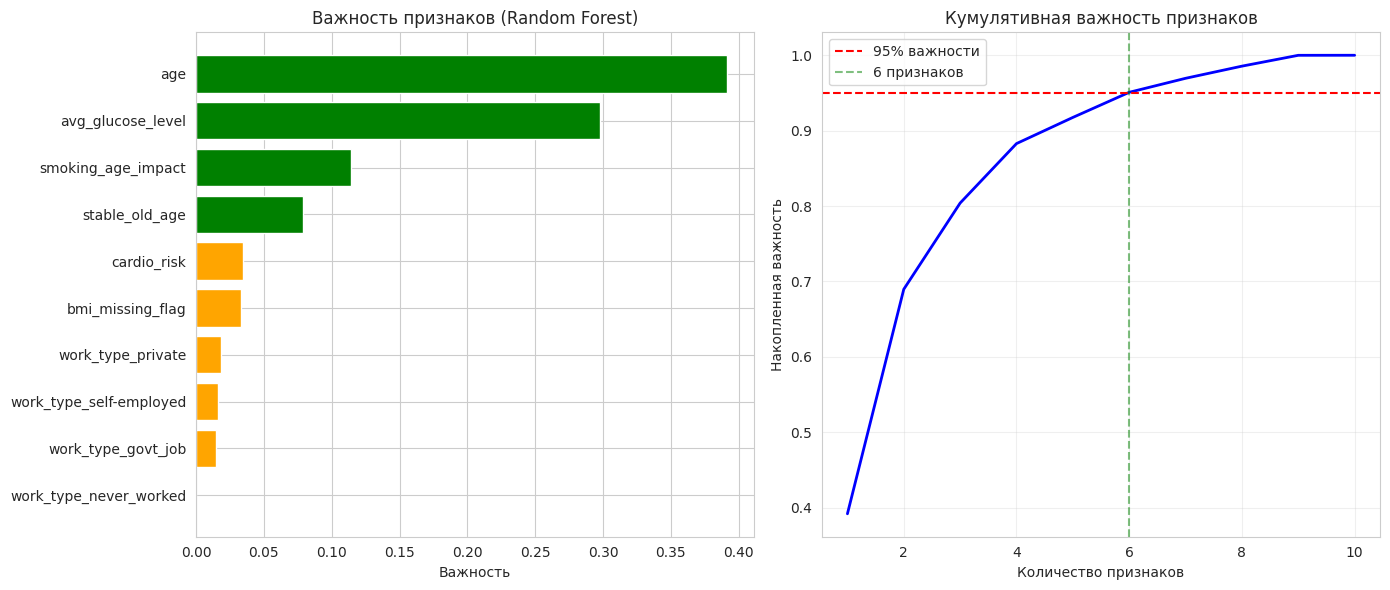


✓ График сохранён: plots/feature_importance_rf.png
✓ Модель сохранена: transformers/random_forest_importance.pkl
✓ Таблица важности сохранена: reports/feature_importance_rf.csv

✓ Random Forest анализ завершён



In [ ]:
# 9.2 RANDOM FOREST: ПОДГОТОВКА ДАННЫХ + ОЦЕНКА ВАЖНОСТИ

print("\n" + "="*60)
print("🌲 RANDOM FOREST: АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")
print("="*60)

# ============================================
# ЧАСТЬ 1: ПОДГОТОВКА ДАННЫХ
# ============================================
print("\n📊 ЧАСТЬ 1: ПОДГОТОВКА ДАННЫХ")
print("-"*40)

if X_train is None or y_train is None:
    print("\n⚠️ Данные не загружены. Пропускаем.")
    X_rf = None
else:
    # Проверяем, есть ли закодированные данные
    if 'X_train_encoded' not in globals() or X_train_encoded is None:
        print("\n❌ X_train_encoded не найден!")
        print("   Random Forest требует числовые признаки.")
        print("   Сначала выполните блок 7.1 (Кодирование категориальных признаков).")
        X_rf = None
    else:
        # Все возможные числовые типы
        numeric_types = ['int16', 'int32', 'int64', 'Int64',
                         'float16', 'float32', 'float64',
                         'uint8', 'uint16', 'uint32', 'uint64',
                         'bool']

        numeric_cols_for_rf = X_train_encoded.select_dtypes(include=numeric_types).columns.tolist()
        X_rf = X_train_encoded[numeric_cols_for_rf].copy()

        print(f"\n✓ Подготовлено признаков для RF: {X_rf.shape[1]}")
        print(f"   Всего признаков в X_train_encoded: {X_train_encoded.shape[1]}")

        # Исключённые колонки
        excluded = set(X_train_encoded.columns) - set(numeric_cols_for_rf)
        if excluded:
            print(f"\n⚠️ Исключены (не числовые):")
            for col in sorted(excluded):
                print(f"   • {col} ({X_train_encoded[col].dtype})")
            print(f"\n💡 Проверьте encoding_config - эти колонки не были закодированы!")

        # Проверка на NaN
        nan_count = X_rf.isnull().sum().sum()
        if nan_count > 0:
            print(f"\n❌ В данных для RF обнаружены NaN: {nan_count}")
            print("   Random Forest НЕ РАБОТАЕТ с пропусками!")

            # Показываем колонки с NaN
            nan_cols = X_rf.columns[X_rf.isnull().any()].tolist()
            print(f"\n   Колонки с NaN ({len(nan_cols)}):")
            for col in nan_cols[:10]:
                count = X_rf[col].isnull().sum()
                pct = count / len(X_rf) * 100
                print(f"      • {col}: {count} ({pct:.1f}%)")
            if len(nan_cols) > 10:
                print(f"      ... и ещё {len(nan_cols) - 10}")

            print(f"\n💡 Рекомендации:")
            print("   • Вернитесь к блоку 3.3 и обработайте пропуски")
            print("   • Или заполните NaN медианой/модой")
            print("   • Или удалите строки/колонки с пропусками")

            X_rf = None
        else:
            print(f"\n✅ NaN в данных для RF отсутствуют")
            print(f"\n📊 Размер данных для RF: {X_rf.shape}")
            print(f"   Целевая переменная: {y_train.shape}")

print("\n" + "="*60)

# ============================================
# ЧАСТЬ 2: ОЦЕНКА ВАЖНОСТИ ПРИЗНАКОВ
# ============================================
print("\n📊 ЧАСТЬ 2: ОЦЕНКА ВАЖНОСТИ ПРИЗНАКОВ")
print("-"*40)

if 'X_rf' not in locals() or X_rf is None:
    print("\n⚠️ X_rf не найден. Пропускаем обучение.")
elif y_train is None:
    print("\n⚠️ y_train не загружен.")
else:
    # Определяем параметры
    n_estimators = RF_N_ESTIMATORS if 'RF_N_ESTIMATORS' in globals() else 100
    random_state = RANDOM_STATE if 'RANDOM_STATE' in globals() else 42

    # Выбор модели
    if TASK_TYPE == 'classification':
        rf = RandomForestClassifier(
            n_estimators=n_estimators,
            random_state=random_state,
            n_jobs=-1,
            class_weight=RF_CLASS_WEIGHT
        )
        print(f"\n📊 RandomForestClassifier")
        print(f"   n_estimators={n_estimators}, class_weight={RF_CLASS_WEIGHT}, random_state={random_state}")
    else:
        rf = RandomForestRegressor(
            n_estimators=n_estimators,
            random_state=random_state,
            n_jobs=-1
        )
        print(f"\n📊 RandomForestRegressor")
        print(f"   n_estimators={n_estimators}, random_state={random_state}")

    # Обучение
    print("\n⏳ Обучение модели...")
    rf.fit(X_rf, y_train)
    print("   ✓ Модель обучена")

    # Важность признаков
    feature_importance = pd.DataFrame({
        'Признак': X_rf.columns,
        'Важность': rf.feature_importances_
    }).sort_values('Важность', ascending=False).reset_index(drop=True)

    feature_importance['Накопленная'] = feature_importance['Важность'].cumsum()

    # Суммарная важность
    total_importance = feature_importance['Важность'].sum()
    print(f"\n📊 Суммарная важность: {total_importance:.4f}")

    # Категории важности
    feature_importance['Категория'] = feature_importance['Важность'].apply(lambda x:
        '🟢 Высокая (>0.05)' if x > 0.05 else
        ('🟡 Средняя (0.01-0.05)' if x >= 0.01 else '🔴 Низкая (<0.01)'))

    category_counts = feature_importance['Категория'].value_counts()

    print(f"\n📋 Распределение важности:")
    for cat, count in category_counts.items():
        print(f"   {cat}: {count} признаков")

    # Топ-признаки
    print(f"\n🏆 ТОП-5 ПРИЗНАКОВ:")
    for i, (_, row) in enumerate(feature_importance.head(5).iterrows(), 1):
        pct = row['Важность'] / total_importance * 100
        print(f"   {i}. {row['Признак']}: {row['Важность']:.4f} ({pct:.1f}%)")

    # Признаки с нулевой важностью
    zero_importance = feature_importance[feature_importance['Важность'] == 0]
    if len(zero_importance) > 0:
        print(f"\n⚠️ Признаки с НУЛЕВОЙ важностью ({len(zero_importance)}):")
        for _, row in zero_importance.iterrows():
            print(f"   • {row['Признак']}")
        print(f"\n   💡 Эти признаки НЕ влияют на модель — кандидаты на удаление")

        # Сохраняем список для возможного использования
        zero_importance_list = zero_importance['Признак'].tolist()
        print(f"\n📝 Для удаления (при желании):")
        print(f"   features_to_drop_rf = {zero_importance_list}")

    # Признаки с низкой важностью
    low_importance = feature_importance[(feature_importance['Важность'] > 0) & (feature_importance['Важность'] < 0.01)]
    if len(low_importance) > 0:
        print(f"\n🔴 Признаки с низкой важностью (<0.01) ({len(low_importance)}):")
        for _, row in low_importance.head(10).iterrows():
            print(f"   • {row['Признак']}: {row['Важность']:.4f}")
        if len(low_importance) > 10:
            print(f"   ... и ещё {len(low_importance) - 10}")

    # Накопленная важность
    print(f"\n📈 Накопленная важность:")

    thresholds = [0.5, 0.8, 0.9, 0.95]
    for thresh in thresholds:
        mask = feature_importance['Накопленная'] >= thresh
        if mask.any():
            n_features = mask.idxmax() + 1
        else:
            n_features = len(feature_importance)
        pct = int(thresh * 100)
        print(f"   {pct}% важности: {n_features} признаков")

    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # График 1: важность признаков
    colors = ['green' if x > 0.05 else ('orange' if x >= 0.01 else 'red') for x in feature_importance['Важность']]
    axes[0].barh(range(len(feature_importance)), feature_importance['Важность'].values, color=colors)
    axes[0].set_yticks(range(len(feature_importance)))
    axes[0].set_yticklabels(feature_importance['Признак'].values)
    axes[0].set_xlabel('Важность')
    axes[0].set_title('Важность признаков (Random Forest)')
    axes[0].invert_yaxis()

    # График 2: кумулятивная важность
    axes[1].plot(range(1, len(feature_importance) + 1),
                 feature_importance['Накопленная'].values,
                 'b-', linewidth=2)
    axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% важности')
    axes[1].set_xlabel('Количество признаков')
    axes[1].set_ylabel('Накопленная важность')
    axes[1].set_title('Кумулятивная важность признаков')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Количество признаков для 95% важности
    mask_95 = feature_importance['Накопленная'] >= 0.95
    n_95 = mask_95.idxmax() + 1 if mask_95.any() else len(feature_importance)
    axes[1].axvline(x=n_95, color='g', linestyle='--', alpha=0.5, label=f'{n_95} признаков')
    axes[1].legend()

    plt.tight_layout()
    plot_path = os.path.join(EDA_PLOTS_PATH, 'feature_importance_rf.png')
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✓ График сохранён: plots/feature_importance_rf.png")

    # Сохраняем модель и важность
    model_path = os.path.join(EDA_TRANSFORMERS_PATH, 'random_forest_importance.pkl')
    joblib.dump(rf, model_path)
    print(f"✓ Модель сохранена: transformers/random_forest_importance.pkl")

    # Сохраняем таблицу важности
    importance_path = os.path.join(EDA_REPORTS_PATH, 'feature_importance_rf.csv')
    feature_importance.to_csv(importance_path, index=False)
    print(f"✓ Таблица важности сохранена: reports/feature_importance_rf.csv")

print("\n" + "="*60)
print("✓ Random Forest анализ завершён")
print("="*60 + "\n")

# ОТЧЕТ И ВАЛИДАЦИЯ

In [ ]:
# 10.1 ИТОГОВЫЙ ОТЧЁТ EDA

print("\n" + "="*50)
print("📋 ИТОГОВЫЙ ОТЧЁТ EDA")
print("="*50)

# Собираем отчёт в список для сохранения
report_lines = []
report_lines.append("=" * 60)
report_lines.append("ИТОГОВЫЙ ОТЧЁТ EDA")
report_lines.append("=" * 60)
report_lines.append(f"Проект: {PROJECT_NAME}")
report_lines.append(f"Цикл: {CYCLE_NUMBER}")
report_lines.append(f"Дата: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
report_lines.append("")

print("\n📊 ИТОГИ ОБРАБОТКИ:")
print("-" * 40)
report_lines.append("ИТОГИ ОБРАБОТКИ:")
report_lines.append("-" * 40)

# ============================================
# Исходная форма (улучшенная проверка)
# ============================================
if 'original_shape' in globals() and original_shape is not None:
    print(f"   Исходный X_train: {original_shape[0]} × {original_shape[1]}")
    report_lines.append(f"   Исходный X_train: {original_shape[0]} × {original_shape[1]}")
elif 'metadata' in globals() and metadata and 'feature_count' in metadata:
    print(f"   Исходный X_train: форма из metadata: {metadata.get('train_size', '?')} × {metadata.get('feature_count', '?')}")
    report_lines.append(f"   Исходный X_train: {metadata.get('train_size', '?')} × {metadata.get('feature_count', '?')}")
else:
    print(f"   Исходный X_train: форма не сохранена")
    report_lines.append(f"   Исходный X_train: форма не сохранена")

# ============================================
# Финальная форма
# ============================================
if 'X_train_scaled' in globals() and X_train_scaled is not None:
    final_df = X_train_scaled
    final_name = "X_train_scaled"
elif 'X_train_encoded' in globals() and X_train_encoded is not None:
    final_df = X_train_encoded
    final_name = "X_train_encoded"
else:
    final_df = X_train
    final_name = "X_train"

print(f"   Финальный {final_name}: {final_df.shape[0]} × {final_df.shape[1]}")
print(f"   Тип задачи: {TASK_TYPE.upper()}")
print(f"   Random state: {RANDOM_STATE}")
report_lines.append(f"   Финальный {final_name}: {final_df.shape[0]} × {final_df.shape[1]}")
report_lines.append(f"   Тип задачи: {TASK_TYPE.upper()}")
report_lines.append(f"   Random state: {RANDOM_STATE}")
report_lines.append("")

print("\n🔧 ПРИМЕНЁННЫЕ ТРАНСФОРМАЦИИ:")
print("-" * 40)
report_lines.append("ПРИМЕНЁННЫЕ ТРАНСФОРМАЦИИ:")
report_lines.append("-" * 40)

# Масштабирование
if 'scalers' in globals() and scalers:
    print(f"   ✅ Масштабирование ({len(scalers)} колонок):")
    report_lines.append(f"   ✅ Масштабирование ({len(scalers)} колонок):")
    for col, scaler in scalers.items():
        scaler_name = type(scaler).__name__
        print(f"      - {col}: {scaler_name}")
        report_lines.append(f"      - {col}: {scaler_name}")
elif 'scaling_config' in globals() and scaling_config:
    active_scaling = {c: m for c, (m, _) in scaling_config.items() if m != 'none'}
    if active_scaling:
        print(f"   ✅ Масштабирование ({len(active_scaling)} колонок):")
        report_lines.append(f"   ✅ Масштабирование ({len(active_scaling)} колонок):")
        for col, method in active_scaling.items():
            print(f"      - {col}: {method.upper()}")
            report_lines.append(f"      - {col}: {method.upper()}")
    else:
        print("   ⚠️ Масштабирование не применялось")
        report_lines.append("   ⚠️ Масштабирование не применялось")
else:
    print("   ⚠️ Масштабирование не применялось")
    report_lines.append("   ⚠️ Масштабирование не применялось")

# Кодирование
if 'encoders' in globals() and encoders:
    print(f"   ✅ Кодирование ({len(encoders)} колонок):")
    report_lines.append(f"   ✅ Кодирование ({len(encoders)} колонок):")
    for col, info in encoders.items():
        method = info['method'].upper()
        print(f"      - {col}: {method}")
        report_lines.append(f"      - {col}: {method}")
elif 'encoding_config' in globals() and encoding_config:
    active_encoding = {c: m for c, (m, _) in encoding_config.items() if m != 'none'}
    if active_encoding:
        print(f"   ✅ Кодирование ({len(active_encoding)} колонок):")
        report_lines.append(f"   ✅ Кодирование ({len(active_encoding)} колонок):")
        for col, method in active_encoding.items():
            print(f"      - {col}: {method.upper()}")
            report_lines.append(f"      - {col}: {method.upper()}")
    else:
        print("   ⚠️ Кодирование не применялось")
        report_lines.append("   ⚠️ Кодирование не применялось")
else:
    print("   ⚠️ Кодирование не применялось")
    report_lines.append("   ⚠️ Кодирование не применялось")

# Удаление колонок
total_dropped = 0
if 'columns_to_drop_final' in globals() and columns_to_drop_final:
    total_dropped += len(columns_to_drop_final)
if 'features_to_drop' in globals() and features_to_drop:
    total_dropped += len(features_to_drop)
if 'features_to_drop_rf' in globals() and features_to_drop_rf:
    total_dropped += len(features_to_drop_rf)

if total_dropped > 0:
    print(f"   🗑️ Удалено колонок: {total_dropped}")
    report_lines.append(f"   🗑️ Удалено колонок: {total_dropped}")

report_lines.append("")

print("\n📁 СОХРАНЁННЫЕ ФАЙЛЫ:")
print("-" * 40)
report_lines.append("СОХРАНЁННЫЕ ФАЙЛЫ:")
report_lines.append("-" * 40)

if 'X_train_encoded' in globals() and X_train_encoded is not None:
    print(f"   - Для деревьев: {EDA_DATA_PATH}/X_train_encoded.csv")
    report_lines.append(f"   - Для деревьев: {EDA_DATA_PATH}/X_train_encoded.csv")
if 'X_train_scaled' in globals() and X_train_scaled is not None:
    print(f"   - Для линейных моделей: {EDA_DATA_PATH}/X_train_scaled.csv")
    report_lines.append(f"   - Для линейных моделей: {EDA_DATA_PATH}/X_train_scaled.csv")
if os.path.exists(os.path.join(EDA_DATA_PATH, 'X_val_scaled.csv')):
    print(f"   - Val/Test: {EDA_DATA_PATH}/X_val_scaled.csv, {EDA_DATA_PATH}/X_test_scaled.csv")
    report_lines.append(f"   - Val/Test: {EDA_DATA_PATH}/X_val_scaled.csv, {EDA_DATA_PATH}/X_test_scaled.csv")

print(f"   - Метаданные: {EDA_PATH}/")
print(f"   - Графики: {EDA_PLOTS_PATH}/")
print(f"   - Трансформеры: {EDA_TRANSFORMERS_PATH}/")
report_lines.append(f"   - Метаданные: {EDA_PATH}/")
report_lines.append(f"   - Графики: {EDA_PLOTS_PATH}/")
report_lines.append(f"   - Трансформеры: {EDA_TRANSFORMERS_PATH}/")
report_lines.append("")

print("\n📊 СТАТИСТИКА ФИНАЛЬНЫХ ДАННЫХ:")
print("-" * 40)
report_lines.append("СТАТИСТИКА ФИНАЛЬНЫХ ДАННЫХ:")
report_lines.append("-" * 40)

num_count = final_df.select_dtypes(include=['int64', 'Int64', 'float64', 'uint8', 'bool']).shape[1]
cat_count = final_df.select_dtypes(include=['object', 'category']).shape[1]
null_count = final_df.isnull().sum().sum()

print(f"   Числовых колонок: {num_count}")
print(f"   Категориальных колонок: {cat_count}")
print(f"   Пропуски: {null_count}")
report_lines.append(f"   Числовых колонок: {num_count}")
report_lines.append(f"   Категориальных колонок: {cat_count}")
report_lines.append(f"   Пропуски: {null_count}")
report_lines.append("")

print("\n" + "="*50)
print("✅ EDA ЗАВЕРШЁН!")
print("="*50)
report_lines.append("=" * 60)
report_lines.append("EDA ЗАВЕРШЁН")
report_lines.append("=" * 60)

print("\n🎯 СЛЕДУЮЩИЕ ШАГИ (ОБУЧЕНИЕ МОДЕЛИ):")
print("-" * 40)
report_lines.append("СЛЕДУЮЩИЕ ШАГИ:")
report_lines.append("-" * 40)

print(f"   1. Для Random Forest / XGBoost:")
print(f"      → {EDA_DATA_PATH}/X_train_encoded.csv + {EDA_DATA_PATH}/y_train.csv")
print(f"   2. Для линейных моделей:")
print(f"      → {EDA_DATA_PATH}/X_train_scaled.csv + {EDA_DATA_PATH}/y_train.csv")
print(f"   3. Для валидации и теста:")
print(f"      → {EDA_DATA_PATH}/X_val_scaled.csv, {EDA_DATA_PATH}/X_test_scaled.csv")
report_lines.append("   1. Для деревьев: X_train_encoded.csv + y_train.csv")
report_lines.append("   2. Для линейных: X_train_scaled.csv + y_train.csv")
report_lines.append("   3. Для валидации: X_val_scaled.csv, X_test_scaled.csv")

print("\n💡 РЕКОМЕНДАЦИИ:")
print("-" * 40)
report_lines.append("")
report_lines.append("РЕКОМЕНДАЦИИ:")
report_lines.append("-" * 40)

if TASK_TYPE == 'classification':
    print("   - Для дисбаланса: class_weight='balanced' или SMOTE")
    print("   - Метрики: PR-AUC, F1-score (не Accuracy)")
    report_lines.append("   - Для дисбаланса: class_weight='balanced' или SMOTE")
    report_lines.append("   - Метрики: ROC-AUC, F1-score (не Accuracy)")
else:
    print("   - Метрики: MAE, RMSE, R²")
    report_lines.append("   - Метрики: MAE, RMSE, R²")

print("   - Сравните деревья и линейные модели на валидации")
report_lines.append("   - Сравните деревья и линейные модели на валидации")

# ============================================
# СОХРАНЕНИЕ ОТЧЁТА В ФАЙЛ
# ============================================
report_path = os.path.join(EDA_REPORTS_PATH, 'eda_final_report.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(report_lines))

print(f"\n✓ Итоговый отчёт сохранён: {EDA_REPORTS_PATH}/eda_final_report.txt")
print("="*50 + "\n")


📋 ИТОГОВЫЙ ОТЧЁТ EDA

📊 ИТОГИ ОБРАБОТКИ:
----------------------------------------
   Исходный X_train: 3031 × 10
   Финальный X_train_scaled: 3031 × 10
   Тип задачи: CLASSIFICATION
   Random state: 99

🔧 ПРИМЕНЁННЫЕ ТРАНСФОРМАЦИИ:
----------------------------------------
   ✅ Масштабирование (3 колонок):
      - age: StandardScaler
      - avg_glucose_level: RobustScaler
      - smoking_age_impact: RobustScaler
   ✅ Кодирование (1 колонок):
      - work_type: ONE_HOT

📁 СОХРАНЁННЫЕ ФАЙЛЫ:
----------------------------------------
   - Для деревьев: /content/drive/MyDrive/ml_learning/datasets/stroke/cycle_5/eda/data/X_train_encoded.csv
   - Для линейных моделей: /content/drive/MyDrive/ml_learning/datasets/stroke/cycle_5/eda/data/X_train_scaled.csv
   - Val/Test: /content/drive/MyDrive/ml_learning/datasets/stroke/cycle_5/eda/data/X_val_scaled.csv, /content/drive/MyDrive/ml_learning/datasets/stroke/cycle_5/eda/data/X_test_scaled.csv
   - Метаданные: /content/drive/MyDrive/ml_learning/dat

In [ ]:
# 10.2 ФИНАЛЬНАЯ ВАЛИДАЦИЯ (ЧЕКАП)

print("\n" + "="*60)
print("🛡️ ФИНАЛЬНАЯ ВАЛИДАЦИЯ ДАННЫХ (ЧЕКАП)")
print("="*60)

validation_passed = True
critical_errors = []
warnings_list = []

# ============================================
# 1. ПРОВЕРКА НАЛИЧИЯ ВСЕХ ФАЙЛОВ
# ============================================
print("\n📁 1. ПРОВЕРКА НАЛИЧИЯ ФАЙЛОВ:")
print("-" * 40)

required_files = {
    'Train признаки': 'X_train_scaled.csv',
    'Train целевая': 'y_train.csv',
    'Val признаки': 'X_val_scaled.csv',
    'Val целевая': 'y_val.csv',
    'Test признаки': 'X_test_scaled.csv',
    'Test целевая': 'y_test.csv',
    'Метаданные трансформаций': 'transformations_metadata.json',
    'Production метаданные': 'production_metadata.json',
    'Энкодеры': 'encoders.pkl',
}

if 'scalers' in globals() and scalers:
    required_files['Скалеры'] = 'scalers.pkl'

missing_files = []
for name, filename in required_files.items():
    if name in ['Метаданные трансформаций', 'Production метаданные']:
        path = os.path.join(EDA_PATH, filename)
    elif name in ['Энкодеры', 'Скалеры']:
        path = os.path.join(EDA_TRANSFORMERS_PATH, filename)
    else:
        path = os.path.join(EDA_DATA_PATH, filename)

    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        print(f"   ✓ {name}: {filename} ({size:.1f} KB)")
    else:
        print(f"   ❌ {name}: {filename} НЕ НАЙДЕН")
        missing_files.append(filename)
        critical_errors.append(f"Отсутствует файл: {filename}")

if missing_files:
    validation_passed = False

# ============================================
# 2. ЗАГРУЗКА ФИНАЛЬНЫХ ДАННЫХ
# ============================================
print("\n📥 2. ЗАГРУЗКА ФИНАЛЬНЫХ ДАННЫХ:")
print("-" * 40)

try:
    # Определяем, какую версию Train использовать
    train_x_path = os.path.join(EDA_DATA_PATH, 'X_train_scaled.csv')
    if not os.path.exists(train_x_path):
        train_x_path = os.path.join(EDA_DATA_PATH, 'X_train_encoded.csv')
    if not os.path.exists(train_x_path):
        train_x_path = os.path.join(EDA_DATA_PATH, 'X_train.csv')

    train_y_path = os.path.join(EDA_DATA_PATH, 'y_train.csv')
    val_x_path = os.path.join(EDA_DATA_PATH, 'X_val_scaled.csv')
    val_y_path = os.path.join(EDA_DATA_PATH, 'y_val.csv')
    test_x_path = os.path.join(EDA_DATA_PATH, 'X_test_scaled.csv')
    test_y_path = os.path.join(EDA_DATA_PATH, 'y_test.csv')

    X_train_final = pd.read_csv(train_x_path)
    y_train_final = pd.read_csv(train_y_path).iloc[:, 0]
    X_val_final = pd.read_csv(val_x_path)
    y_val_final = pd.read_csv(val_y_path).iloc[:, 0]
    X_test_final = pd.read_csv(test_x_path)
    y_test_final = pd.read_csv(test_y_path).iloc[:, 0]

    print(f"   ✓ Train: {X_train_final.shape}")
    print(f"   ✓ Val:   {X_val_final.shape}")
    print(f"   ✓ Test:  {X_test_final.shape}")

except Exception as e:
    print(f"   ❌ Ошибка загрузки: {e}")
    validation_passed = False
    critical_errors.append(f"Ошибка загрузки данных: {e}")

# ============================================
# 3. ПРОВЕРКА КОЛОНОК (ИМЕНА И ПОРЯДОК)
# ============================================
print("\n📋 3. ПРОВЕРКА КОЛОНОК:")
print("-" * 40)

if 'X_train_final' in globals():
    train_cols = X_train_final.columns.tolist()
    val_cols = X_val_final.columns.tolist()
    test_cols = X_test_final.columns.tolist()

    if train_cols == val_cols == test_cols:
        print(f"   ✓ Колонки идентичны во всех выборках ({len(train_cols)} шт.)")
    else:
        print(f"   ❌ Колонки различаются!")
        if train_cols != val_cols:
            diff = set(train_cols) ^ set(val_cols)
            print(f"      Train vs Val: различие {diff}")
            critical_errors.append(f"Колонки Train и Val различаются: {diff}")
        if train_cols != test_cols:
            diff = set(train_cols) ^ set(test_cols)
            print(f"      Train vs Test: различие {diff}")
            critical_errors.append(f"Колонки Train и Test различаются: {diff}")
        validation_passed = False

# ============================================
# 4. ПРОВЕРКА ТИПОВ ДАННЫХ
# ============================================
print("\n🔢 4. ПРОВЕРКА ТИПОВ ДАННЫХ:")
print("-" * 40)

if 'X_train_final' in globals():
    type_mismatch = []
    for col in train_cols:
        train_dtype = X_train_final[col].dtype
        val_dtype = X_val_final[col].dtype
        test_dtype = X_test_final[col].dtype

        if train_dtype != val_dtype or train_dtype != test_dtype:
            type_mismatch.append((col, train_dtype, val_dtype, test_dtype))

    if type_mismatch:
        print(f"   ⚠️ Различаются типы в {len(type_mismatch)} колонках:")
        for col, t_d, v_d, ts_d in type_mismatch[:5]:
            print(f"      • {col}: train={t_d}, val={v_d}, test={ts_d}")
        warnings_list.append(f"Типы данных различаются в {len(type_mismatch)} колонках")
    else:
        print(f"   ✓ Типы данных совпадают во всех выборках")

# ============================================
# 5. ПРОВЕРКА НА NaN И БЕСКОНЕЧНОСТИ
# ============================================
print("\n🚫 5. ПРОВЕРКА НА NaN И INF:")
print("-" * 40)

if 'X_train_final' in globals():
    train_nan = X_train_final.isnull().sum().sum()
    val_nan = X_val_final.isnull().sum().sum()
    test_nan = X_test_final.isnull().sum().sum()
    y_nan = y_train_final.isnull().sum() + y_val_final.isnull().sum() + y_test_final.isnull().sum()

    train_inf = np.isinf(X_train_final.select_dtypes(include=['float64', 'float32']).values).sum()
    val_inf = np.isinf(X_val_final.select_dtypes(include=['float64', 'float32']).values).sum()
    test_inf = np.isinf(X_test_final.select_dtypes(include=['float64', 'float32']).values).sum()

    if train_nan == 0 and val_nan == 0 and test_nan == 0:
        print(f"   ✓ NaN отсутствуют")
    else:
        print(f"   ❌ Обнаружены NaN: Train={train_nan}, Val={val_nan}, Test={test_nan}")
        critical_errors.append(f"NaN в данных: Train={train_nan}, Val={val_nan}, Test={test_nan}")
        validation_passed = False

    if train_inf == 0 and val_inf == 0 and test_inf == 0:
        print(f"   ✓ Бесконечности отсутствуют")
    else:
        print(f"   ⚠️ Обнаружены Inf: Train={train_inf}, Val={val_inf}, Test={test_inf}")
        warnings_list.append(f"Бесконечные значения: Train={train_inf}, Val={val_inf}, Test={test_inf}")

    if y_nan == 0:
        print(f"   ✓ Целевая переменная без NaN")
    else:
        print(f"   ❌ NaN в целевой переменной: {y_nan}")
        critical_errors.append(f"NaN в целевой переменной: {y_nan}")
        validation_passed = False

# ============================================
# 6. ПРОВЕРКА НА КОНСТАНТНЫЕ ПРИЗНАКИ В VAL/TEST
# ============================================
print("\n🔒 6. КОНСТАНТНЫЕ ПРИЗНАКИ В VAL/TEST:")
print("-" * 40)

if 'X_train_final' in globals():
    constant_in_val = []
    constant_in_test = []

    for col in train_cols:
        if X_val_final[col].nunique() == 1:
            val_unique = X_val_final[col].nunique()
            train_unique = X_train_final[col].nunique()
            constant_in_val.append((col, val_unique, train_unique))

        if X_test_final[col].nunique() == 1:
            test_unique = X_test_final[col].nunique()
            train_unique = X_train_final[col].nunique()
            constant_in_test.append((col, test_unique, train_unique))

    critical_constants = []
    for col, val_uniq, train_uniq in constant_in_val:
        if train_uniq > 1:
            critical_constants.append(f"Val: {col} (train={train_uniq} значений, val=1)")

    for col, test_uniq, train_uniq in constant_in_test:
        if train_uniq > 1:
            critical_constants.append(f"Test: {col} (train={train_uniq} значений, test=1)")

    if critical_constants:
        print(f"   ❌ КРИТИЧЕСКИЙ БАГ: признаки с одним значением в Val/Test!")
        for msg in critical_constants[:5]:
            print(f"      • {msg}")
        critical_errors.extend(critical_constants)
        validation_passed = False
    else:
        print(f"   ✓ Константных признаков в Val/Test нет")

# ============================================
# 7. ПРОВЕРКА ДИАПАЗОНОВ ЗНАЧЕНИЙ
# ============================================
print("\n📊 7. ПРОВЕРКА ДИАПАЗОНОВ ЗНАЧЕНИЙ:")
print("-" * 40)

if 'X_train_final' in globals():
    range_issues = []

    for col in train_cols:
        if X_train_final[col].dtype in ['float64', 'float32', 'int64', 'int32']:
            train_min, train_max = X_train_final[col].min(), X_train_final[col].max()
            val_min, val_max = X_val_final[col].min(), X_val_final[col].max()
            test_min, test_max = X_test_final[col].min(), X_test_final[col].max()

            # Допустимое отклонение 5%
            tolerance = 0.05 * (train_max - train_min) if train_max != train_min else 0.1

            if val_min < train_min - tolerance or val_max > train_max + tolerance:
                range_issues.append(f"Val: {col} [{val_min:.3f}, {val_max:.3f}] vs train [{train_min:.3f}, {train_max:.3f}]")
            if test_min < train_min - tolerance or test_max > train_max + tolerance:
                range_issues.append(f"Test: {col} [{test_min:.3f}, {test_max:.3f}] vs train [{train_min:.3f}, {train_max:.3f}]")

    if range_issues:
        print(f"   ⚠️ Значения выходят за пределы train (>{5}%):")
        for issue in range_issues[:5]:
            print(f"      • {issue}")
        warnings_list.extend(range_issues)
    else:
        print(f"   ✓ Диапазоны значений в норме")

# ============================================
# 8. ПРОВЕРКА КЛАССОВ В ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
# ============================================
print("\n🎯 8. ПРОВЕРКА КЛАССОВ:")
print("-" * 40)

if 'y_train_final' in globals() and TASK_TYPE == 'classification':
    train_classes = set(y_train_final.unique())
    val_classes = set(y_val_final.unique())
    test_classes = set(y_test_final.unique())
    all_classes = train_classes | val_classes | test_classes

    if train_classes == all_classes:
        print(f"   ✓ Train содержит все классы: {sorted(all_classes)}")
    else:
        missing = all_classes - train_classes
        print(f"   ❌ В train отсутствуют классы: {missing}")
        critical_errors.append(f"В train отсутствуют классы: {missing}")
        validation_passed = False

    # Минимальное количество примеров
    for cls in all_classes:
        val_count = (y_val_final == cls).sum()
        test_count = (y_test_final == cls).sum()

        if val_count == 0:
            print(f"   ❌ Класс '{cls}' отсутствует в val")
            critical_errors.append(f"Класс '{cls}' отсутствует в val")
            validation_passed = False
        elif val_count < 3:
            warnings_list.append(f"Класс '{cls}' в val имеет только {val_count} примеров")

        if test_count == 0:
            print(f"   ❌ Класс '{cls}' отсутствует в test")
            critical_errors.append(f"Класс '{cls}' отсутствует в test")
            validation_passed = False
        elif test_count < 3:
            warnings_list.append(f"Класс '{cls}' в test имеет только {test_count} примеров")

    if validation_passed:
        print(f"   ✓ Распределение классов корректно")
        print(f"      Train: {dict(y_train_final.value_counts())}")
        print(f"      Val:   {dict(y_val_final.value_counts())}")
        print(f"      Test:  {dict(y_test_final.value_counts())}")

# ============================================
# 9. ПРОВЕРКА НА УТЕЧКУ ДАННЫХ
# ============================================
print("\n💧 9. ПРОВЕРКА НА УТЕЧКУ ДАННЫХ:")
print("-" * 40)

if 'X_train_final' in globals():
    # Получаем список колонок, которые были удалены в процессе
    all_dropped_columns = []
    if 'columns_to_drop_fe' in globals():
        all_dropped_columns.extend(columns_to_drop_fe)
    if 'features_to_drop' in globals():
        all_dropped_columns.extend(features_to_drop)
    if 'features_to_drop_rf' in globals():
        all_dropped_columns.extend(features_to_drop_rf)
    if 'columns_to_drop_final' in globals():
        all_dropped_columns.extend(columns_to_drop_final)

    # Добавляем колонки, удалённые в preprocessing
    if 'metadata' in globals() and metadata:
        preprocessing_dropped = metadata.get('columns_to_drop', [])
        if preprocessing_dropped:
            all_dropped_columns.extend(preprocessing_dropped)

    all_dropped_columns = list(set(all_dropped_columns))

    # Колонки, которые остались (НЕ удалены)
    remaining_cols = [col for col in X_train_final.columns if col not in all_dropped_columns]

    print(f"   Удалено колонок за весь процесс: {len(all_dropped_columns)}")
    print(f"   Осталось колонок для проверки: {len(remaining_cols)}")

    # Проверяем пересечение по ВСЕМ колонкам
    train_hash_all = pd.util.hash_pandas_object(X_train_final).values
    val_hash_all = pd.util.hash_pandas_object(X_val_final).values
    test_hash_all = pd.util.hash_pandas_object(X_test_final).values

    overlap_train_val_all = len(set(train_hash_all) & set(val_hash_all))
    overlap_train_test_all = len(set(train_hash_all) & set(test_hash_all))
    overlap_val_test_all = len(set(val_hash_all) & set(test_hash_all))

    # Проверяем пересечение только по ОСТАВШИМСЯ колонкам (более точная проверка)
    if remaining_cols:
        X_train_remaining = X_train_final[remaining_cols]
        X_val_remaining = X_val_final[remaining_cols]
        X_test_remaining = X_test_final[remaining_cols]

        train_hash_rem = pd.util.hash_pandas_object(X_train_remaining).values
        val_hash_rem = pd.util.hash_pandas_object(X_val_remaining).values
        test_hash_rem = pd.util.hash_pandas_object(X_test_remaining).values

        overlap_train_val_rem = len(set(train_hash_rem) & set(val_hash_rem))
        overlap_train_test_rem = len(set(train_hash_rem) & set(test_hash_rem))
        overlap_val_test_rem = len(set(val_hash_rem) & set(test_hash_rem))
    else:
        overlap_train_val_rem = overlap_train_val_all
        overlap_train_test_rem = overlap_train_test_all
        overlap_val_test_rem = overlap_val_test_all

    print(f"\n📊 Результаты проверки:")
    print(f"   По ВСЕМ колонкам:")
    print(f"      Train ↔ Val: {overlap_train_val_all} строк ({overlap_train_val_all/len(train_hash_all)*100:.2f}%)")
    print(f"      Train ↔ Test: {overlap_train_test_all} строк ({overlap_train_test_all/len(train_hash_all)*100:.2f}%)")
    print(f"      Val ↔ Test: {overlap_val_test_all} строк ({overlap_val_test_all/len(val_hash_all)*100:.2f}%)")

    if remaining_cols:
        print(f"\n   По ОСТАВШИМСЯ колонкам (без учёта удалённых):")
        print(f"      Train ↔ Val: {overlap_train_val_rem} строк ({overlap_train_val_rem/len(train_hash_rem)*100:.2f}%)")
        print(f"      Train ↔ Test: {overlap_train_test_rem} строк ({overlap_train_test_rem/len(train_hash_rem)*100:.2f}%)")
        print(f"      Val ↔ Test: {overlap_val_test_rem} строк ({overlap_val_test_rem/len(val_hash_rem)*100:.2f}%)")

    # Анализ и вывод
    if overlap_train_val_rem == 0 and overlap_train_test_rem == 0:
        print(f"\n✅ Реальная утечка данных отсутствует!")
        if overlap_train_val_all > 0:
            print(f"   ℹ️ Пересечение по всем колонкам ({overlap_train_val_all} строк) - это артефакт,")
            print(f"      вызванный удалением колонок, по которым строки различались.")
            print(f"      Модель НЕ видела эти строки в обучении, так как они различались")
            print(f"      по удалённым признакам (например, bmi).")
    else:
        print(f"\n🔴 ВНИМАНИЕ: Обнаружено реальное пересечение!")
        print(f"   Train ↔ Val: {overlap_train_val_rem} строк")
        print(f"   Это может привести к переобучению.")

# ============================================
# 10. ПРОВЕРКА ПРИМЕНЕНИЯ ТРАНСФОРМАЦИЙ
# ============================================
print("\n🔧 10. ПРОВЕРКА ПРИМЕНЕНИЯ ТРАНСФОРМАЦИЙ:")
print("-" * 40)

# Проверяем, что масштабирование применилось
if 'scalers' in globals() and scalers:
    scaled_cols = list(scalers.keys())
    missing_scaling = [col for col in scaled_cols if col not in X_train_final.columns]
    if missing_scaling:
        print(f"   ⚠️ Колонки без масштабирования: {missing_scaling}")
        warnings_list.append(f"Масштабирование не применилось к: {missing_scaling}")
    else:
        print(f"   ✓ Масштабирование применено к {len(scaled_cols)} колонкам")

# Проверяем, что кодирование применилось
if 'encoders' in globals() and encoders:
    encoded_cols = []
    for col, info in encoders.items():
        if info['method'] == 'one_hot':
            encoded_cols.extend(info.get('columns', []))
        elif info['method'] in ['target', 'frequency']:
            encoded_cols.append(info.get('new_column', f"{col}_{info['method']}"))
        elif info['method'] in ['label', 'binary_map']:
            encoded_cols.append(col)

    missing_encoding = [col for col in encoded_cols if col not in X_train_final.columns]
    if missing_encoding:
        print(f"   ⚠️ Колонки без кодирования: {missing_encoding}")
        warnings_list.append(f"Кодирование не применилось к: {missing_encoding}")
    else:
        print(f"   ✓ Кодирование применено корректно")

# ============================================
# ИТОГИ ВАЛИДАЦИИ
# ============================================
print("\n" + "="*60)

if validation_passed:
    print("✅ ФИНАЛЬНАЯ ВАЛИДАЦИЯ ПРОЙДЕНА УСПЕШНО!")
    print("   Данные полностью готовы к моделированию")
else:
    print("❌ ФИНАЛЬНАЯ ВАЛИДАЦИЯ НЕ ПРОЙДЕНА!")
    print("   Обнаружены критические ошибки:")

if critical_errors:
    print("\n🔴 КРИТИЧЕСКИЕ ОШИБКИ:")
    for i, err in enumerate(critical_errors, 1):
        print(f"   {i}. {err}")

if warnings_list:
    print("\n⚠️ ПРЕДУПРЕЖДЕНИЯ:")
    for i, warn in enumerate(warnings_list, 1):
        print(f"   {i}. {warn}")

# ============================================
# 12. СОХРАНЕНИЕ ОТЧЁТА ВАЛИДАЦИИ
# ============================================
validation_report = {
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "validation_passed": validation_passed,
    "critical_errors": critical_errors,
    "warnings": warnings_list,
    "shapes": {
        "train": list(X_train_final.shape) if 'X_train_final' in globals() else None,
        "val": list(X_val_final.shape) if 'X_val_final' in globals() else None,
        "test": list(X_test_final.shape) if 'X_test_final' in globals() else None,
    },
    "columns_count": len(train_cols) if 'train_cols' in globals() else None,
    "missing_files": missing_files
}

validation_path = os.path.join(EDA_REPORTS_PATH, 'validation_report.json')
with open(validation_path, 'w', encoding='utf-8') as f:
    json.dump(validation_report, f, indent=2, ensure_ascii=False)

print(f"\n📋 Отчёт валидации сохранён: {EDA_REPORTS_PATH}/validation_report.json")

print("\n" + "="*60)
print("✓ Финальная валидация завершена")
print("="*60 + "\n")


🛡️ ФИНАЛЬНАЯ ВАЛИДАЦИЯ ДАННЫХ (ЧЕКАП)

📁 1. ПРОВЕРКА НАЛИЧИЯ ФАЙЛОВ:
----------------------------------------
   ✓ Train признаки: X_train_scaled.csv (184.1 KB)
   ✓ Train целевая: y_train.csv (5.9 KB)
   ✓ Val признаки: X_val_scaled.csv (61.4 KB)
   ✓ Val целевая: y_val.csv (2.0 KB)
   ✓ Test признаки: X_test_scaled.csv (61.5 KB)
   ✓ Test целевая: y_test.csv (2.0 KB)
   ✓ Метаданные трансформаций: transformations_metadata.json (1.2 KB)
   ✓ Production метаданные: production_metadata.json (3.2 KB)
   ✓ Энкодеры: encoders.pkl (0.2 KB)
   ✓ Скалеры: scalers.pkl (1.7 KB)

📥 2. ЗАГРУЗКА ФИНАЛЬНЫХ ДАННЫХ:
----------------------------------------
   ✓ Train: (3031, 10)
   ✓ Val:   (1011, 10)
   ✓ Test:  (1011, 10)

📋 3. ПРОВЕРКА КОЛОНОК:
----------------------------------------
   ✓ Колонки идентичны во всех выборках (10 шт.)

🔢 4. ПРОВЕРКА ТИПОВ ДАННЫХ:
----------------------------------------
   ✓ Типы данных совпадают во всех выборках

🚫 5. ПРОВЕРКА НА NaN И INF:
-----------------------